# 390 — Classification results (read me)

This is the **results page** for `03_FBM_Classifying`. It doesn't compute anything heavy —
it pulls the artifacts that 320 and 330 wrote and lays them out with the story and a guide
to reading each figure. Run 310 → 320 → 330 first, then run this top-to-bottom.

---

## What was asked

Two supervised questions, both built on the per-electrode ERSPs from `01_FBM_Analysis`:

1. **Condition decoding** — from one electrode's spectro-temporal response, can we tell the
   trial was **audio**, **picture**, or **reading**? *(3 classes; one sample per
   high-activity electrode × condition.)*
2. **Parcellation decoding** — from an electrode's profile **across all three conditions
   concatenated**, can we tell which **Yeo network** it sits in? *(7- or 17-class; one
   sample per electrode.)*

Each question is answered with three feature representations — **downsampled ERSP** (`rawds`),
**high-gamma series** (`hg`), and **high-gamma downsampled** (`hg_ds`) — and two classifiers,
**logistic regression** (linear, interpretable) and **random forest** (non-linear).

## How it was validated — nested GroupKFold by patient

Patients are the unit of splitting. The **outer** loop holds out whole patients as the test
set; the **inner** loop (on the remaining patients) tunes hyper-parameters. No patient is ever
in both train and test, so every number estimates **generalisation to a new patient**. Feature
scaling is fit on training folds only. Class imbalance is handled with `class_weight='balanced'`,
which is why **balanced accuracy** (not raw accuracy) is the headline.

## How to read each output

| Output | What it is | How to read it |
|---|---|---|
| **Balanced accuracy** | mean per-class recall, out-of-fold | compare to **chance = 1/#classes**; the 95% CI is bootstrapped over patients |
| **Permutation p** | balanced accuracy vs a patient-shuffled-label null | `p < 0.05` ⇒ separability is above chance, not luck |
| **Confusion matrix** | row-normalised: rows = true class, cols = predicted | bright diagonal = clean separation; bright off-diagonal = systematic confusion between two classes |
| **Per-class strength** | recall ± bootstrap CI per class | bars above the dashed chance line with `*` (FDR-corrected) are the classes that genuinely separate; `ns` = not distinguishable |
| **Feature importance** | what drove the model | which **condition** (Task B), **frequency band**, and **time bin** carried the signal |
| **Class × feature heatmap** | rows = classes (regions / conditions), cols = frequency bands × condition; colour = per-class mean response | read **down a column** to see which classes light up in a band; **across a row** to see a class's spectral fingerprint. Red = above-average, blue = below |
| **Discriminative maps** (rawds) | one **band × time** panel per class — its average spectro-temporal signature, in the same layout as the ERSPs | a warm patch at high-gamma early = that class is driven by an early HG burst; compare panels to see what separates two classes |
| **Coefficient heatmap** (LR) | rows = classes, cols = bands; colour = signed linear weight | what the model *uses* (vs the raw profile above): which band pushes an electrode **toward** (red) or **away from** (blue) each class |

`*** p<.001 · ** p<.01 · * p<.05 · ns = not significant` (FDR-corrected across classes).


In [6]:
import sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_classify as C

def show(md):
    display(Markdown(md))

def show_run(task, variant, classifier):
    r = C.load_run(task, variant, classifier)
    if r is None:
        show(f'> _no run found for **{task} · {variant} · {classifier}** — run 320/330 first_')
        return
    o = r['metrics']['overall']
    p = o.get('permutation_p')
    ci = o.get('balanced_accuracy_ci', [float('nan'), float('nan')])
    show(f"### {task} · {C.VARIANT_LABELS[variant]} · {C.CLASSIFIER_LABELS[classifier]}\n"
         f"- balanced accuracy **{o['balanced_accuracy']:.3f}** "
         f"(chance {o['chance_level']:.3f}; 95% CI {ci[0]:.3f}–{ci[1]:.3f})\n"
         f"- macro-F1 {o['macro_f1']:.3f} · accuracy {o['accuracy']:.3f}"
         + (f" · **permutation p = {p:.4f}**" if p is not None else "")
         + f" · n={o['n_samples']} over {o['n_patients']} patients")
    for stem in ('confusion_matrix', 'per_class_strength', 'class_feature_heatmap',
                 'discriminative_maps', 'coef_heatmap', 'permutation_null',
                 'feature_importance'):
        if stem in r['figures']:
            display(Image(filename=str(r['figures'][stem])))
    cols = [c for c in ['class', 'support', 'recall', 'recall_ci_lo', 'recall_ci_hi',
                        'precision', 'f1', 'roc_auc_ovr', 'perm_p_fdr']
            if c in r['per_class'].columns]
    display(r['per_class'][cols].round(3))


## All experiments at a glance
One row per run. Sort/scan the `balanced_accuracy` vs `chance_level` gap and the
`permutation_p` column to see which representations decode best.


,task,variant,classifier,balanced_accuracy,chance_level,macro_f1,permutation_p
0,condition,rawds,logreg,0.5607,0.3333,0.5555,0.005
1,parcellation_yeo7,rawds,logreg,0.3362,0.1429,0.3265,0.005
2,condition,rawds,rf,0.4758,0.3333,0.4766,0.005
3,parcellation_yeo7,rawds,rf,0.2893,0.1429,0.2934,0.005
4,condition,hg,logreg,0.5744,0.3333,0.5736,0.005
5,parcellation_yeo7,hg,logreg,0.3145,0.1429,0.2891,0.005
6,condition,hg,rf,0.5675,0.3333,0.5706,0.005
7,condition,hg_ds,logreg,0.5059,0.3333,0.5052,0.005
8,parcellation_yeo7,hg,rf,0.2584,0.1429,0.2614,0.005
9,parcellation_yeo7,hg_ds,logreg,0.3370,0.1429,0.2983,0.005


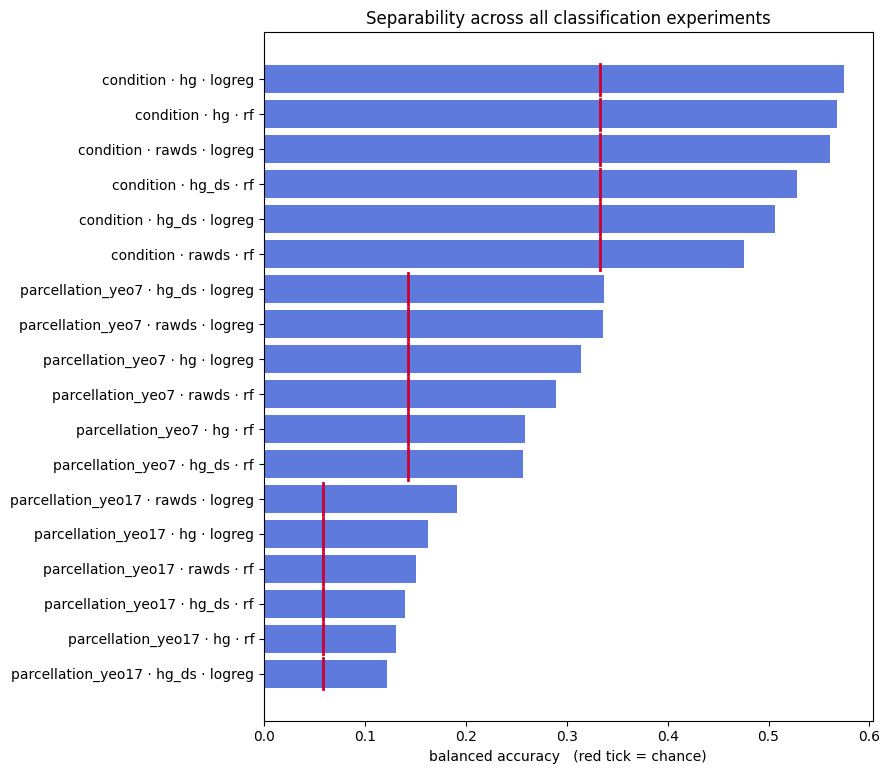

In [7]:
runs = C.list_runs()
if not len(runs):
    show('> _no runs yet — execute 320 and 330 first._')
else:
    display(runs[['task', 'variant', 'classifier', 'balanced_accuracy', 'chance_level',
                  'macro_f1', 'permutation_p']].round(4))
    r2 = runs.copy()
    r2['exp'] = r2.task + ' · ' + r2.variant + ' · ' + r2.classifier
    r2 = r2.sort_values('balanced_accuracy')
    fig, ax = plt.subplots(figsize=(9, 0.38 * len(r2) + 1))
    ax.barh(r2['exp'], r2['balanced_accuracy'], color='#4363d8', alpha=0.85)
    for i, (ba, ch) in enumerate(zip(r2.balanced_accuracy, r2.chance_level)):
        ax.plot([ch, ch], [i - 0.45, i + 0.45], color='#cc0033', lw=2)
    ax.set_xlabel('balanced accuracy   (red tick = chance)')
    ax.set_title('Separability across all classification experiments')
    plt.tight_layout(); plt.show()


# Task A — Condition decoding (audio / picture / reading)

Chance = 0.333. A high diagonal here means the spectro-temporal response itself carries
*which modality* the electrode was engaged by. Watch the confusion matrix for the
audio↔reading vs picture structure, and the feature-importance panel for whether high-gamma
or lower bands carry the signal.


### condition · Downsampled ERSP (15x30) · Logistic Regression (multinomial)
- balanced accuracy **0.561** (chance 0.333; 95% CI 0.501–0.605)
- macro-F1 0.555 · accuracy 0.552 · **permutation p = 0.0050** · n=1944 over 24 patients

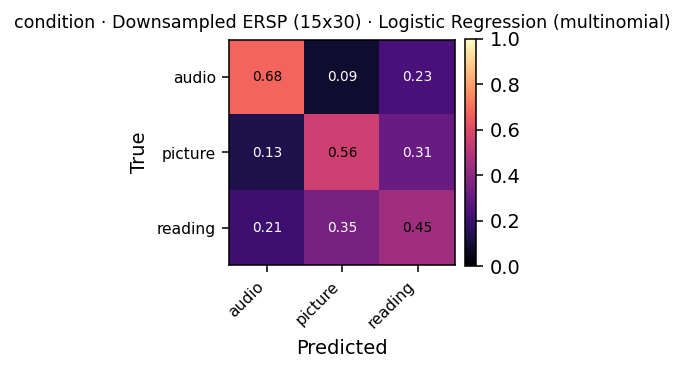

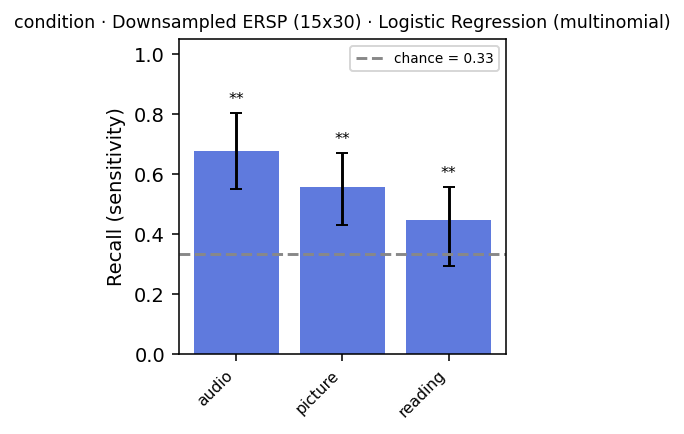

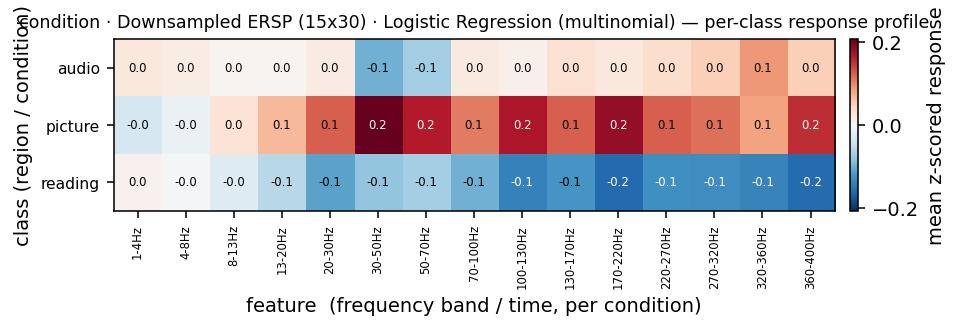

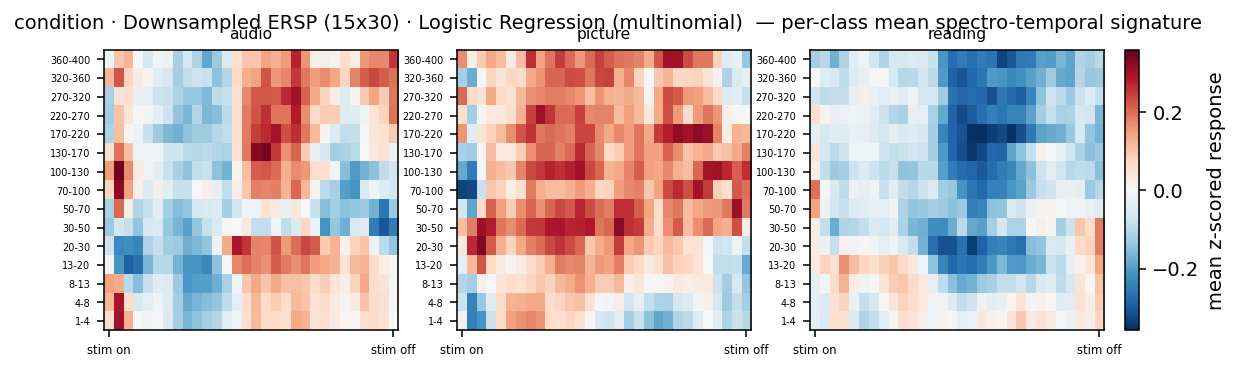

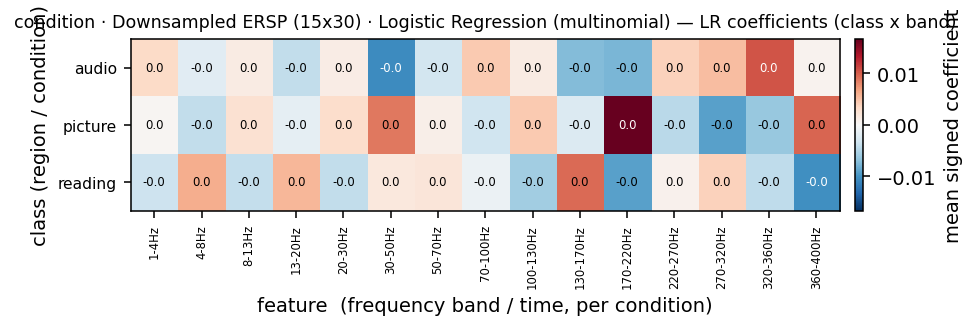

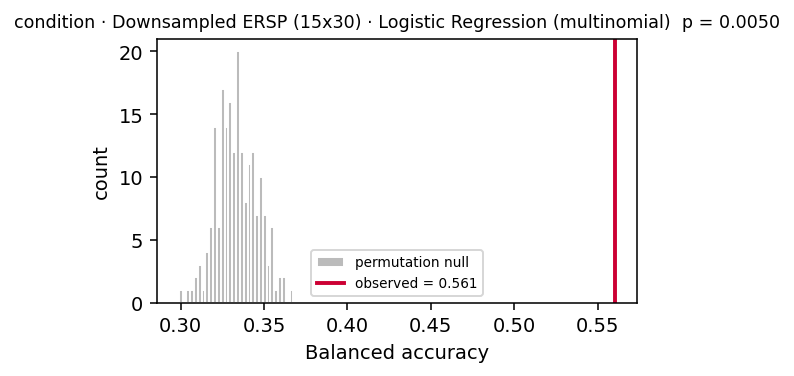

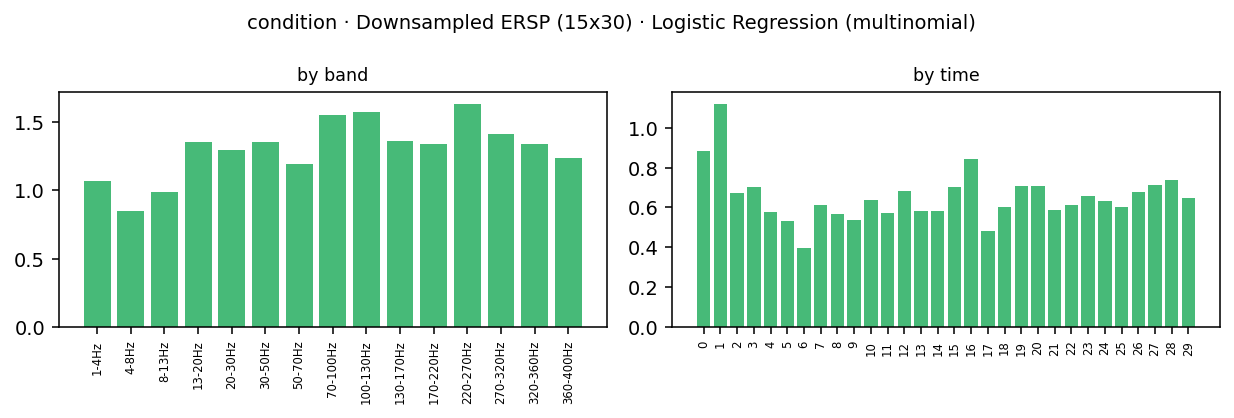

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,audio,607,0.679,0.552,0.804,0.638,0.658,0.855,0.005
1,picture,588,0.556,0.429,0.670,0.512,0.533,0.719,0.005
2,reading,749,0.447,0.293,0.558,0.508,0.476,0.642,0.005


### condition · Downsampled ERSP (15x30) · Random Forest
- balanced accuracy **0.476** (chance 0.333; 95% CI 0.410–0.555)
- macro-F1 0.477 · accuracy 0.481 · **permutation p = 0.0050** · n=1944 over 24 patients

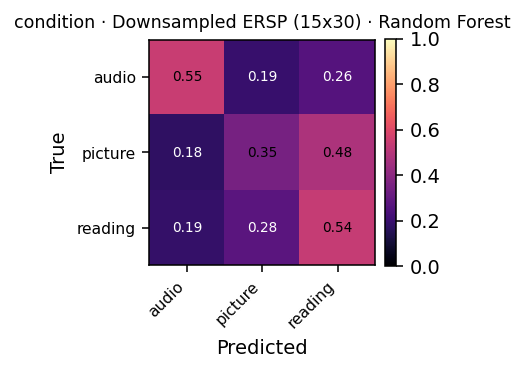

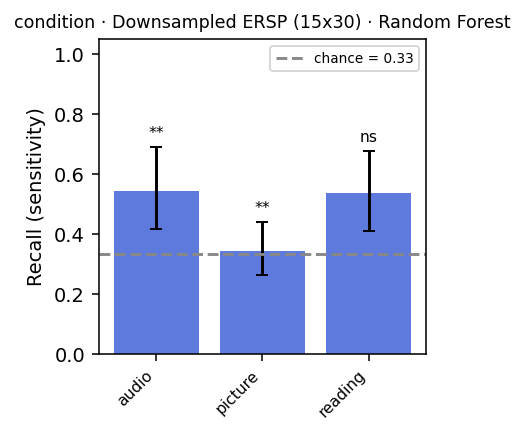

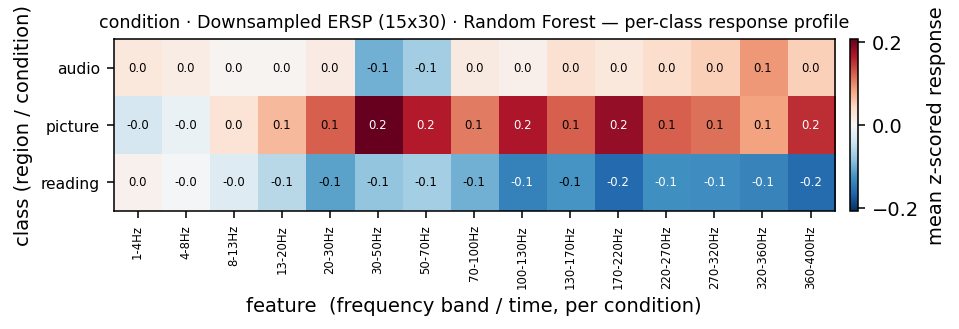

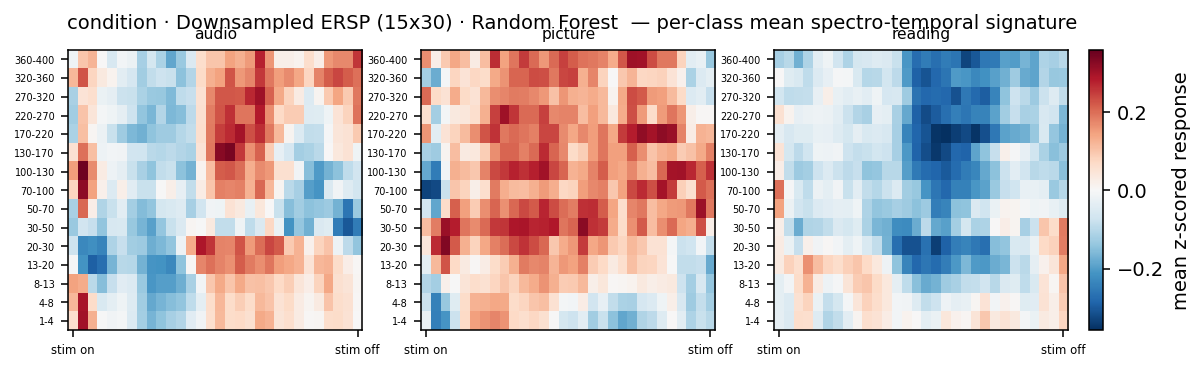

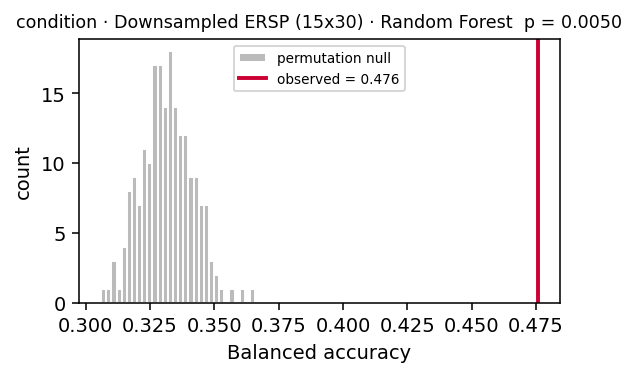

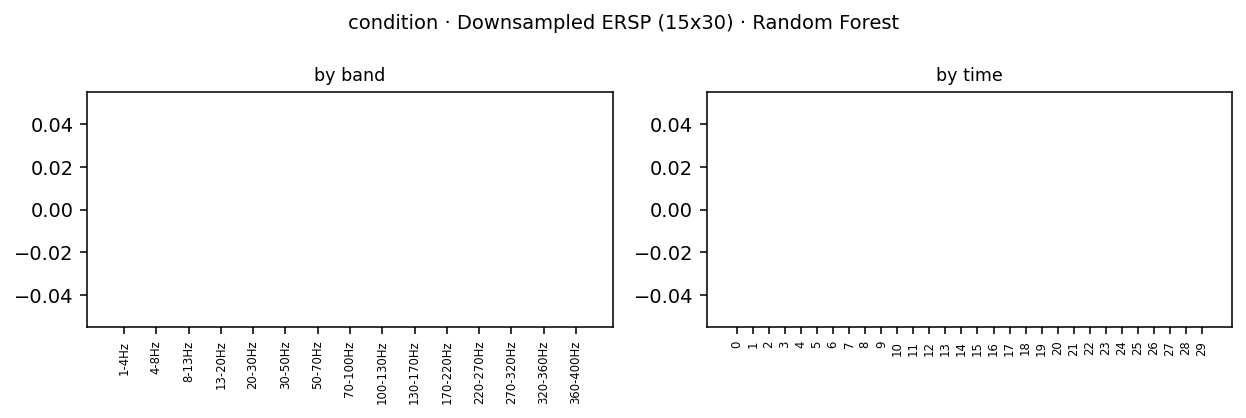

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,audio,607,0.545,0.417,0.690,0.577,0.561,0.767,0.007
1,picture,588,0.345,0.263,0.440,0.385,0.364,0.632,0.007
2,reading,749,0.537,0.411,0.677,0.477,0.505,0.622,1.000


### condition · High-Gamma series (300) · Logistic Regression (multinomial)
- balanced accuracy **0.574** (chance 0.333; 95% CI 0.511–0.616)
- macro-F1 0.574 · accuracy 0.574 · **permutation p = 0.0050** · n=1944 over 24 patients

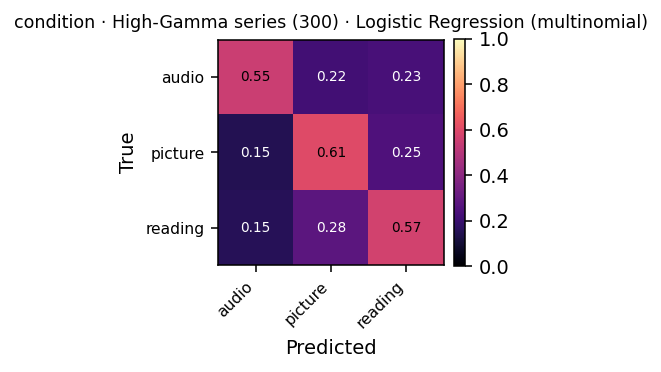

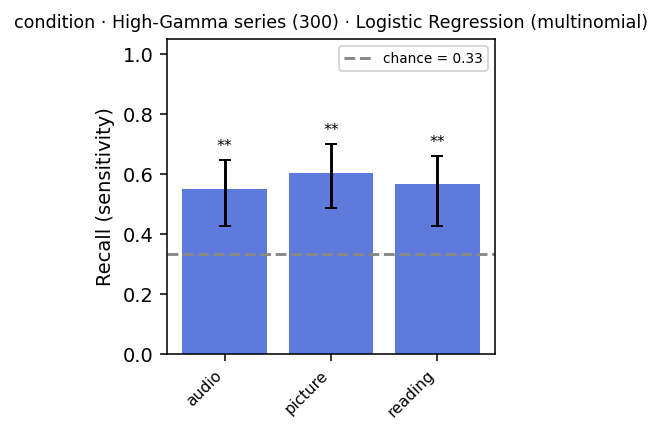

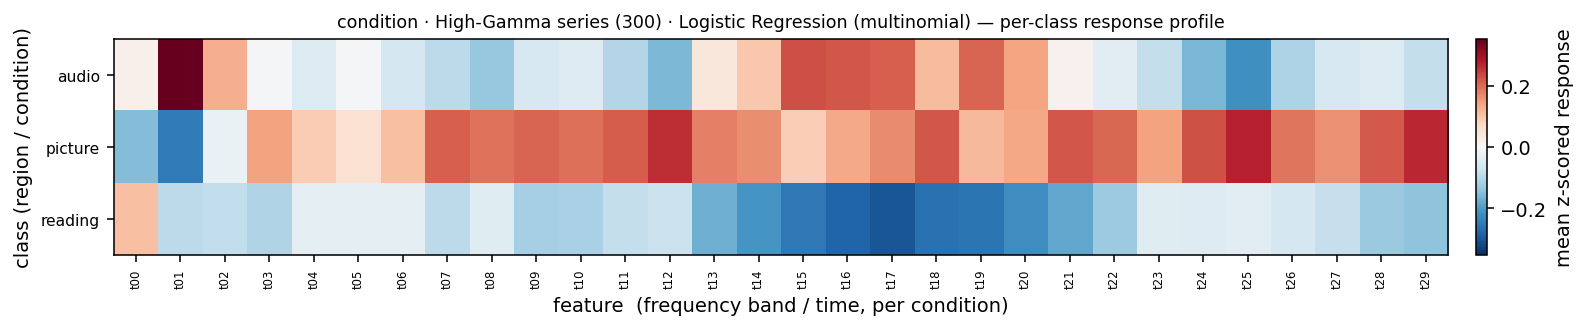

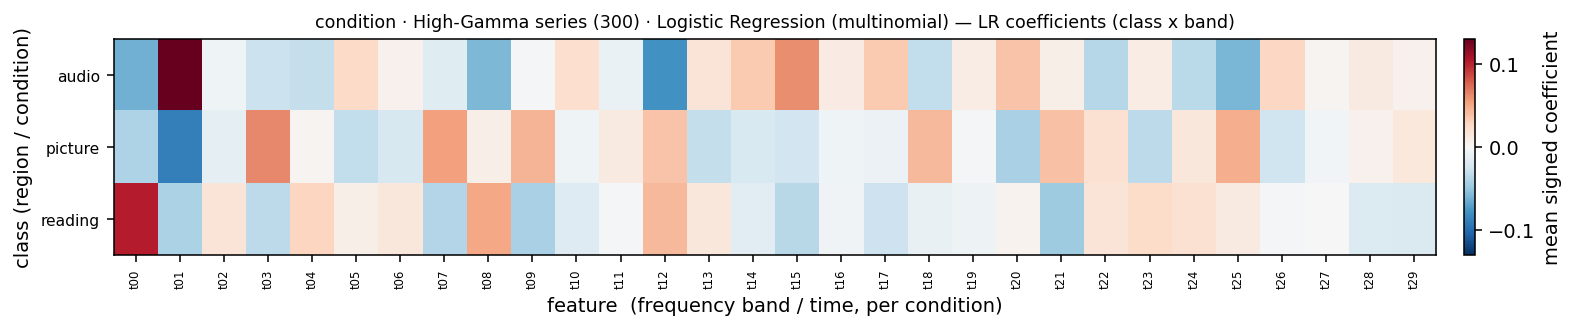

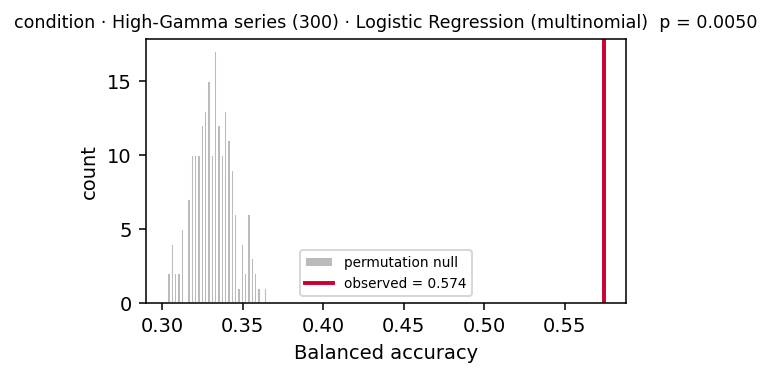

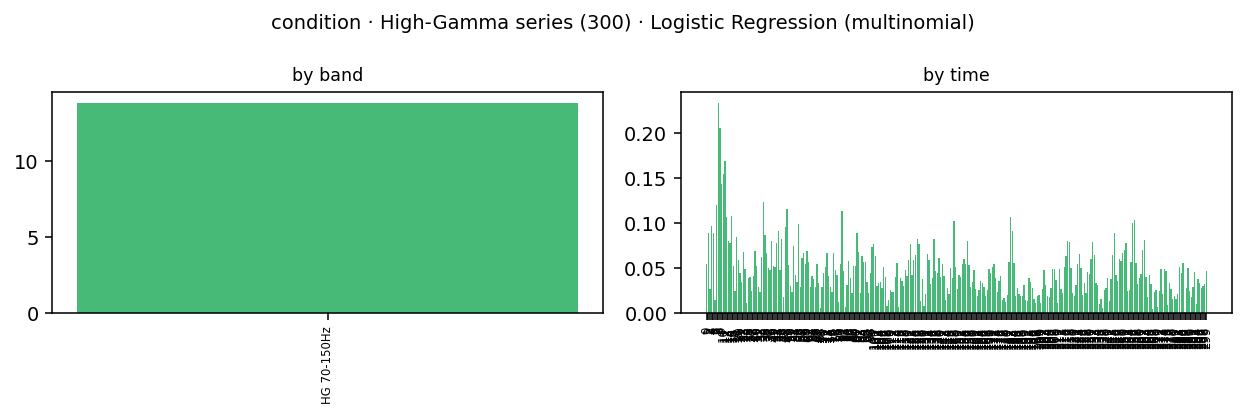

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,audio,607,0.550,0.426,0.648,0.623,0.584,0.754,0.005
1,picture,588,0.605,0.487,0.702,0.511,0.555,0.730,0.005
2,reading,749,0.567,0.427,0.661,0.597,0.582,0.712,0.005


### condition · High-Gamma series (300) · Random Forest
- balanced accuracy **0.568** (chance 0.333; 95% CI 0.497–0.639)
- macro-F1 0.571 · accuracy 0.578 · **permutation p = 0.0050** · n=1944 over 24 patients

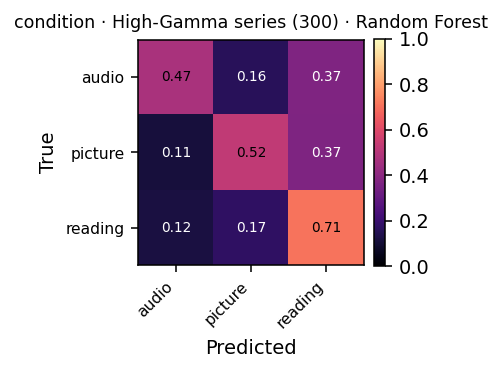

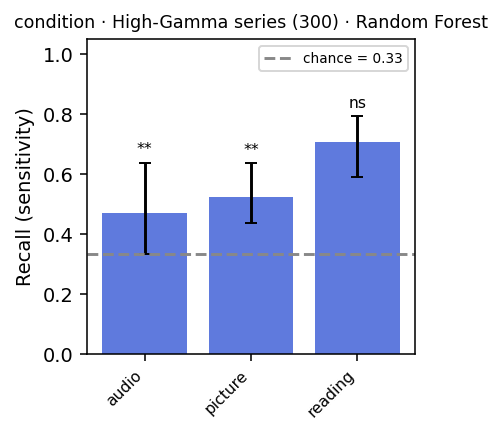

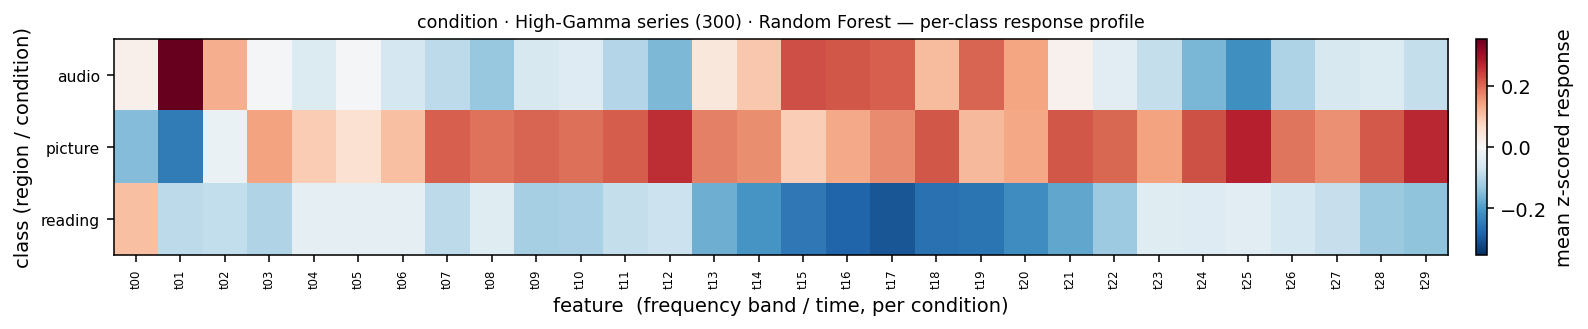

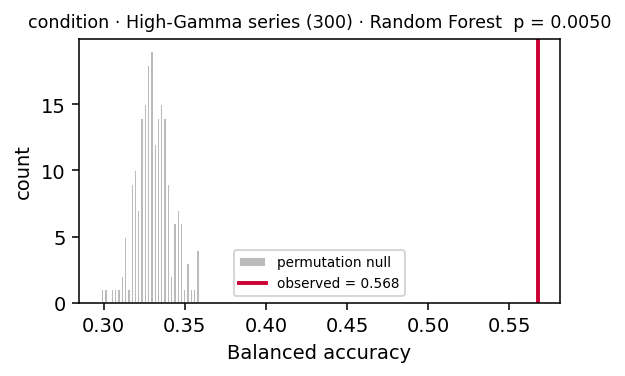

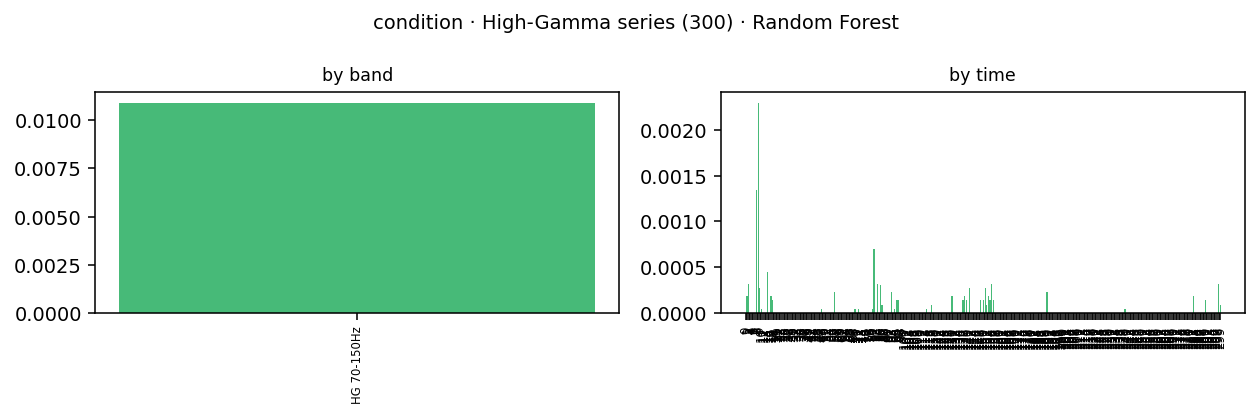

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,audio,607,0.471,0.335,0.638,0.649,0.546,0.792,0.007
1,picture,588,0.524,0.436,0.636,0.577,0.549,0.784,0.007
2,reading,749,0.708,0.591,0.793,0.547,0.617,0.753,0.269


### condition · High-Gamma downsampled (30) · Logistic Regression (multinomial)
- balanced accuracy **0.506** (chance 0.333; 95% CI 0.460–0.555)
- macro-F1 0.505 · accuracy 0.505 · **permutation p = 0.0050** · n=1944 over 24 patients

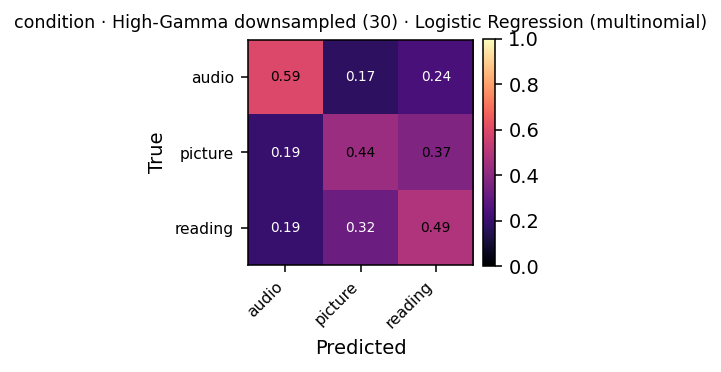

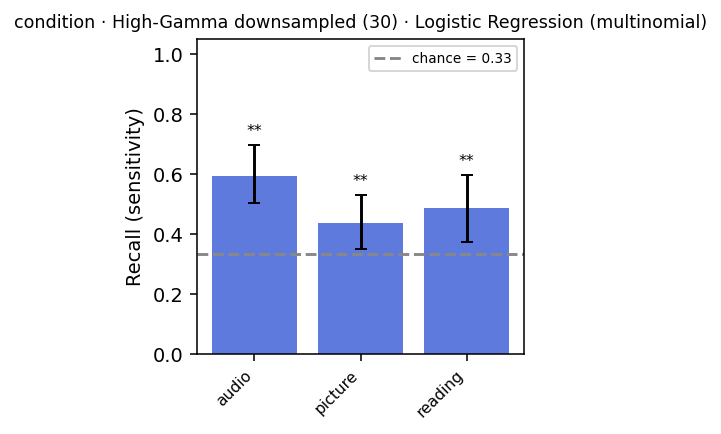

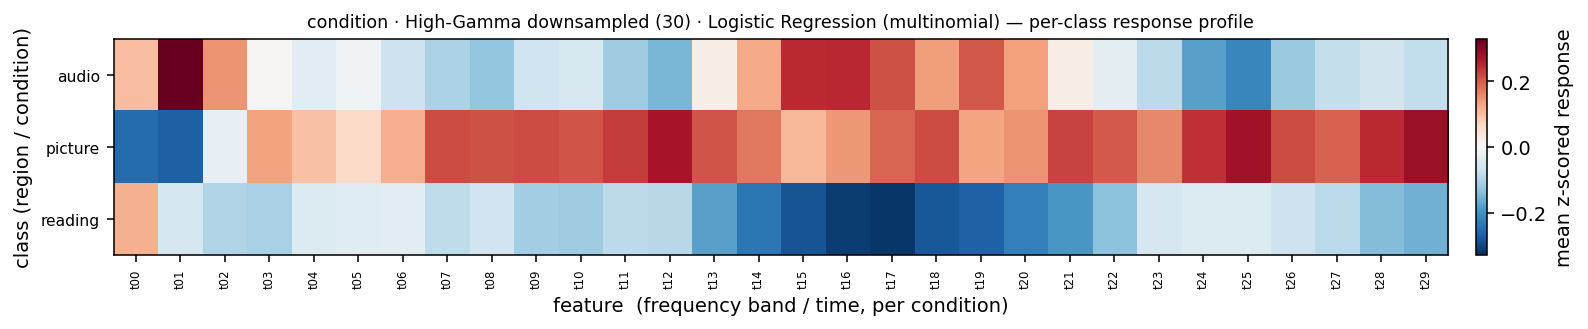

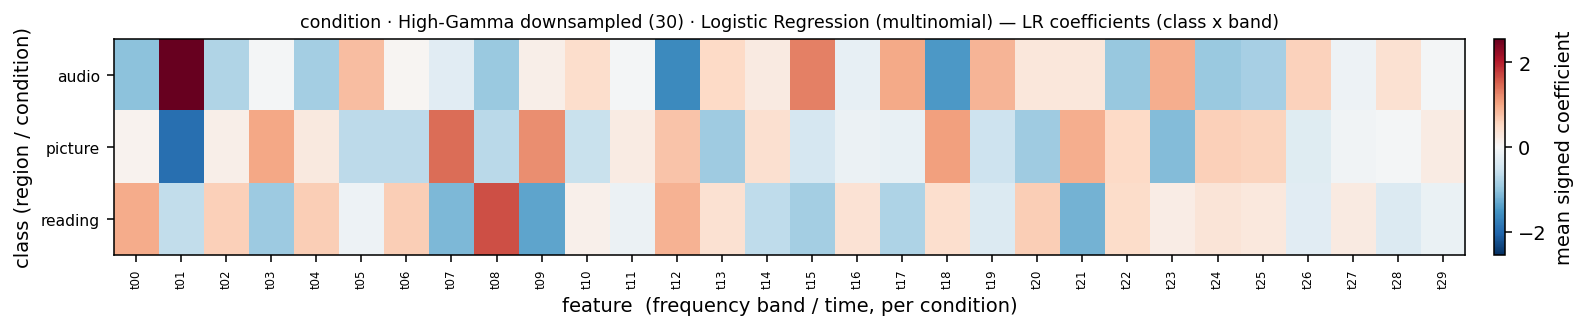

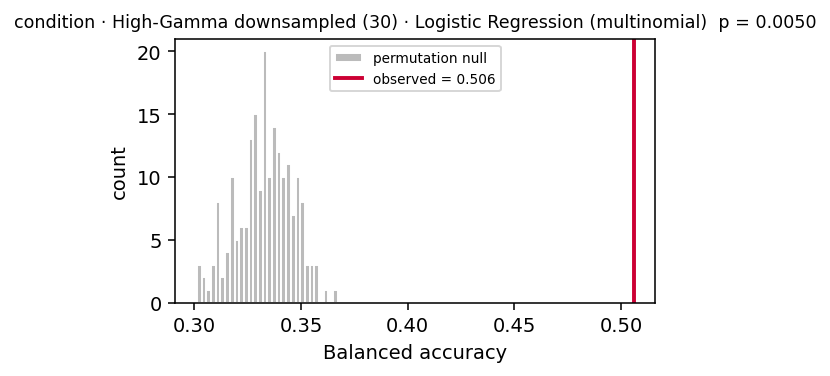

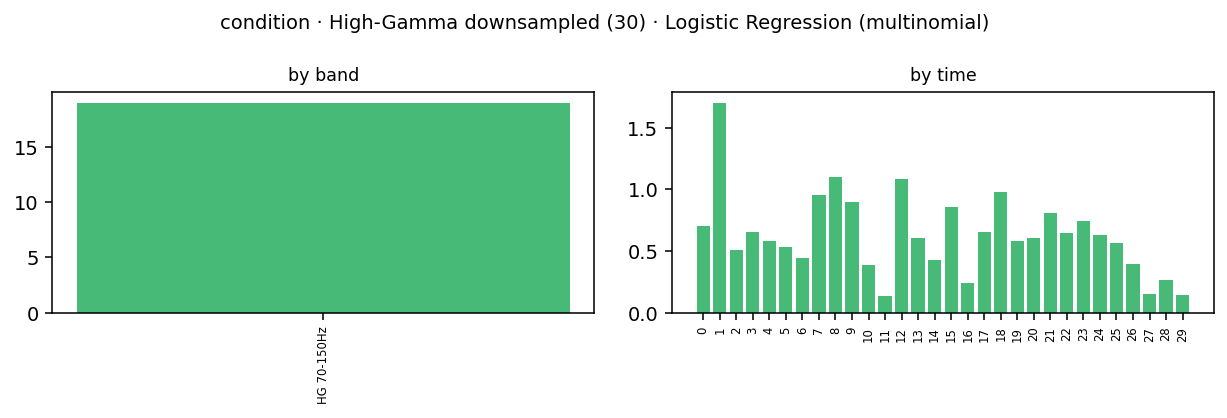

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,audio,607,0.595,0.503,0.698,0.583,0.589,0.802,0.005
1,picture,588,0.437,0.352,0.530,0.428,0.433,0.691,0.005
2,reading,749,0.486,0.372,0.597,0.502,0.494,0.631,0.005


### condition · High-Gamma downsampled (30) · Random Forest
- balanced accuracy **0.529** (chance 0.333; 95% CI 0.482–0.581)
- macro-F1 0.532 · accuracy 0.535 · **permutation p = 0.0050** · n=1944 over 24 patients

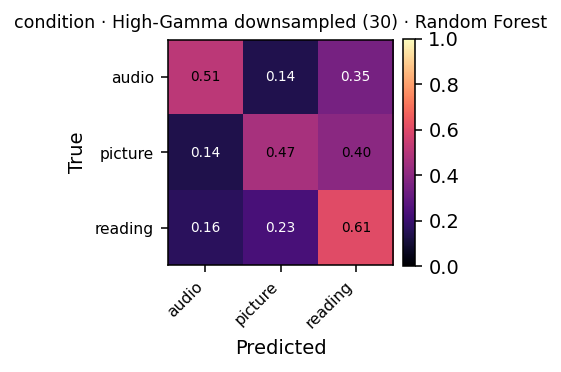

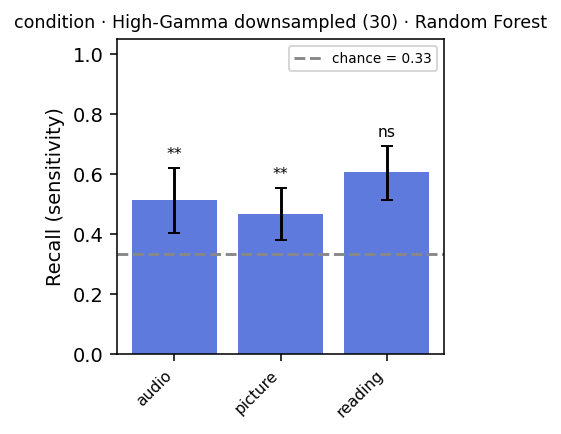

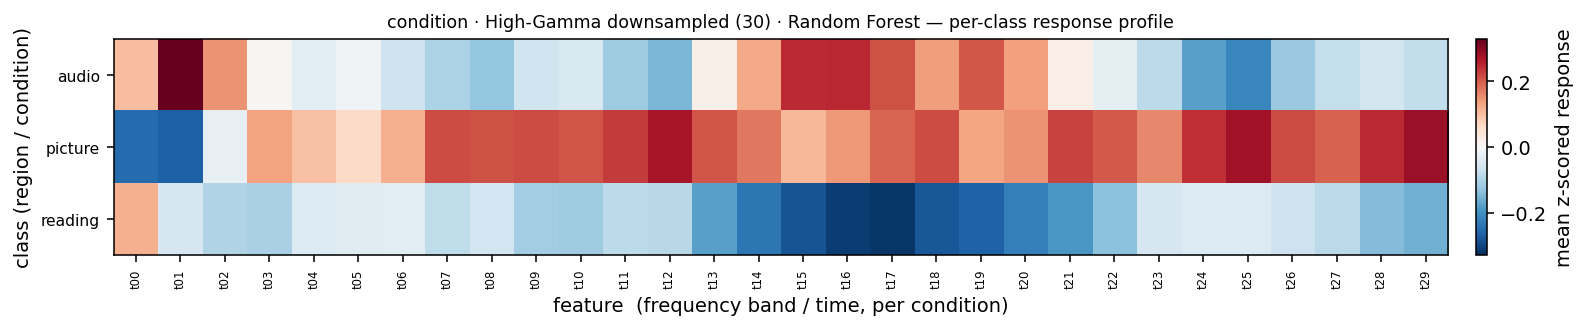

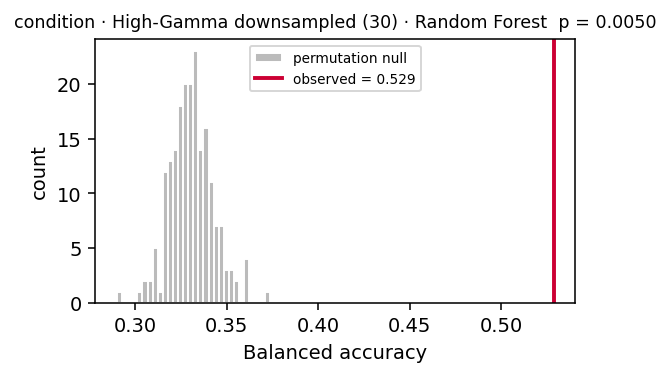

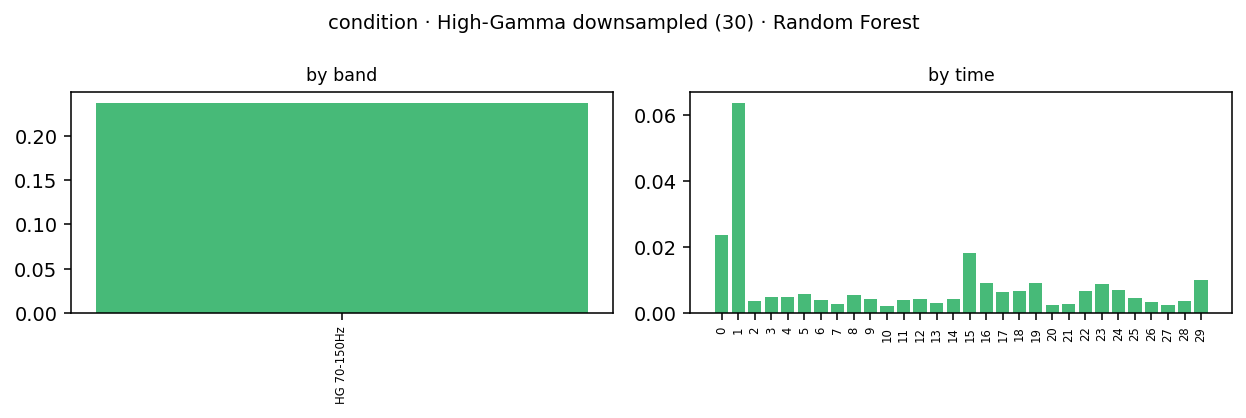

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,audio,607,0.512,0.403,0.621,0.609,0.556,0.772,0.007
1,picture,588,0.466,0.379,0.555,0.514,0.489,0.731,0.007
2,reading,749,0.607,0.516,0.694,0.506,0.552,0.671,0.388


In [8]:
for v in C.VARIANTS:
    for clf in ('logreg', 'rf'):
        show_run('condition', v, clf)


# Task B — Parcellation decoding (Yeo networks)

Chance = 1/7 ≈ 0.143 (Yeo-7) and 1/17 ≈ 0.059 (Yeo-17). Because classes are imbalanced, read
**per-class strength** carefully: some networks (with many electrodes, broad coverage) will
separate strongly while sparse networks stay at chance. The feature-importance **by-condition**
panel answers "does one condition carry most of the anatomical signal, or all three jointly?".


## Yeo-7

### parcellation_yeo7 · Downsampled ERSP (15x30) · Logistic Regression (multinomial)
- balanced accuracy **0.336** (chance 0.143; 95% CI 0.255–0.385)
- macro-F1 0.326 · accuracy 0.371 · **permutation p = 0.0050** · n=958 over 24 patients

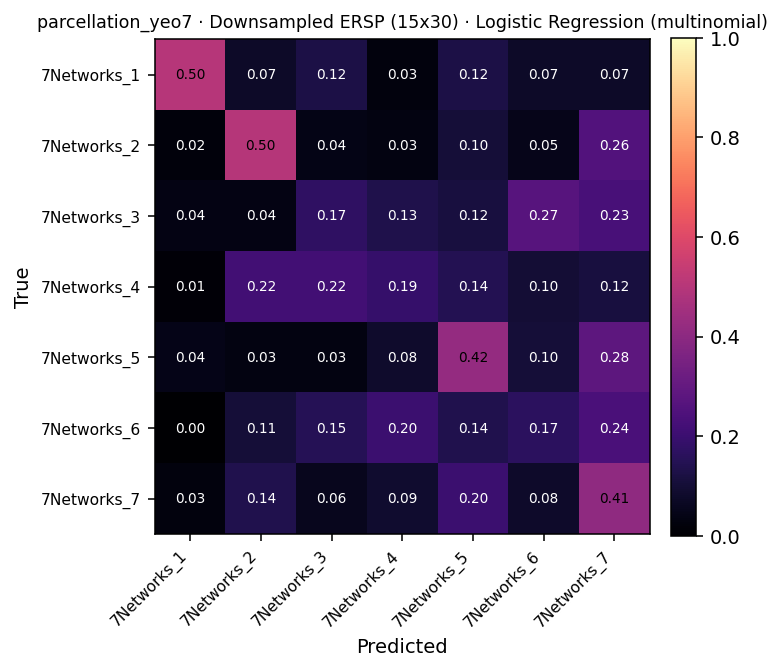

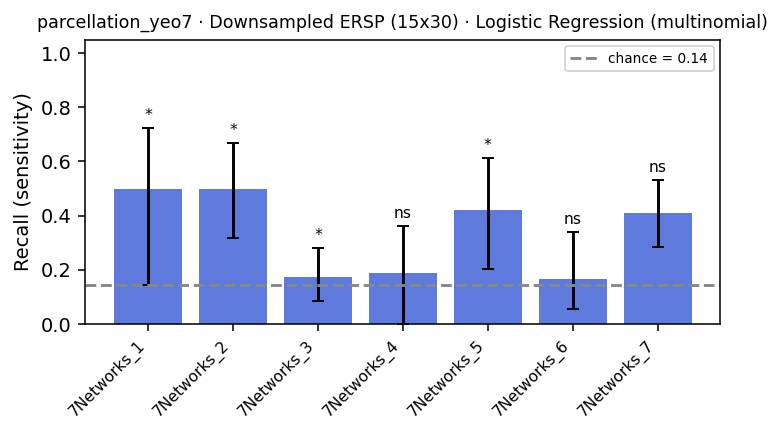

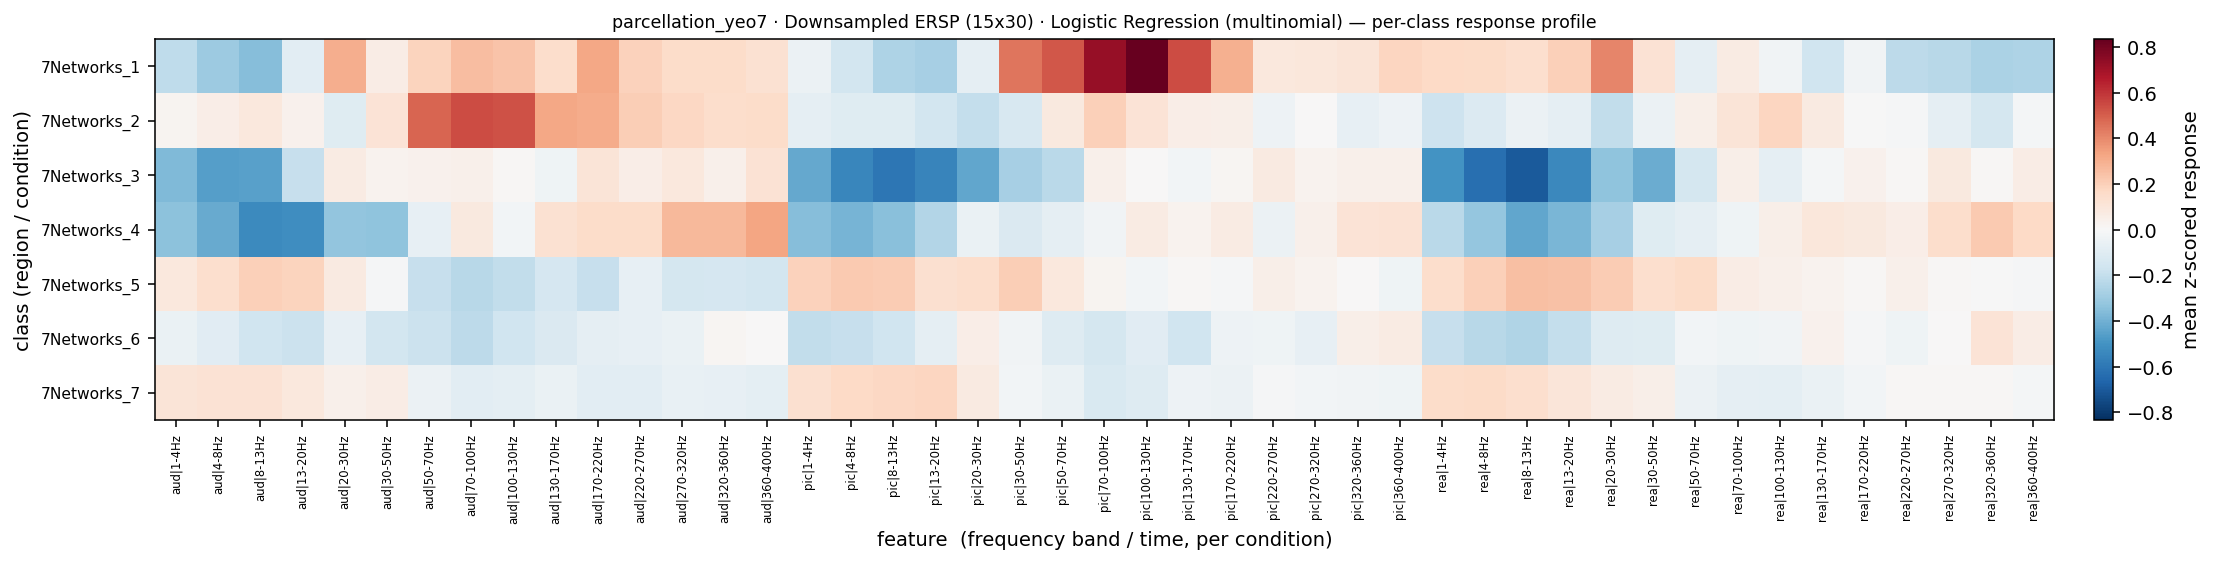

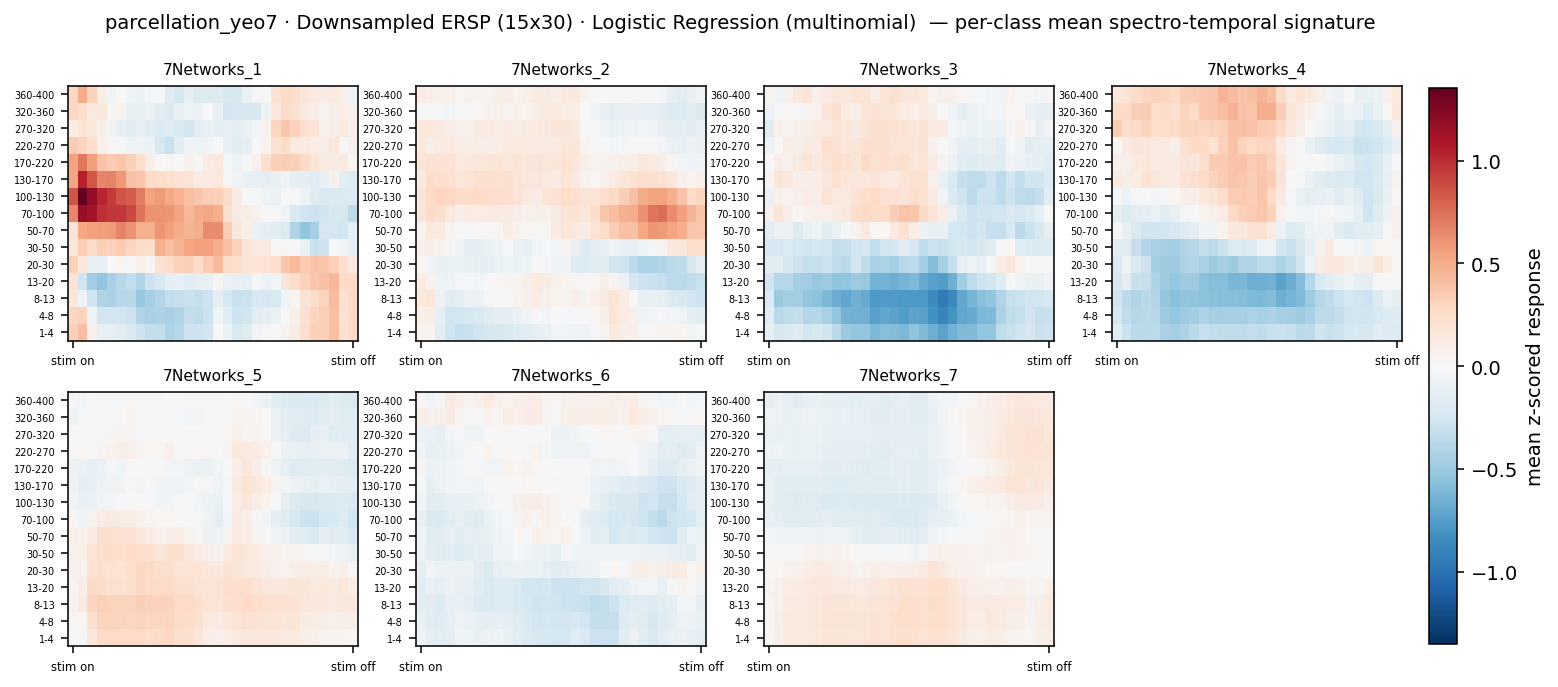

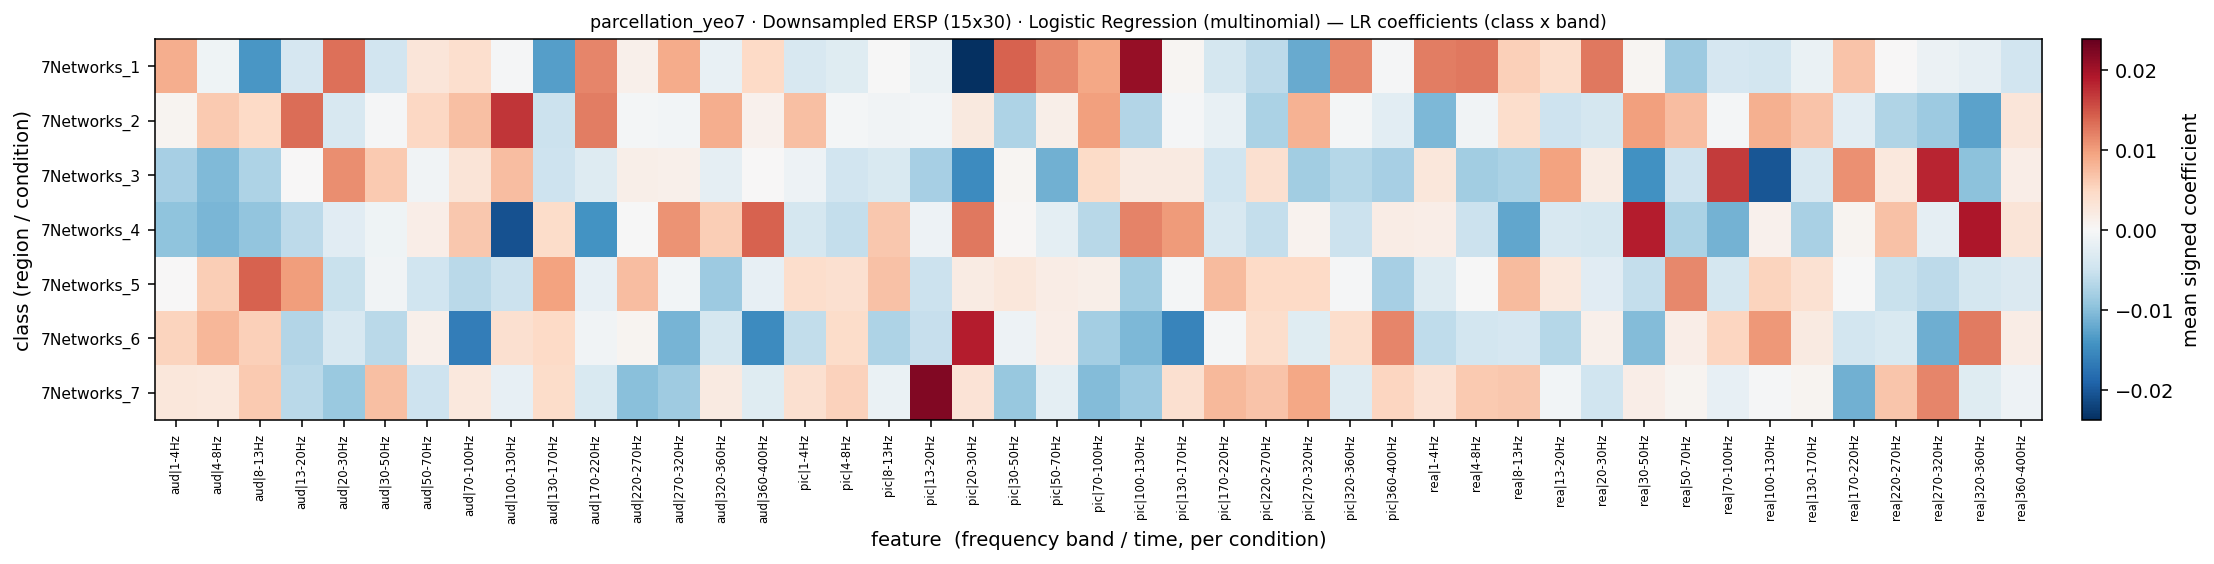

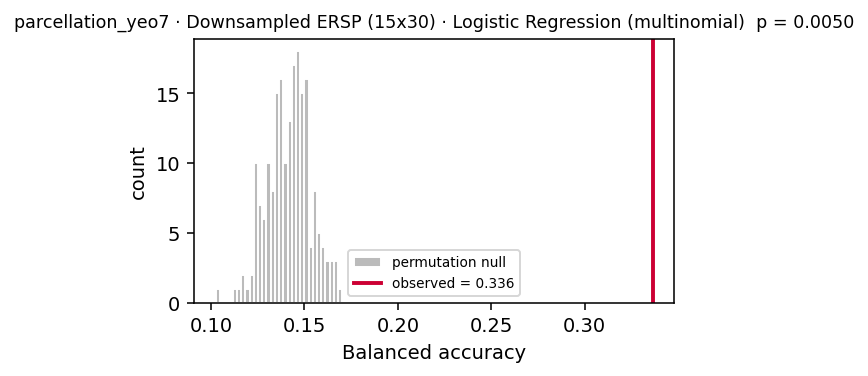

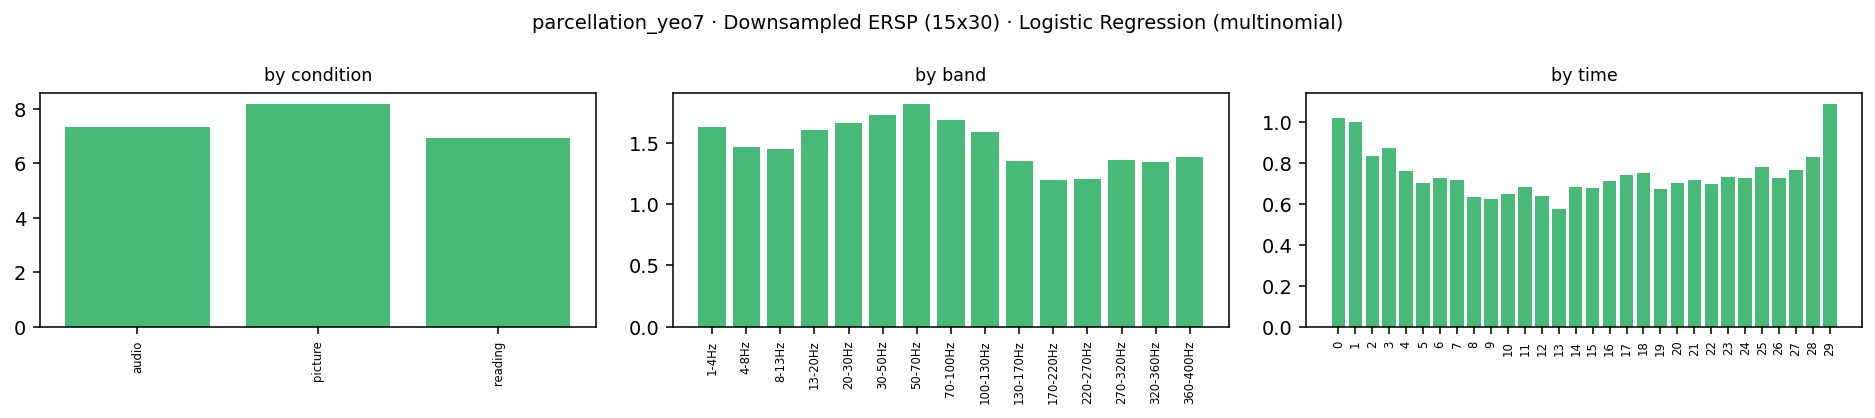

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,7Networks_1,40,0.500,0.143,0.725,0.465,0.482,0.875,0.012
1,7Networks_2,145,0.497,0.318,0.669,0.453,0.474,0.784,0.012
2,7Networks_3,52,0.173,0.083,0.281,0.115,0.138,0.684,0.044
3,7Networks_4,69,0.188,0.000,0.360,0.135,0.158,0.706,0.056
4,7Networks_5,181,0.420,0.201,0.613,0.380,0.399,0.645,0.012
5,7Networks_6,114,0.167,0.056,0.341,0.194,0.179,0.587,0.214
6,7Networks_7,357,0.409,0.284,0.532,0.514,0.456,0.670,0.122


### parcellation_yeo7 · Downsampled ERSP (15x30) · Random Forest
- balanced accuracy **0.289** (chance 0.143; 95% CI 0.243–0.341)
- macro-F1 0.293 · accuracy 0.401 · **permutation p = 0.0050** · n=958 over 24 patients

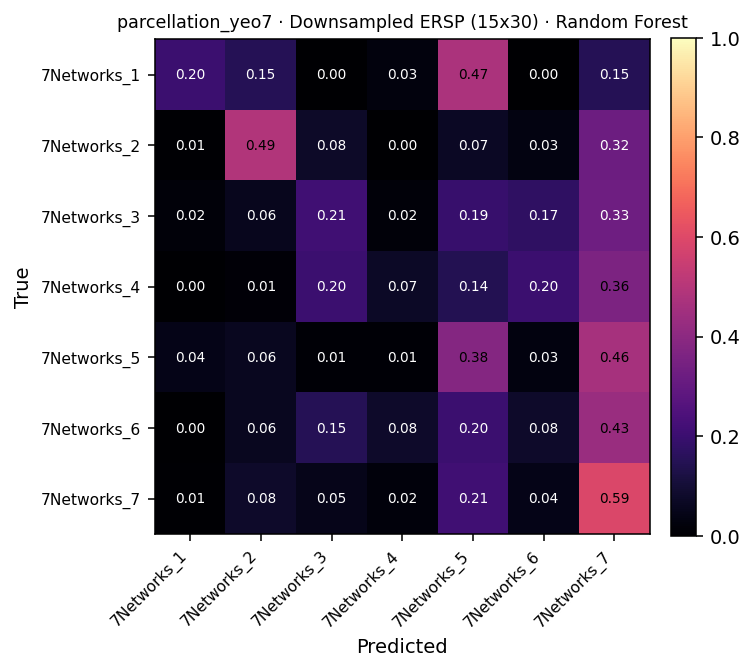

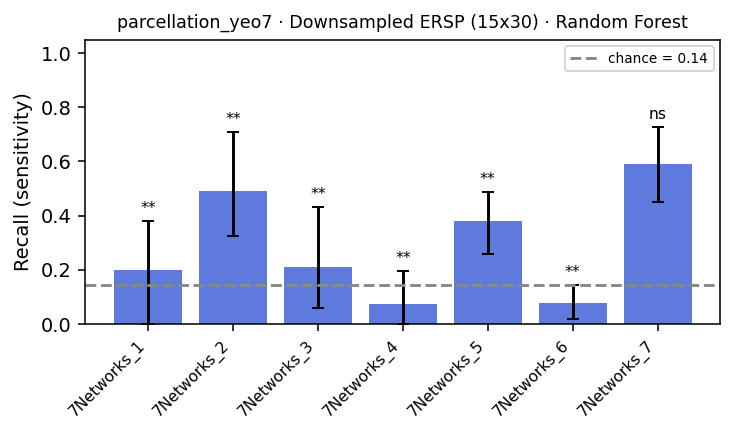

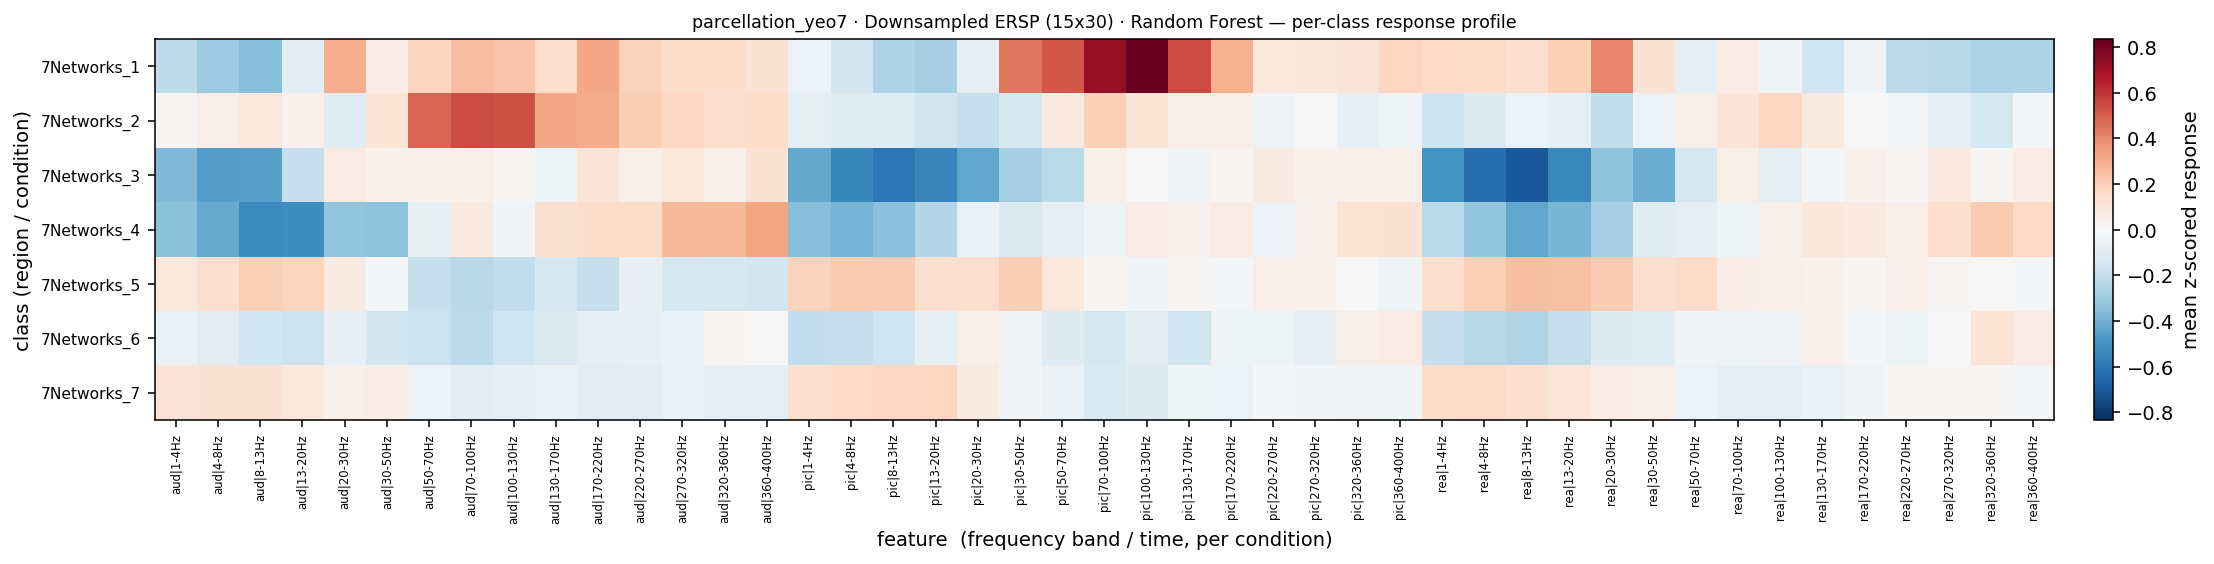

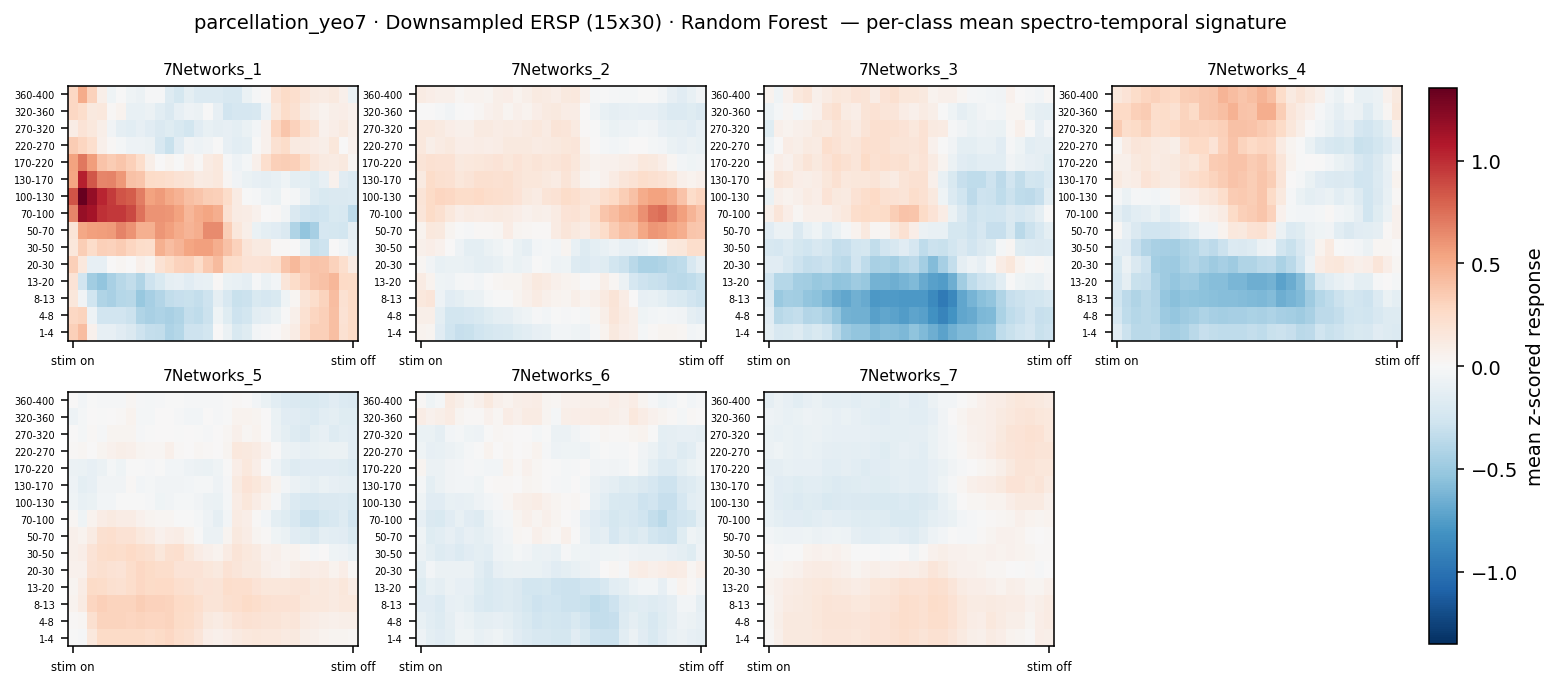

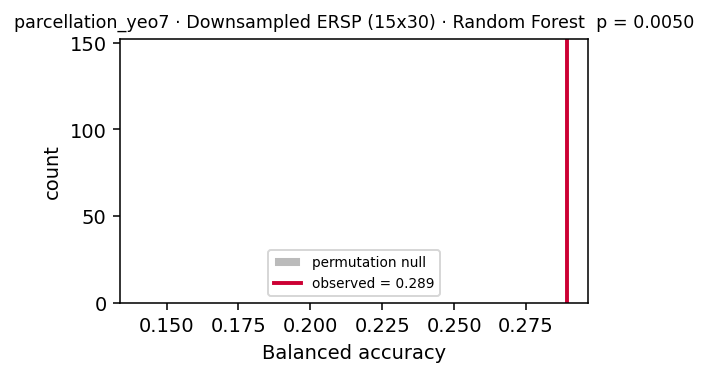

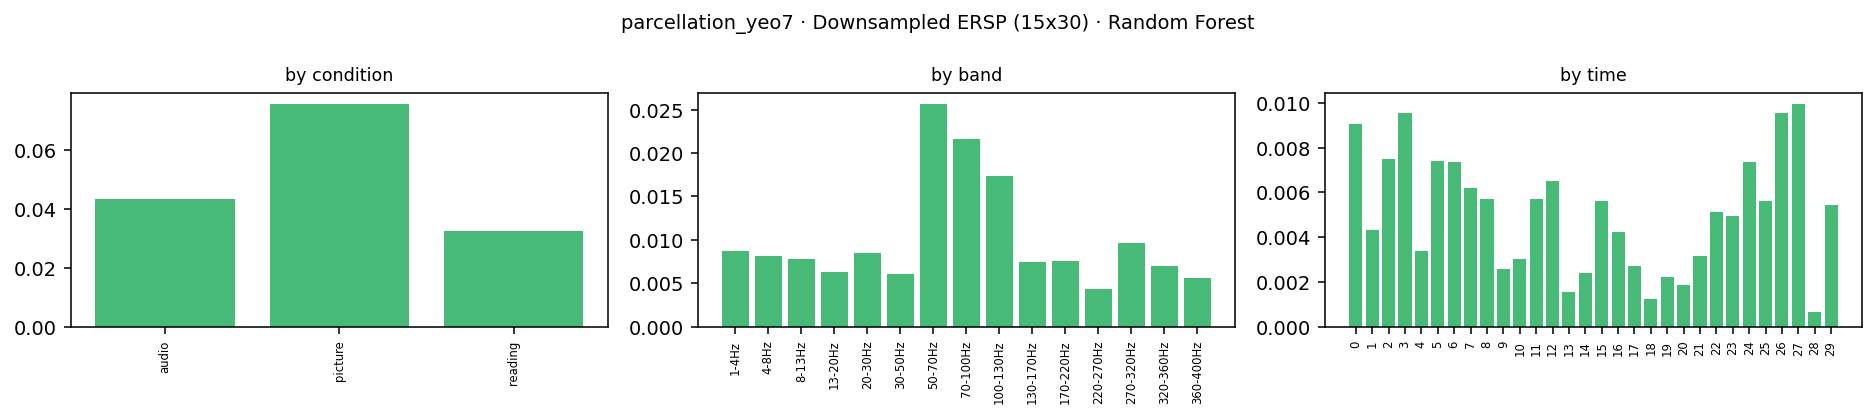

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,7Networks_1,40,0.200,0.000,0.378,0.400,0.267,0.820,0.006
1,7Networks_2,145,0.490,0.324,0.708,0.559,0.522,0.781,0.006
2,7Networks_3,52,0.212,0.058,0.431,0.153,0.177,0.704,0.006
3,7Networks_4,69,0.072,0.000,0.196,0.200,0.106,0.649,0.006
4,7Networks_5,181,0.381,0.260,0.487,0.318,0.347,0.642,0.006
5,7Networks_6,114,0.079,0.020,0.145,0.155,0.105,0.622,0.006
6,7Networks_7,357,0.591,0.451,0.726,0.481,0.530,0.646,1.000


### parcellation_yeo7 · High-Gamma series (300) · Logistic Regression (multinomial)
- balanced accuracy **0.314** (chance 0.143; 95% CI 0.237–0.378)
- macro-F1 0.289 · accuracy 0.311 · **permutation p = 0.0050** · n=958 over 24 patients

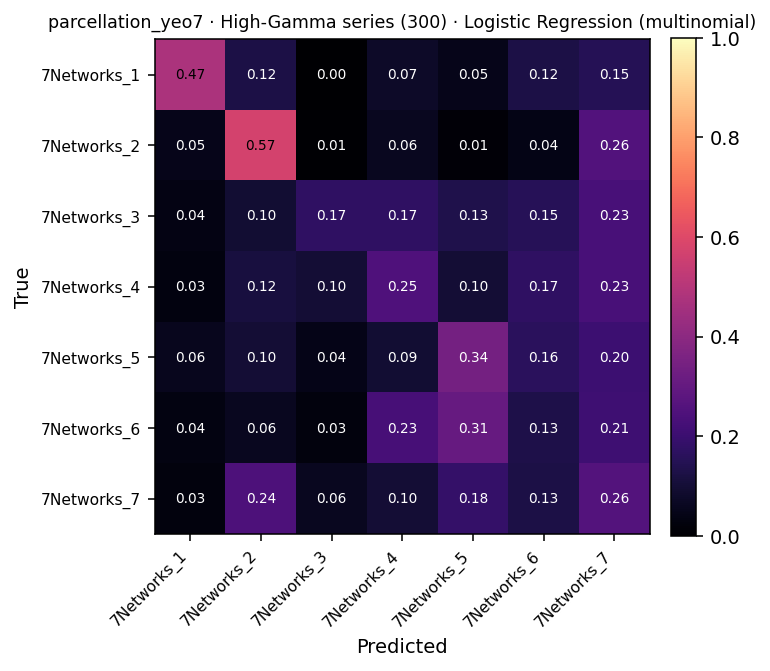

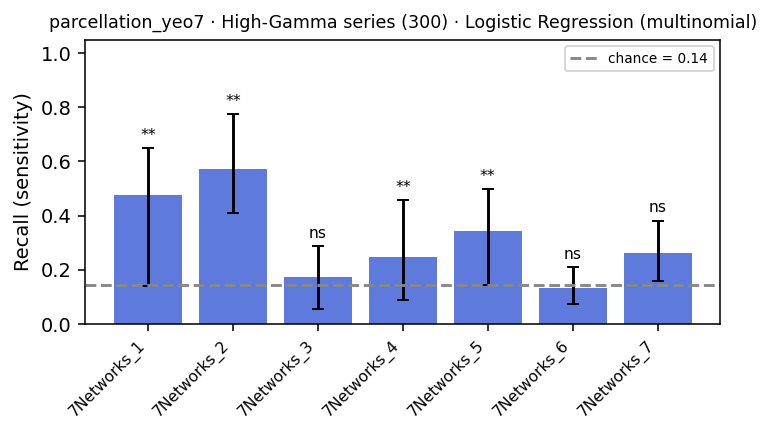

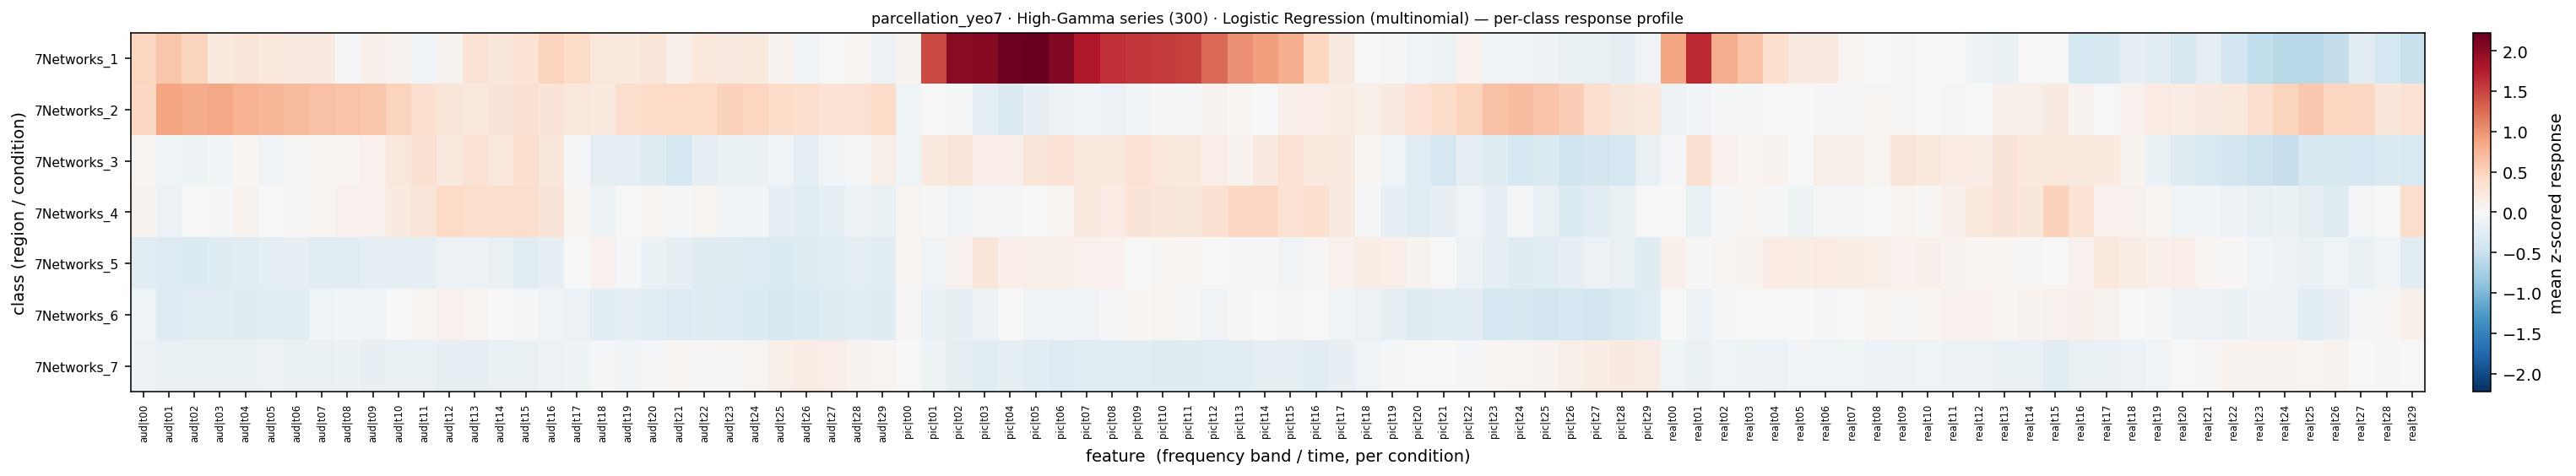

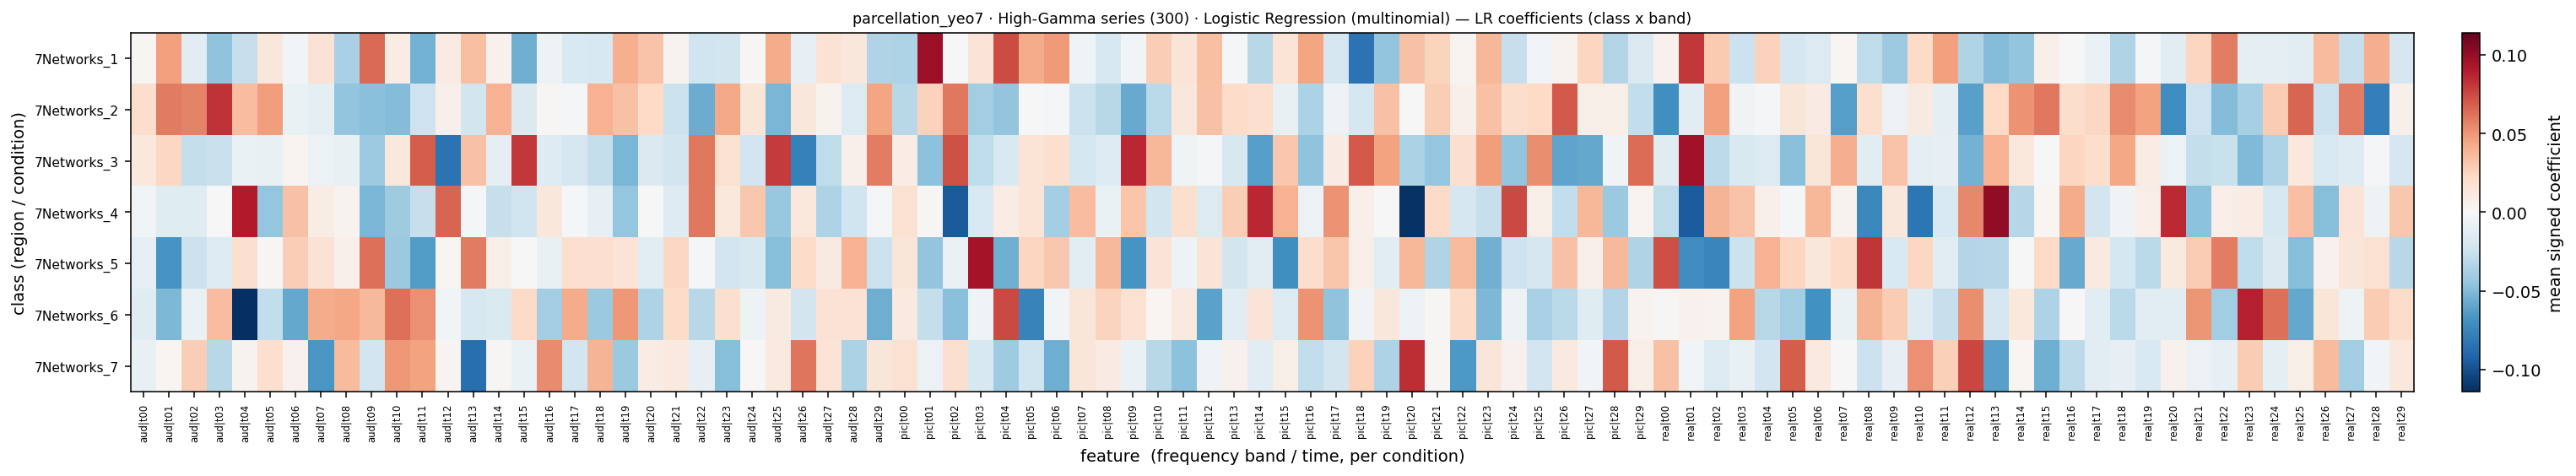

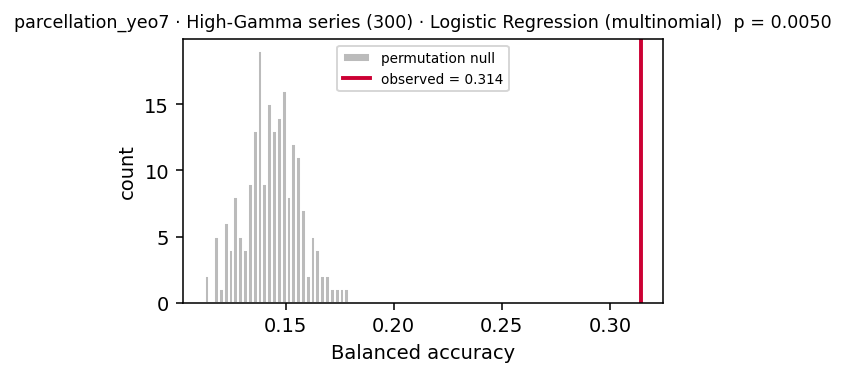

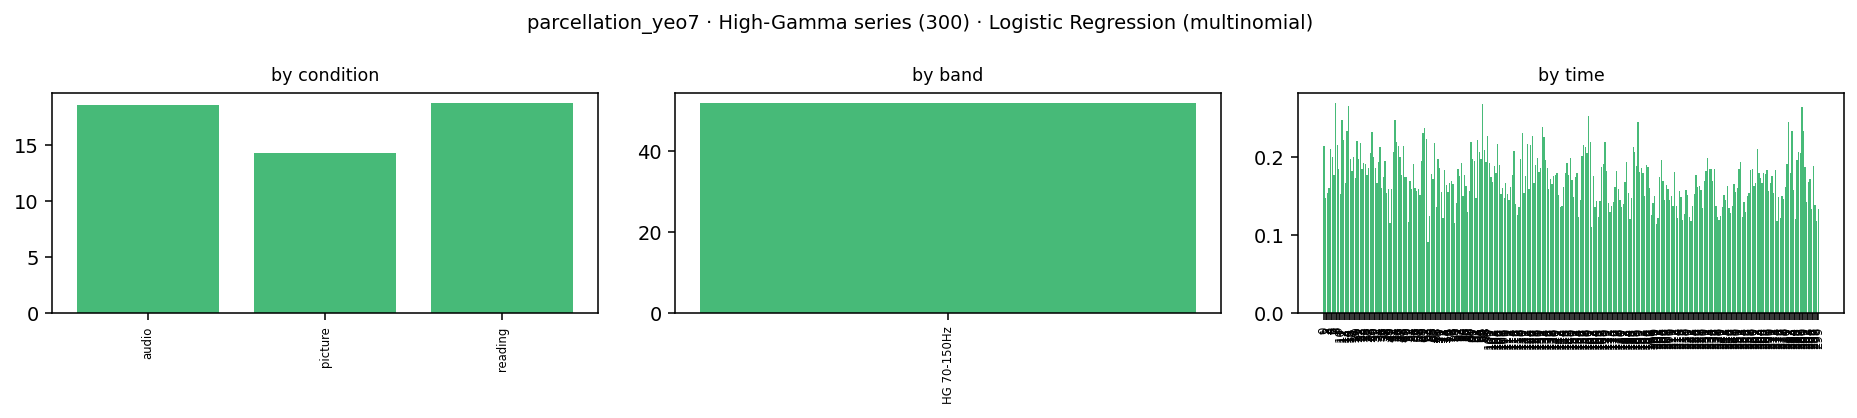

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,7Networks_1,40,0.475,0.139,0.649,0.358,0.409,0.766,0.009
1,7Networks_2,145,0.572,0.411,0.777,0.390,0.464,0.773,0.009
2,7Networks_3,52,0.173,0.056,0.288,0.184,0.178,0.678,0.056
3,7Networks_4,69,0.246,0.089,0.458,0.145,0.183,0.662,0.009
4,7Networks_5,181,0.343,0.146,0.498,0.343,0.343,0.658,0.009
5,7Networks_6,114,0.132,0.075,0.211,0.125,0.128,0.607,0.679
6,7Networks_7,357,0.261,0.160,0.382,0.413,0.320,0.592,0.786


### parcellation_yeo7 · High-Gamma series (300) · Random Forest
- balanced accuracy **0.258** (chance 0.143; 95% CI 0.216–0.309)
- macro-F1 0.261 · accuracy 0.354 · **permutation p = 0.0050** · n=958 over 24 patients

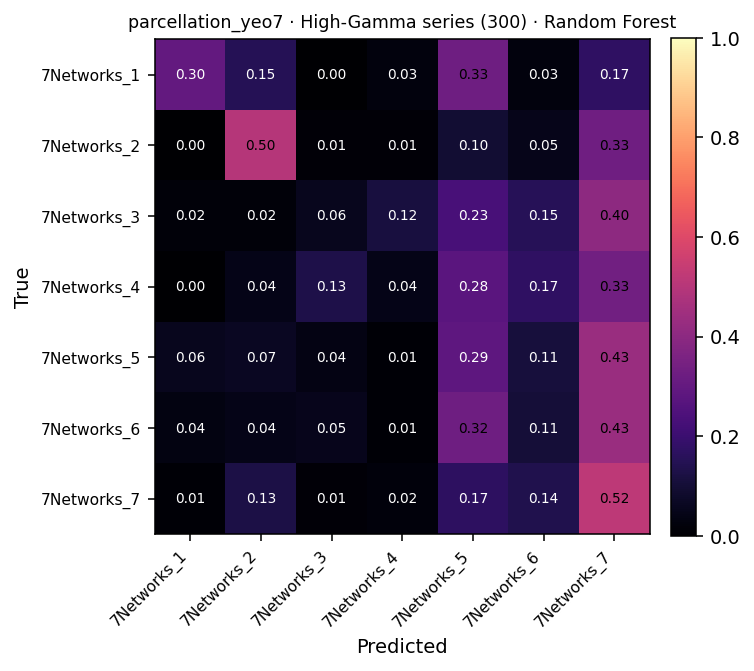

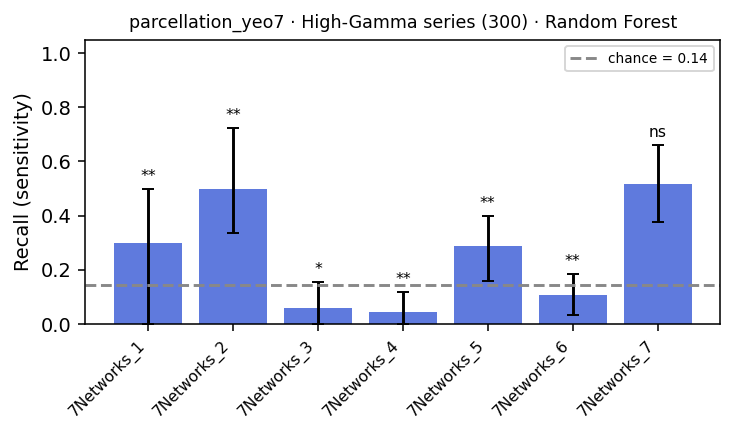

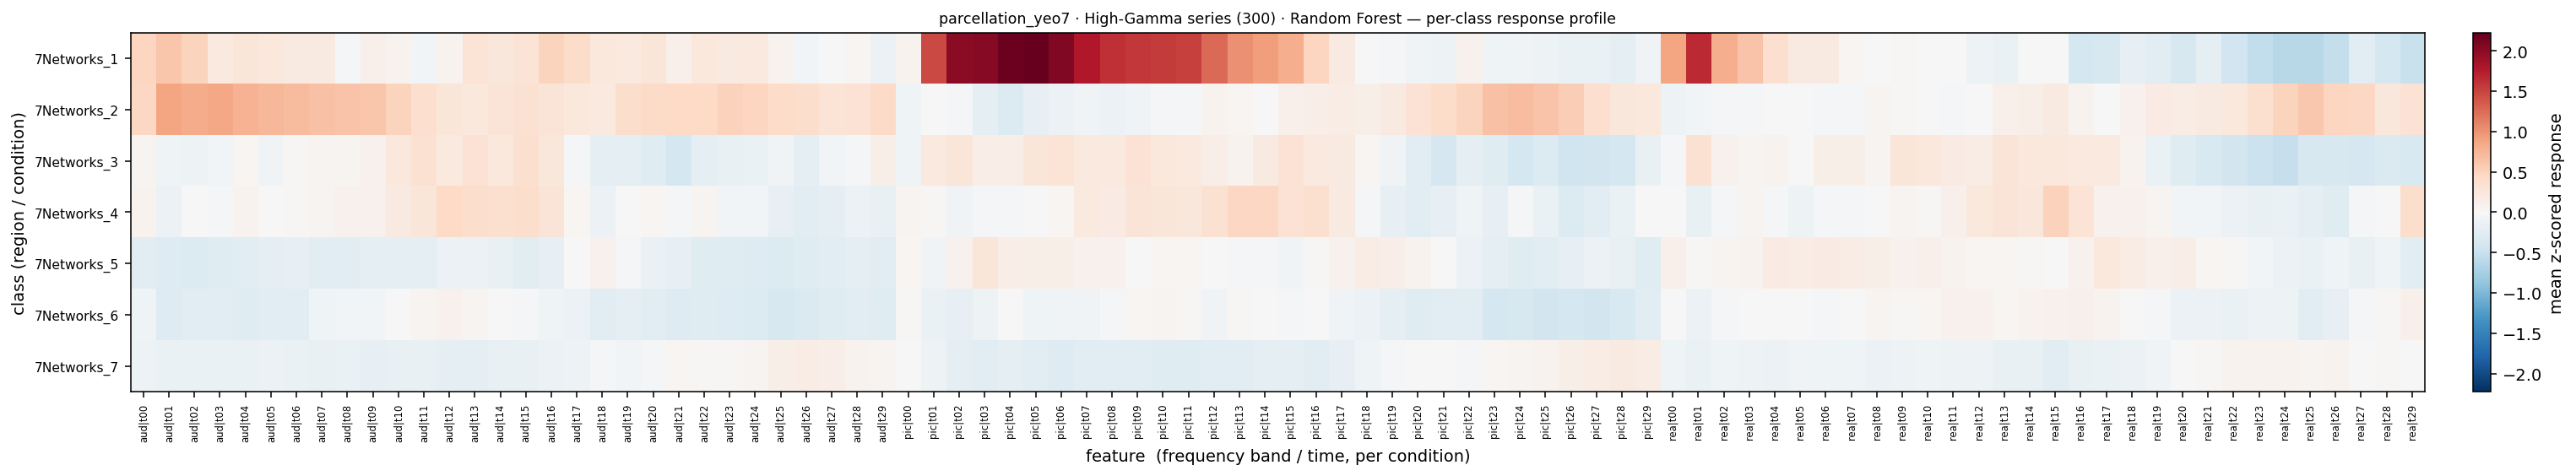

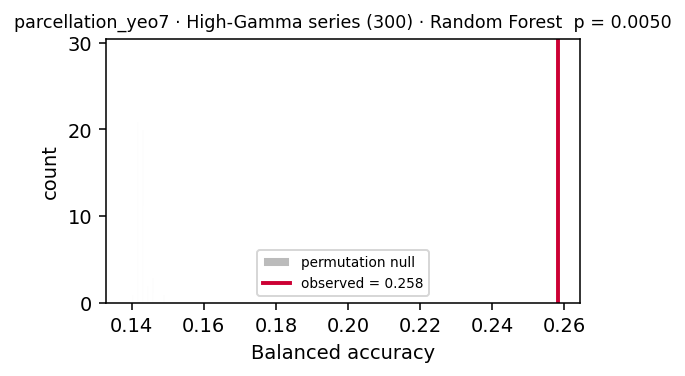

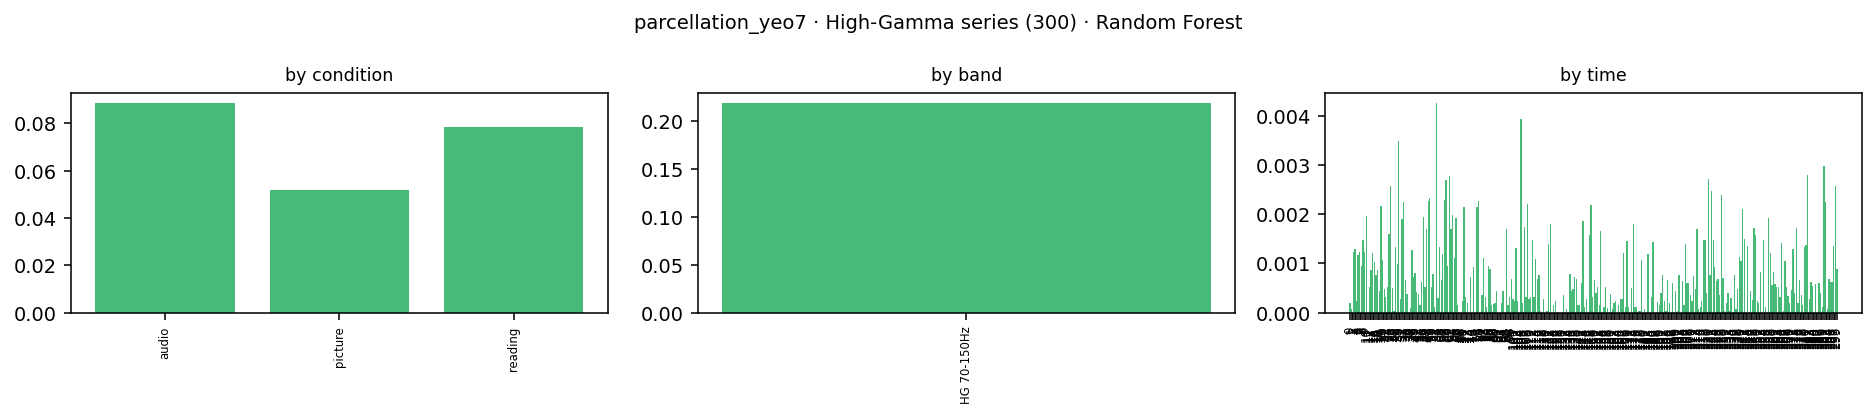

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,7Networks_1,40,0.300,0.000,0.500,0.387,0.338,0.727,0.007
1,7Networks_2,145,0.497,0.337,0.722,0.500,0.498,0.800,0.007
2,7Networks_3,52,0.058,0.000,0.154,0.094,0.071,0.657,0.012
3,7Networks_4,69,0.043,0.000,0.116,0.136,0.066,0.509,0.007
4,7Networks_5,181,0.287,0.158,0.397,0.250,0.267,0.560,0.007
5,7Networks_6,114,0.105,0.033,0.185,0.109,0.107,0.637,0.007
6,7Networks_7,357,0.518,0.378,0.661,0.450,0.482,0.602,1.000


### parcellation_yeo7 · High-Gamma downsampled (30) · Logistic Regression (multinomial)
- balanced accuracy **0.337** (chance 0.143; 95% CI 0.255–0.396)
- macro-F1 0.298 · accuracy 0.320 · **permutation p = 0.0050** · n=958 over 24 patients

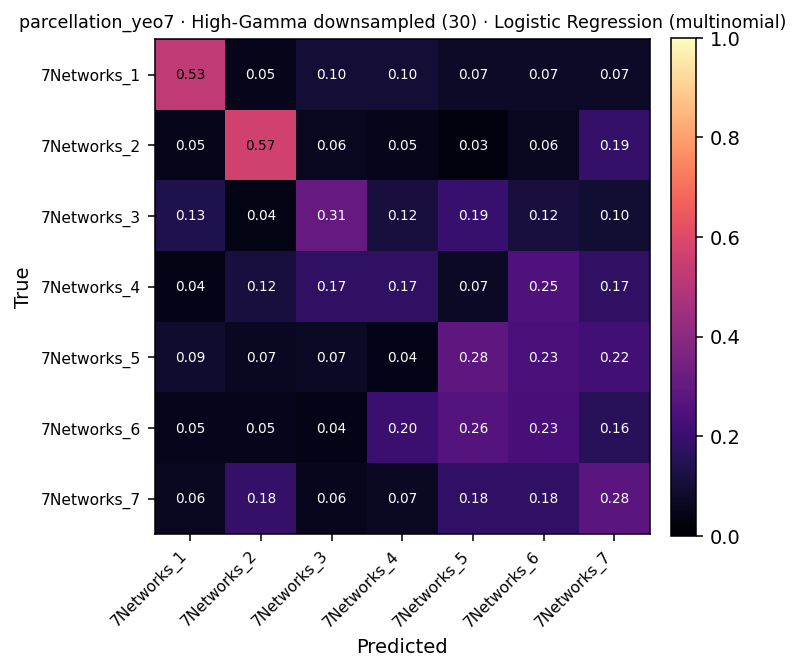

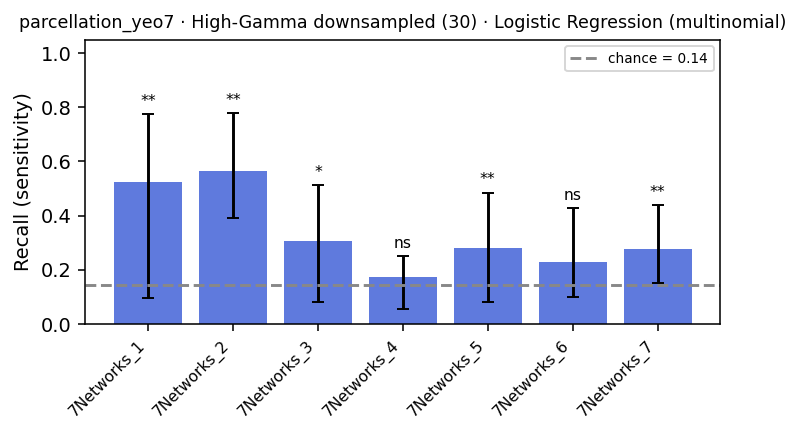

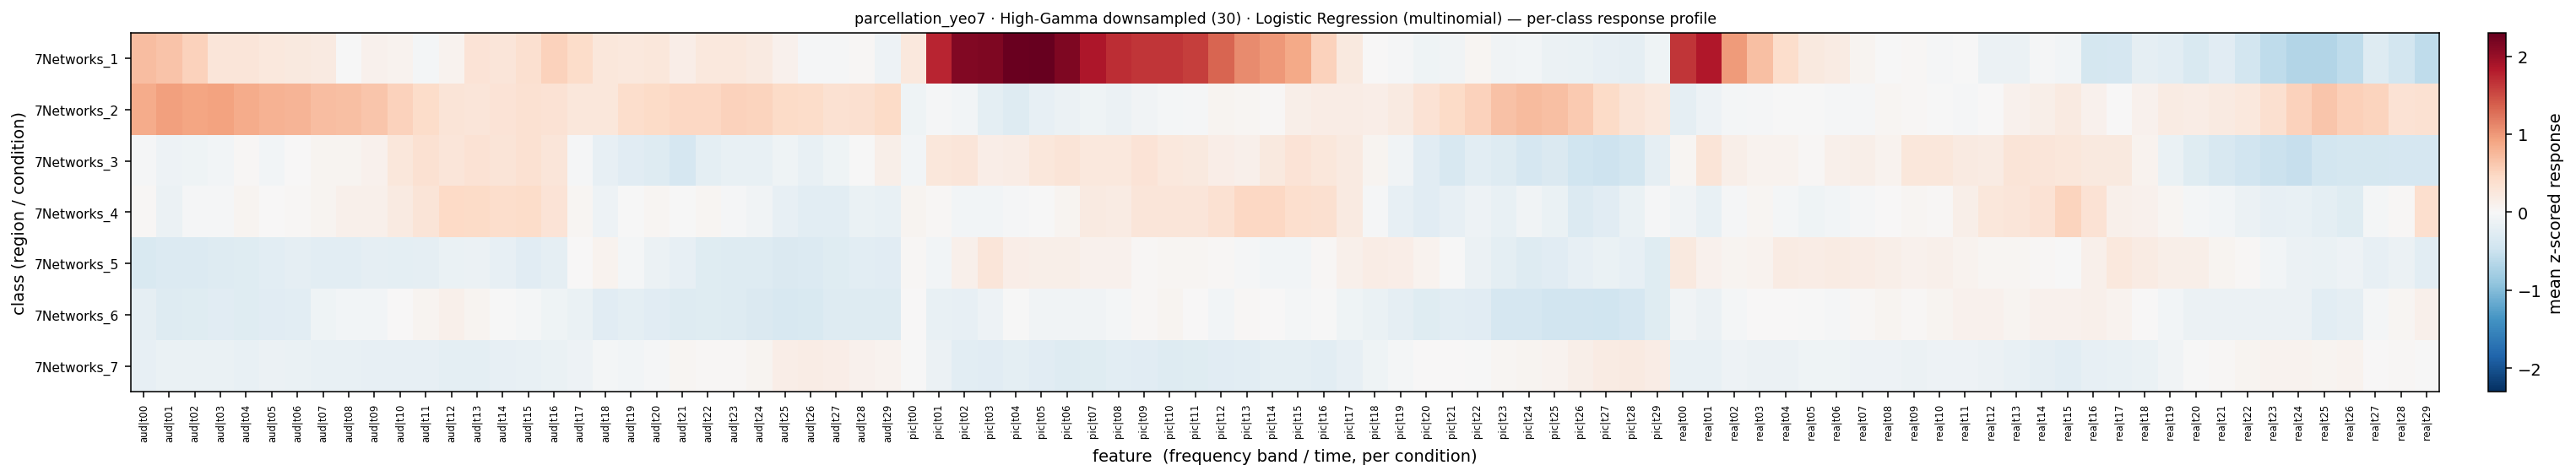

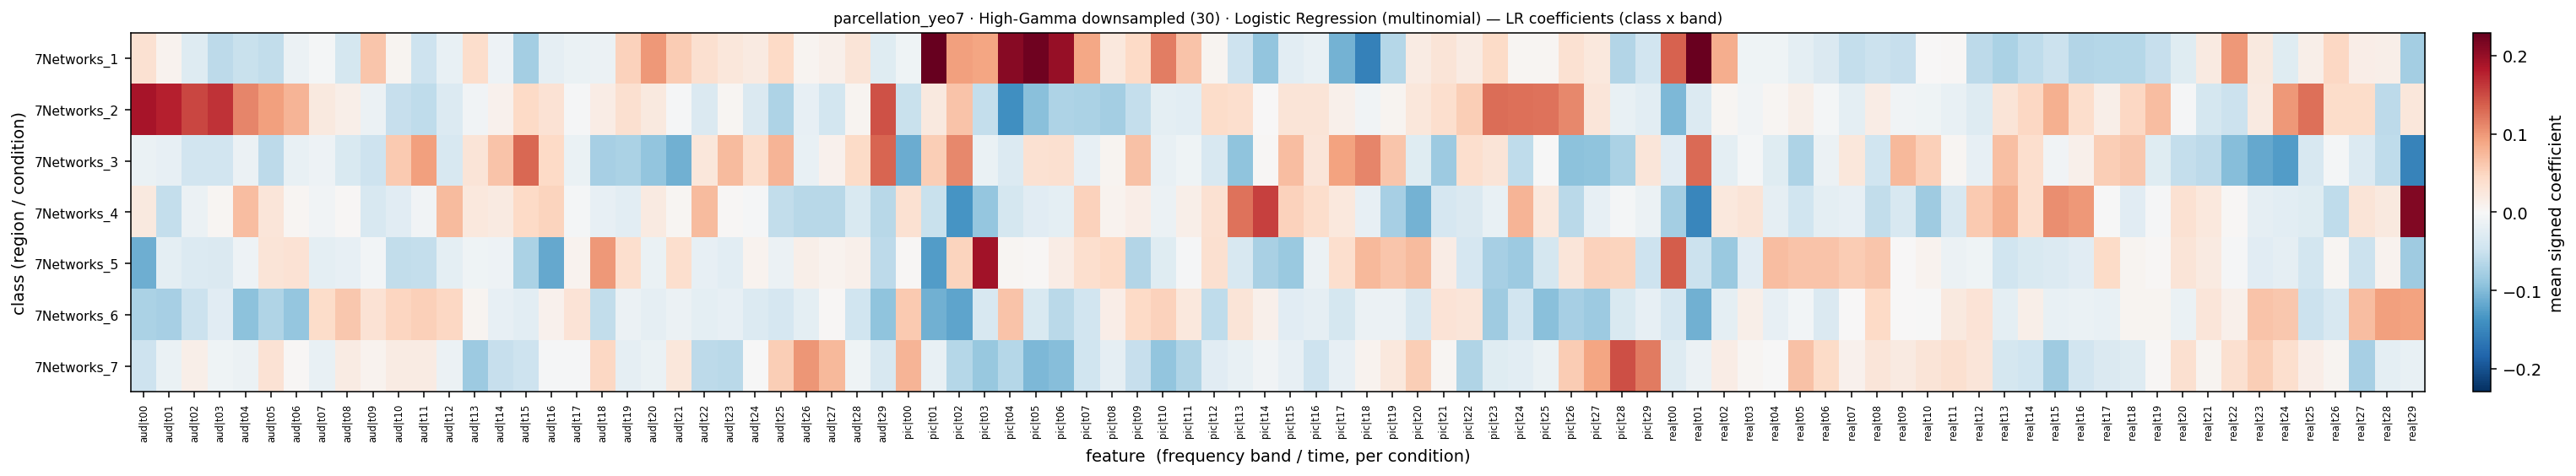

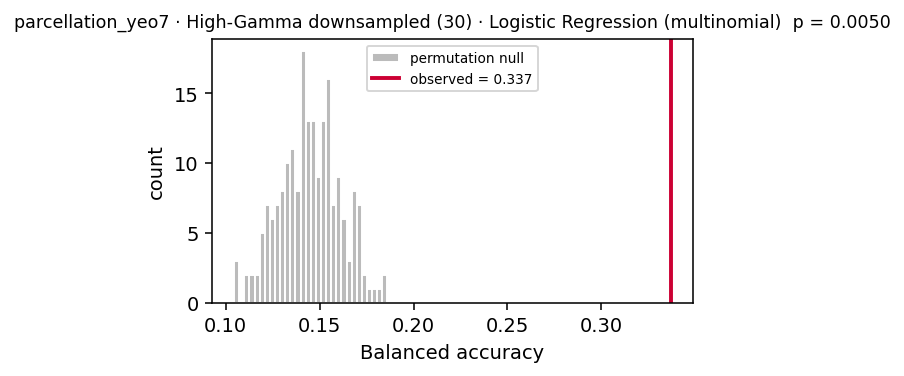

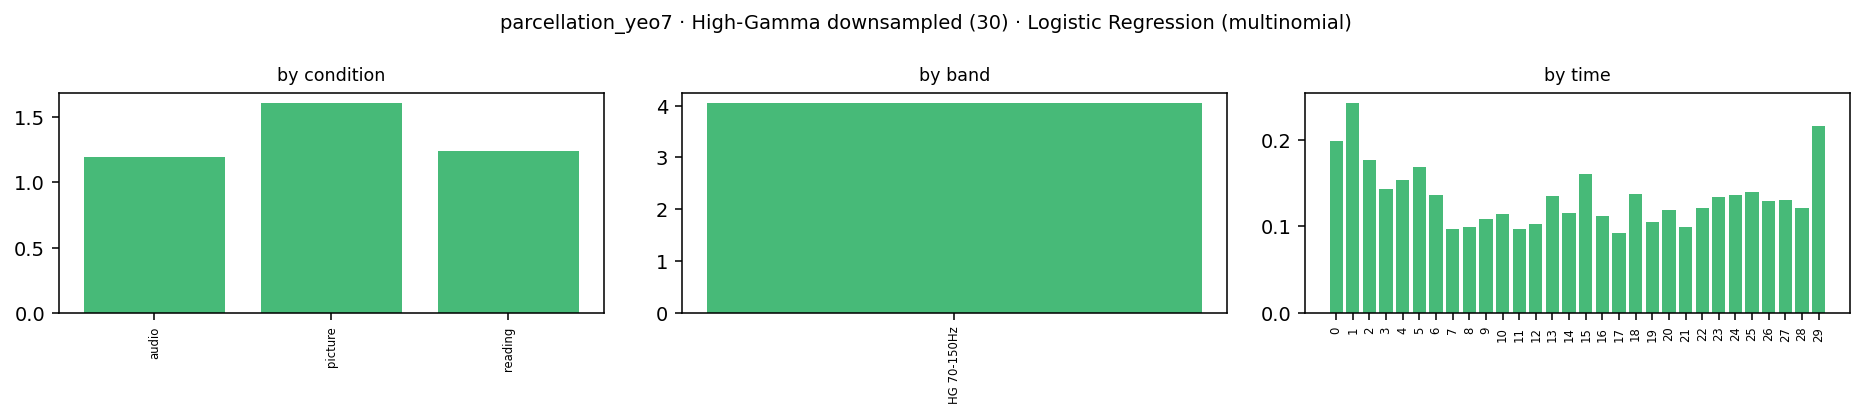

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,7Networks_1,40,0.525,0.095,0.773,0.259,0.347,0.805,0.009
1,7Networks_2,145,0.566,0.391,0.778,0.461,0.508,0.786,0.009
2,7Networks_3,52,0.308,0.082,0.515,0.203,0.244,0.753,0.028
3,7Networks_4,69,0.174,0.054,0.250,0.141,0.156,0.651,0.428
4,7Networks_5,181,0.282,0.080,0.485,0.307,0.294,0.617,0.009
5,7Networks_6,114,0.228,0.098,0.427,0.157,0.186,0.595,0.093
6,7Networks_7,357,0.277,0.152,0.440,0.488,0.354,0.604,0.009


### parcellation_yeo7 · High-Gamma downsampled (30) · Random Forest
- balanced accuracy **0.256** (chance 0.143; 95% CI 0.216–0.298)
- macro-F1 0.255 · accuracy 0.358 · **permutation p = 0.0050** · n=958 over 24 patients

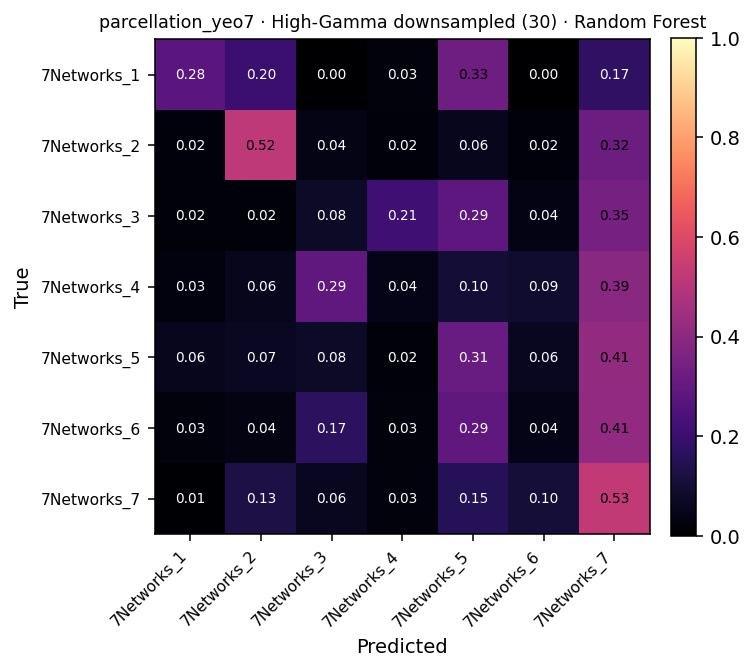

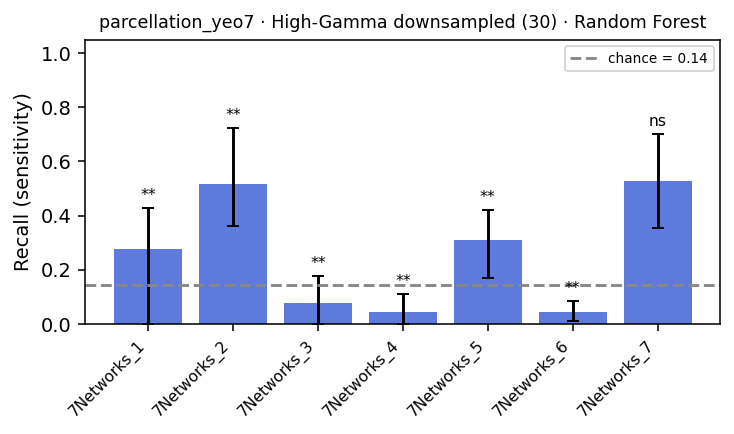

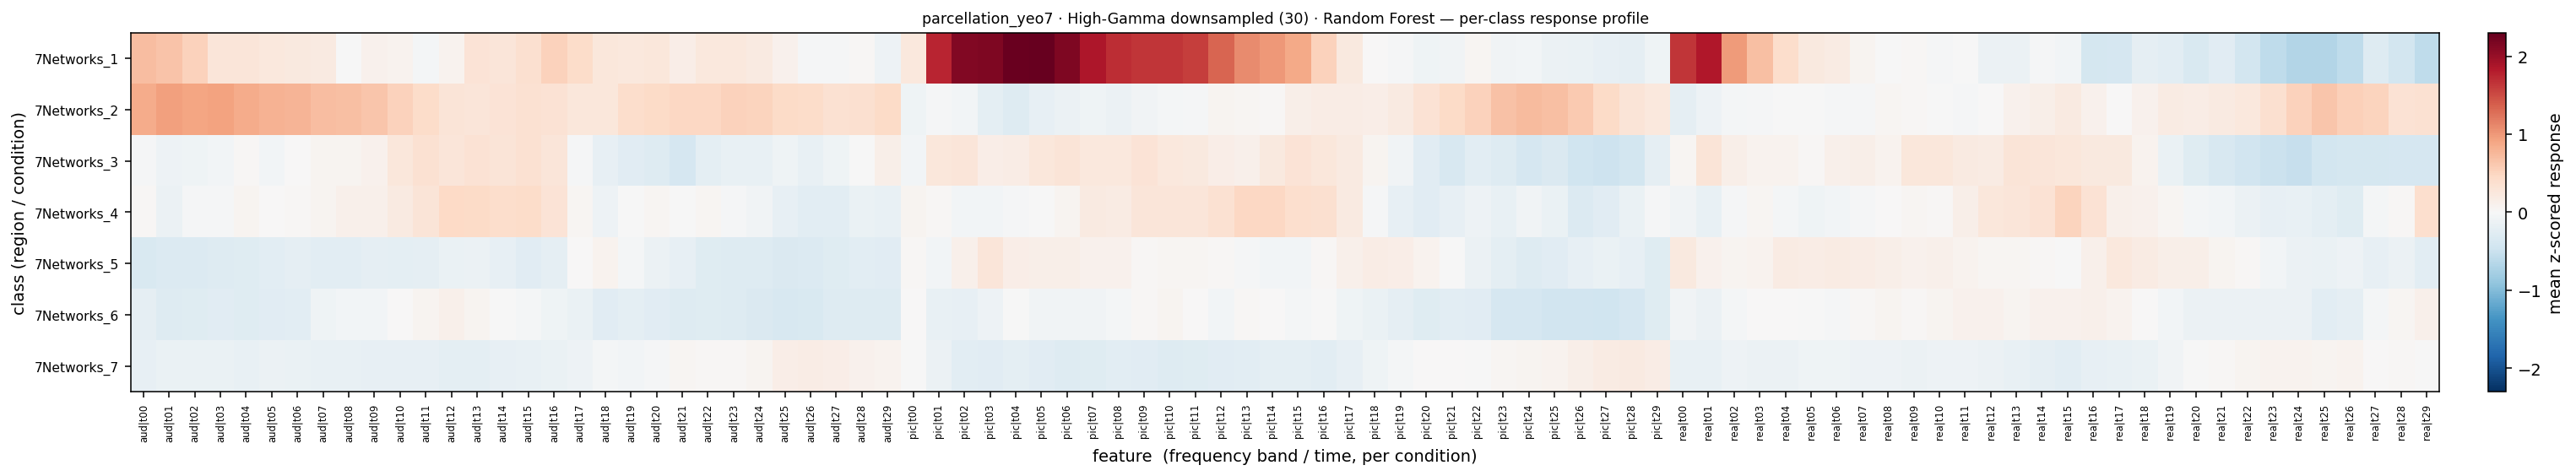

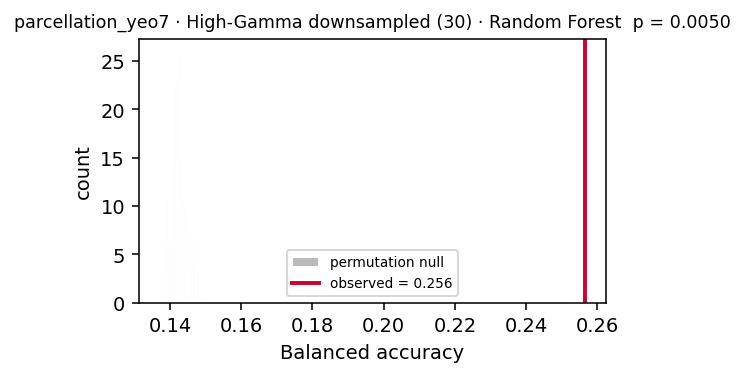

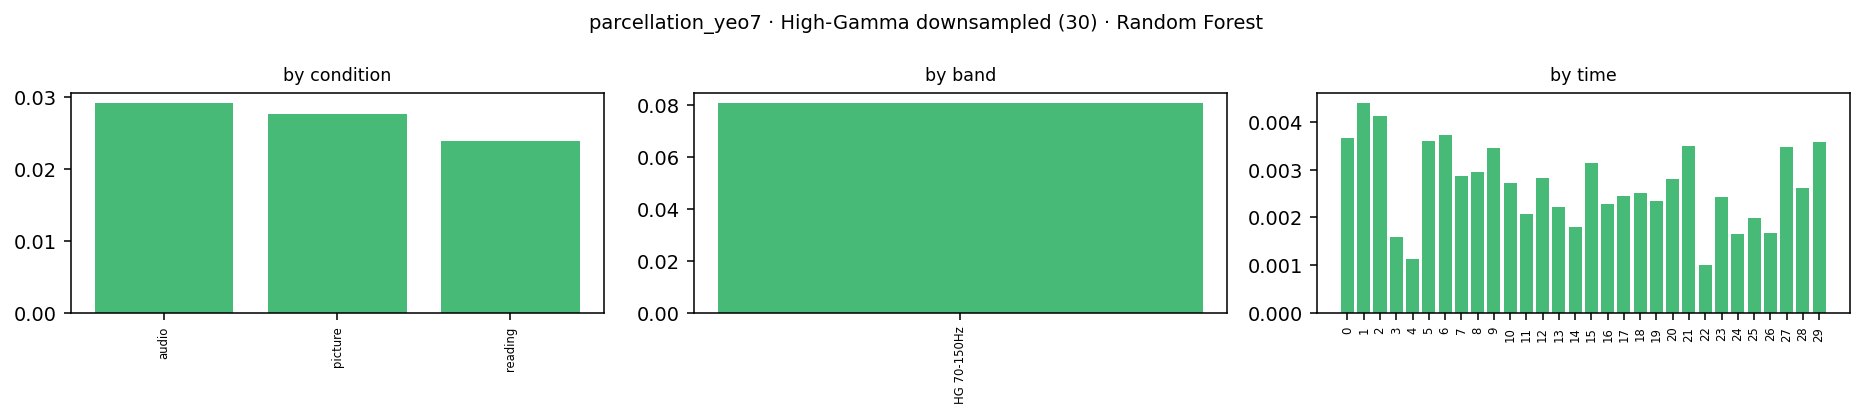

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,7Networks_1,40,0.275,0.000,0.429,0.344,0.306,0.747,0.006
1,7Networks_2,145,0.517,0.362,0.722,0.500,0.508,0.807,0.006
2,7Networks_3,52,0.077,0.000,0.178,0.048,0.059,0.637,0.006
3,7Networks_4,69,0.043,0.000,0.109,0.091,0.059,0.491,0.006
4,7Networks_5,181,0.309,0.169,0.421,0.303,0.306,0.579,0.006
5,7Networks_6,114,0.044,0.011,0.083,0.078,0.056,0.622,0.006
6,7Networks_7,357,0.529,0.354,0.702,0.461,0.493,0.614,1.000


## Yeo-17

### parcellation_yeo17 · Downsampled ERSP (15x30) · Logistic Regression (multinomial)
- balanced accuracy **0.192** (chance 0.059; 95% CI 0.148–0.229)
- macro-F1 0.189 · accuracy 0.299 · **permutation p = 0.0050** · n=958 over 24 patients

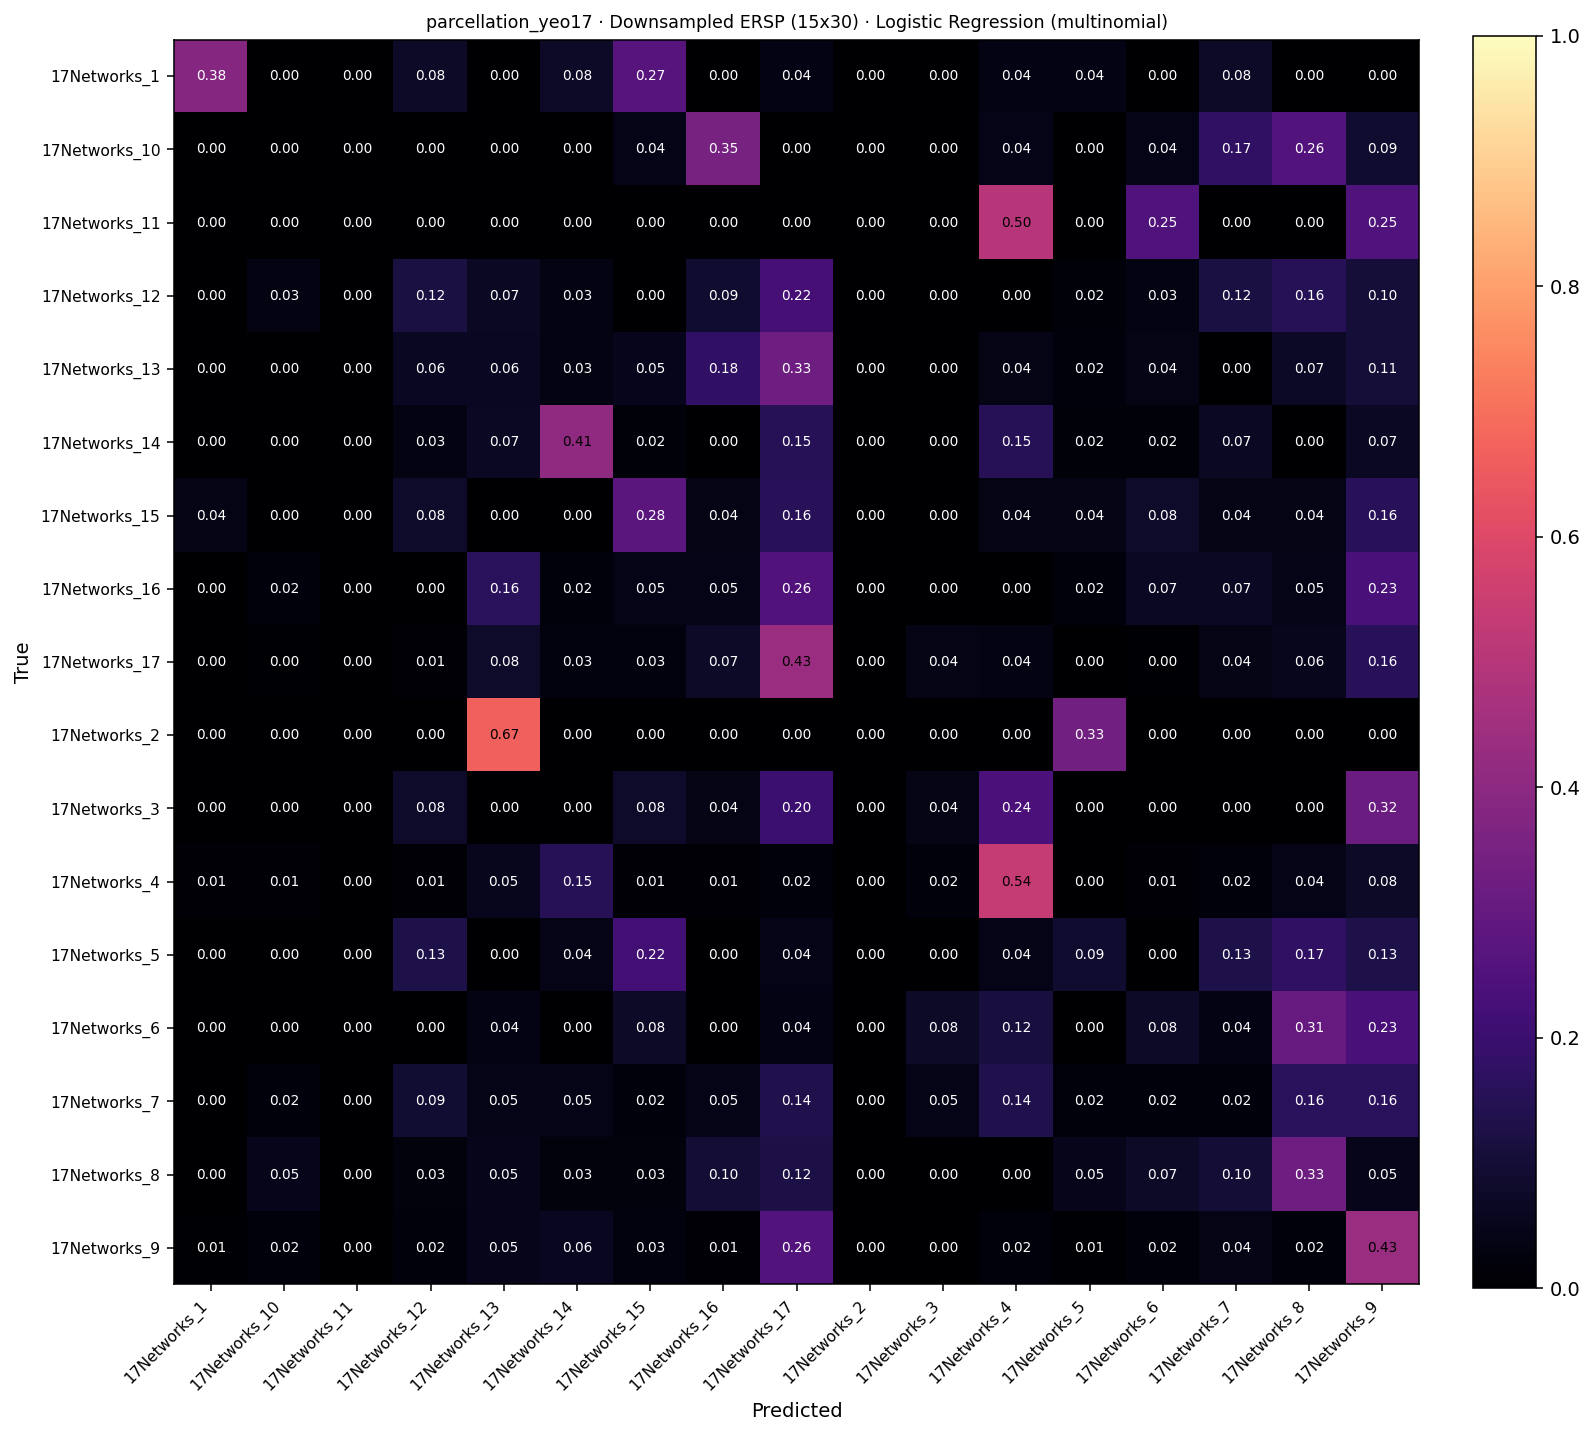

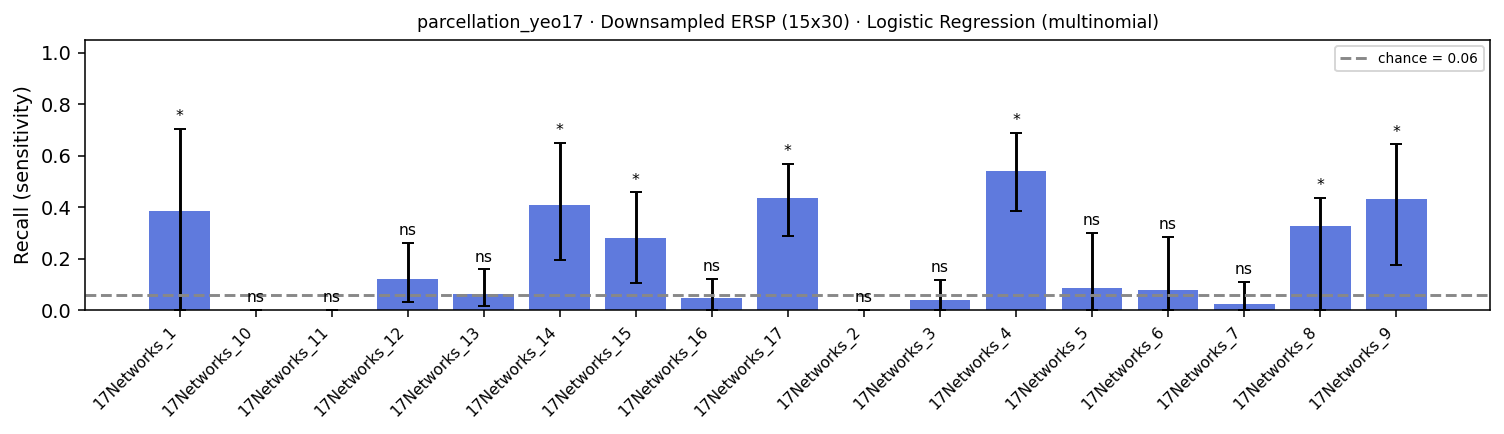

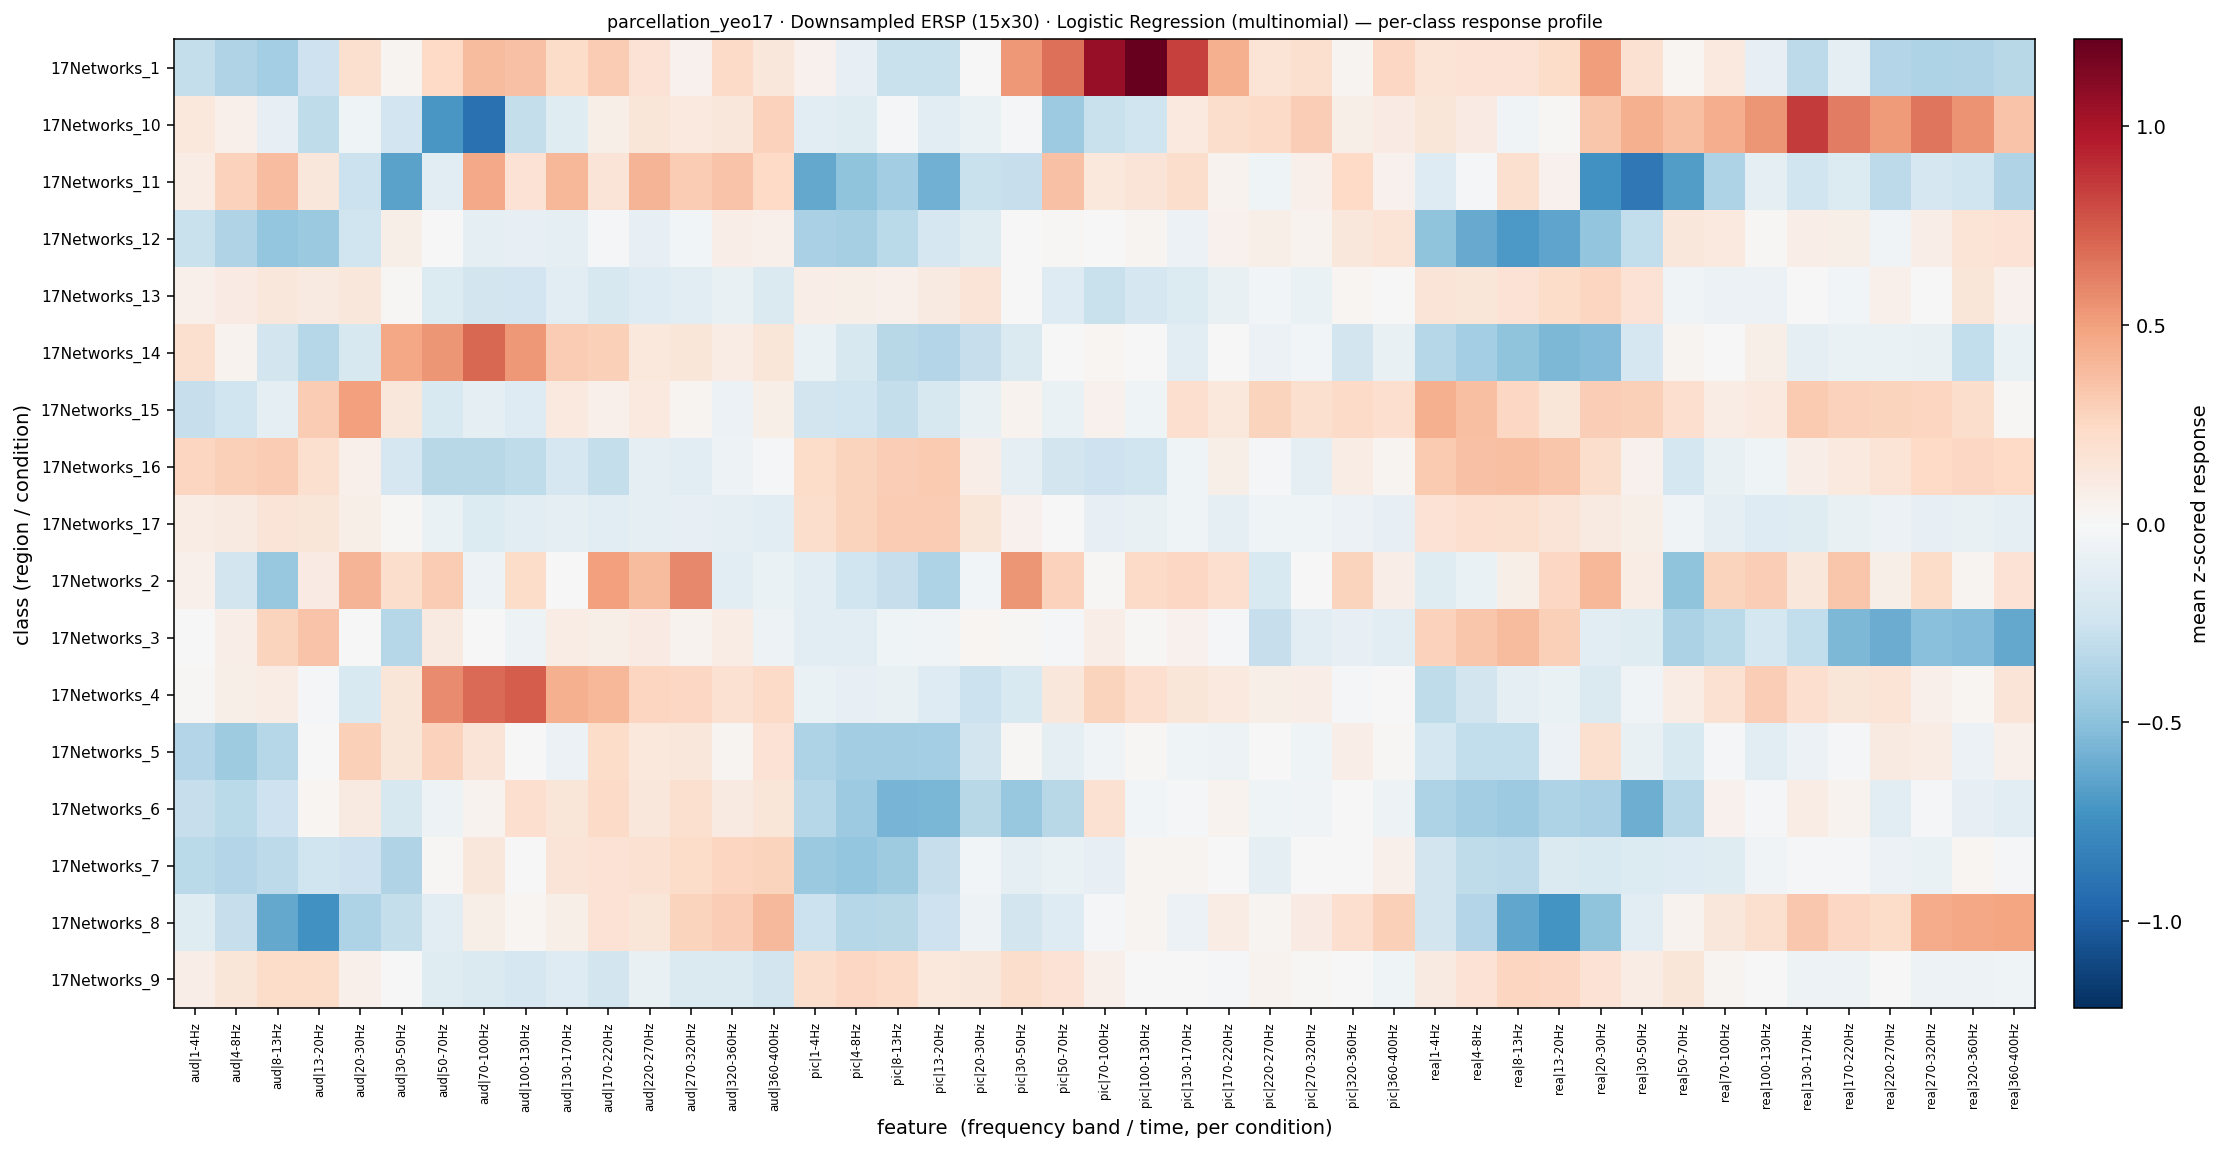

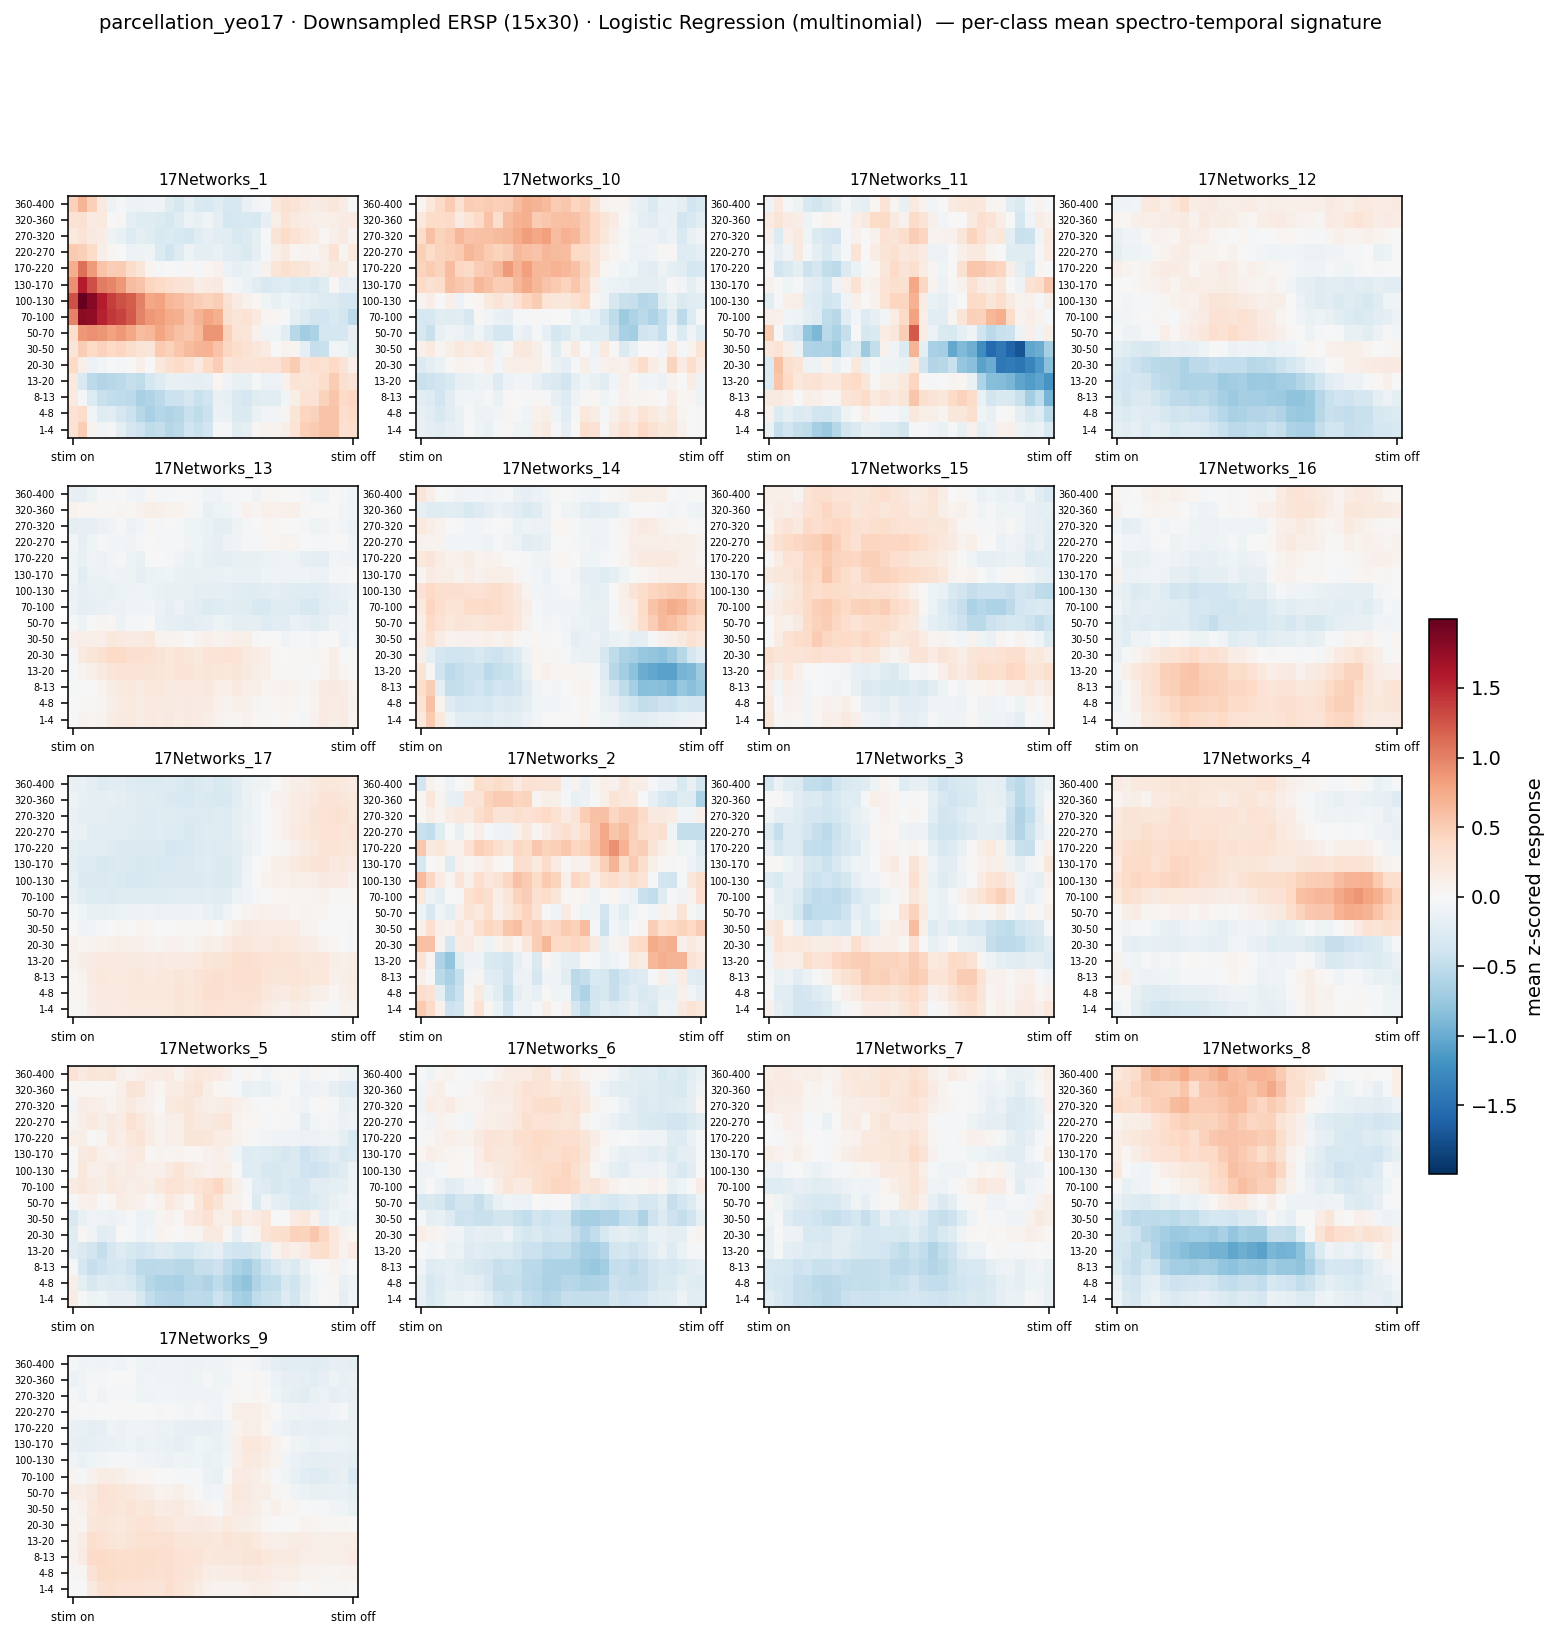

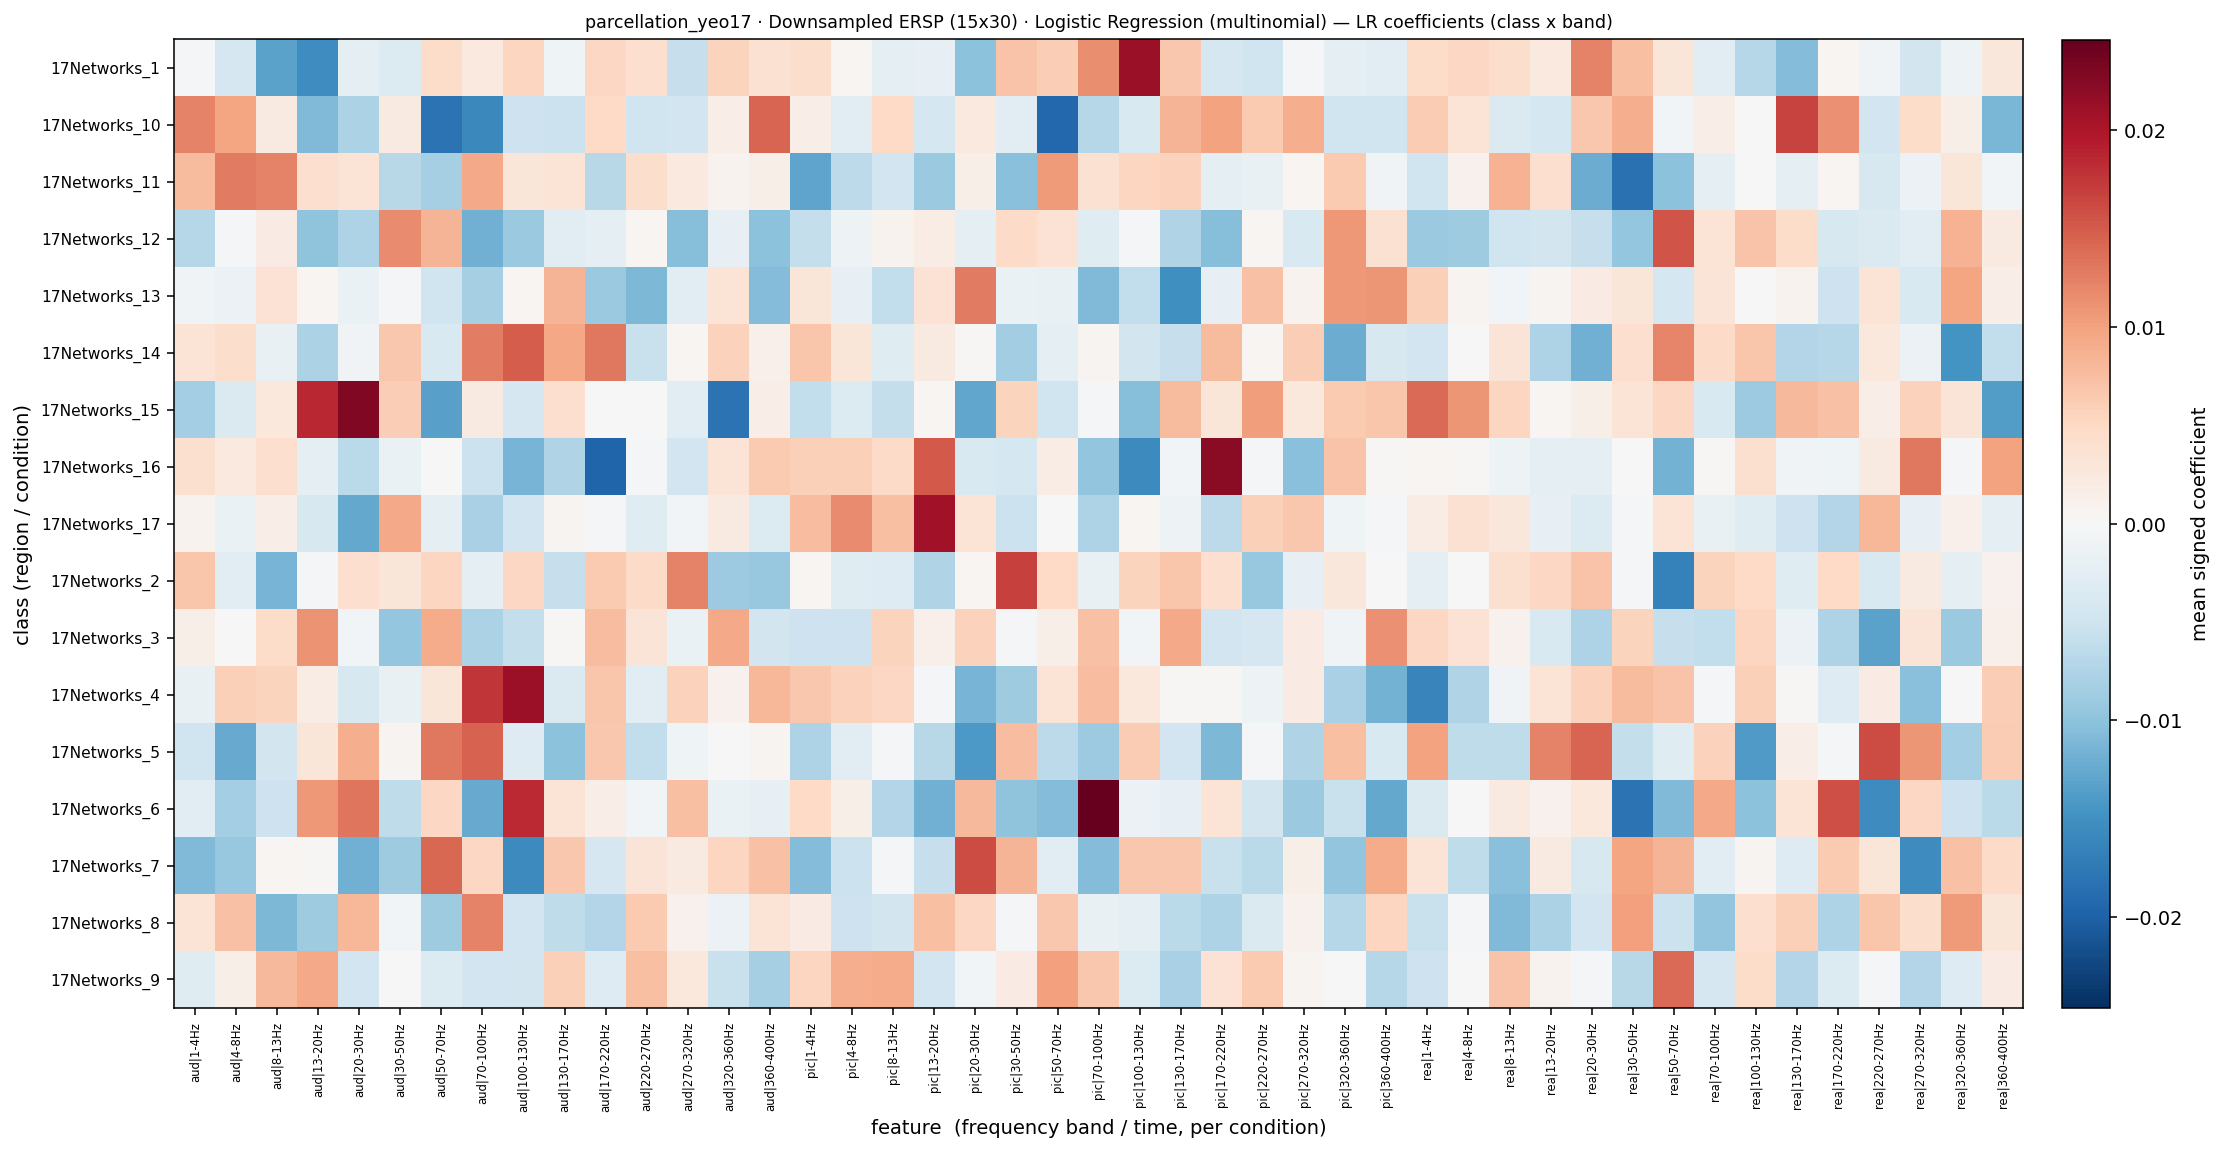

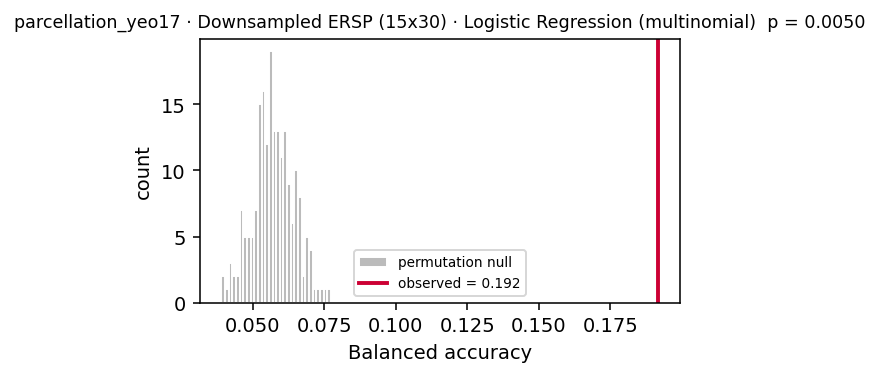

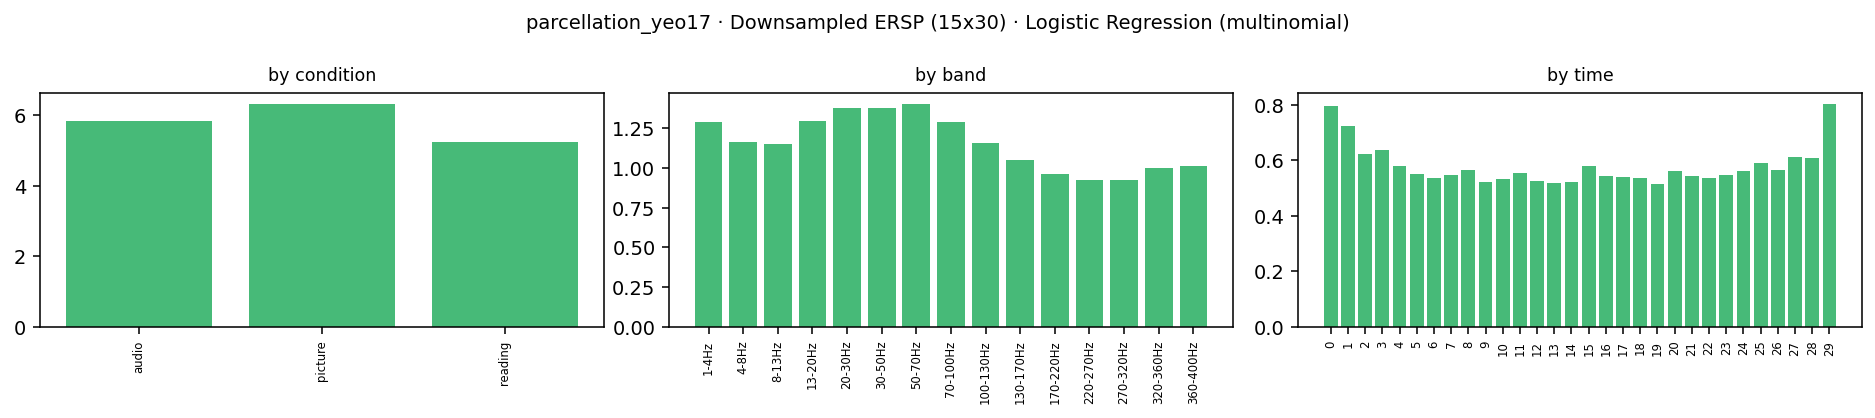

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,17Networks_1,26,0.385,0.000,0.704,0.769,0.513,0.950,0.012
1,17Networks_10,23,0.000,0.000,0.000,0.000,0.000,0.630,1.000
2,17Networks_11,4,0.000,0.000,0.000,0.000,0.000,0.340,1.000
3,17Networks_12,58,0.121,0.032,0.260,0.194,0.149,0.647,0.178
4,17Networks_13,95,0.063,0.017,0.158,0.103,0.078,0.475,1.000
5,17Networks_14,59,0.407,0.194,0.649,0.364,0.384,0.848,0.012
6,17Networks_15,25,0.280,0.105,0.457,0.152,0.197,0.791,0.012
7,17Networks_16,43,0.047,0.000,0.122,0.033,0.039,0.562,0.761
8,17Networks_17,228,0.434,0.286,0.568,0.438,0.436,0.727,0.012
9,17Networks_2,3,0.000,0.000,0.000,0.000,0.000,0.520,1.000


### parcellation_yeo17 · Downsampled ERSP (15x30) · Random Forest
- balanced accuracy **0.151** (chance 0.059; 95% CI 0.117–0.180)
- macro-F1 0.138 · accuracy 0.286 · **permutation p = 0.0050** · n=958 over 24 patients

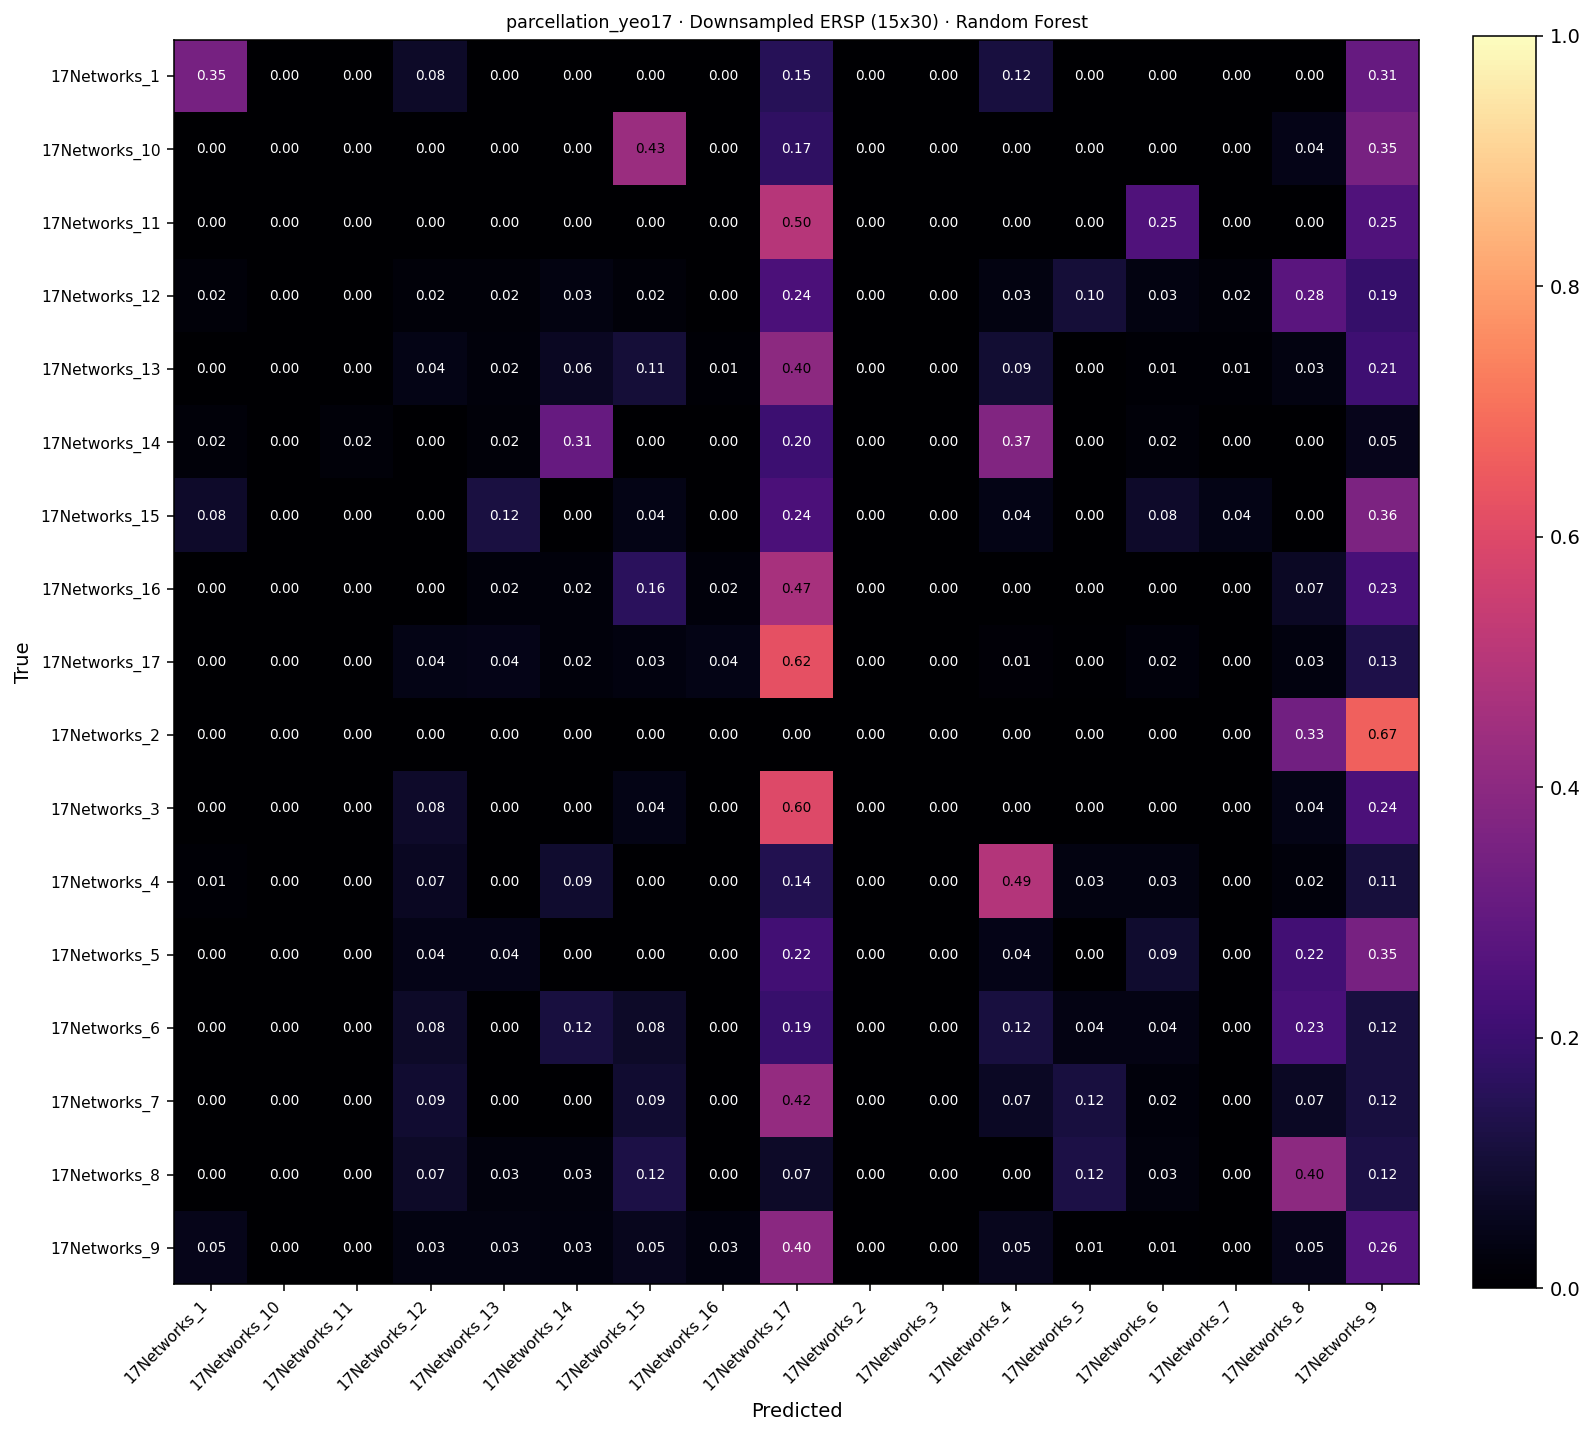

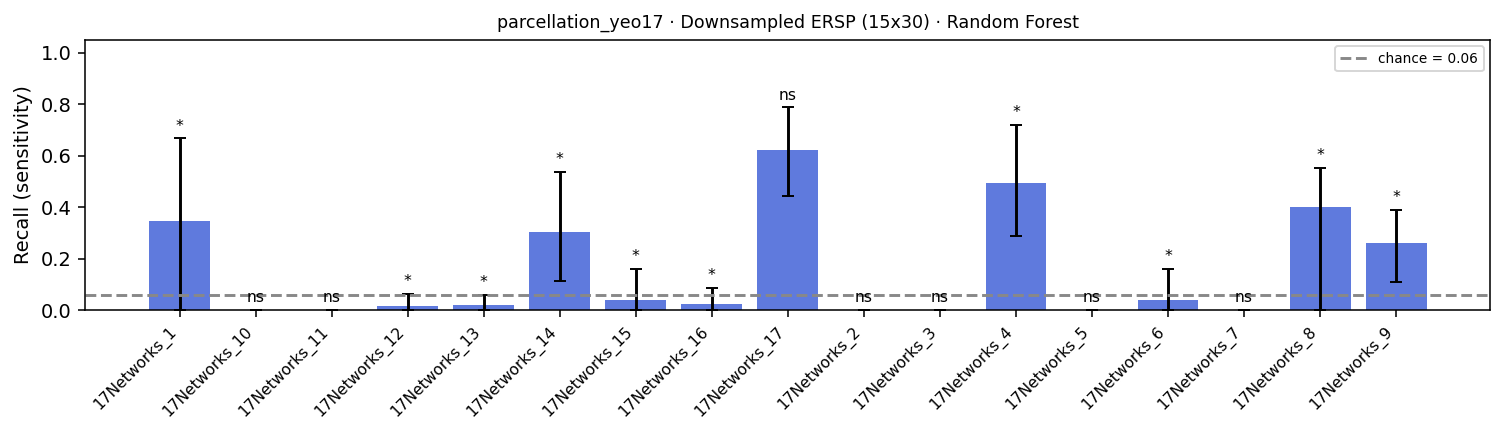

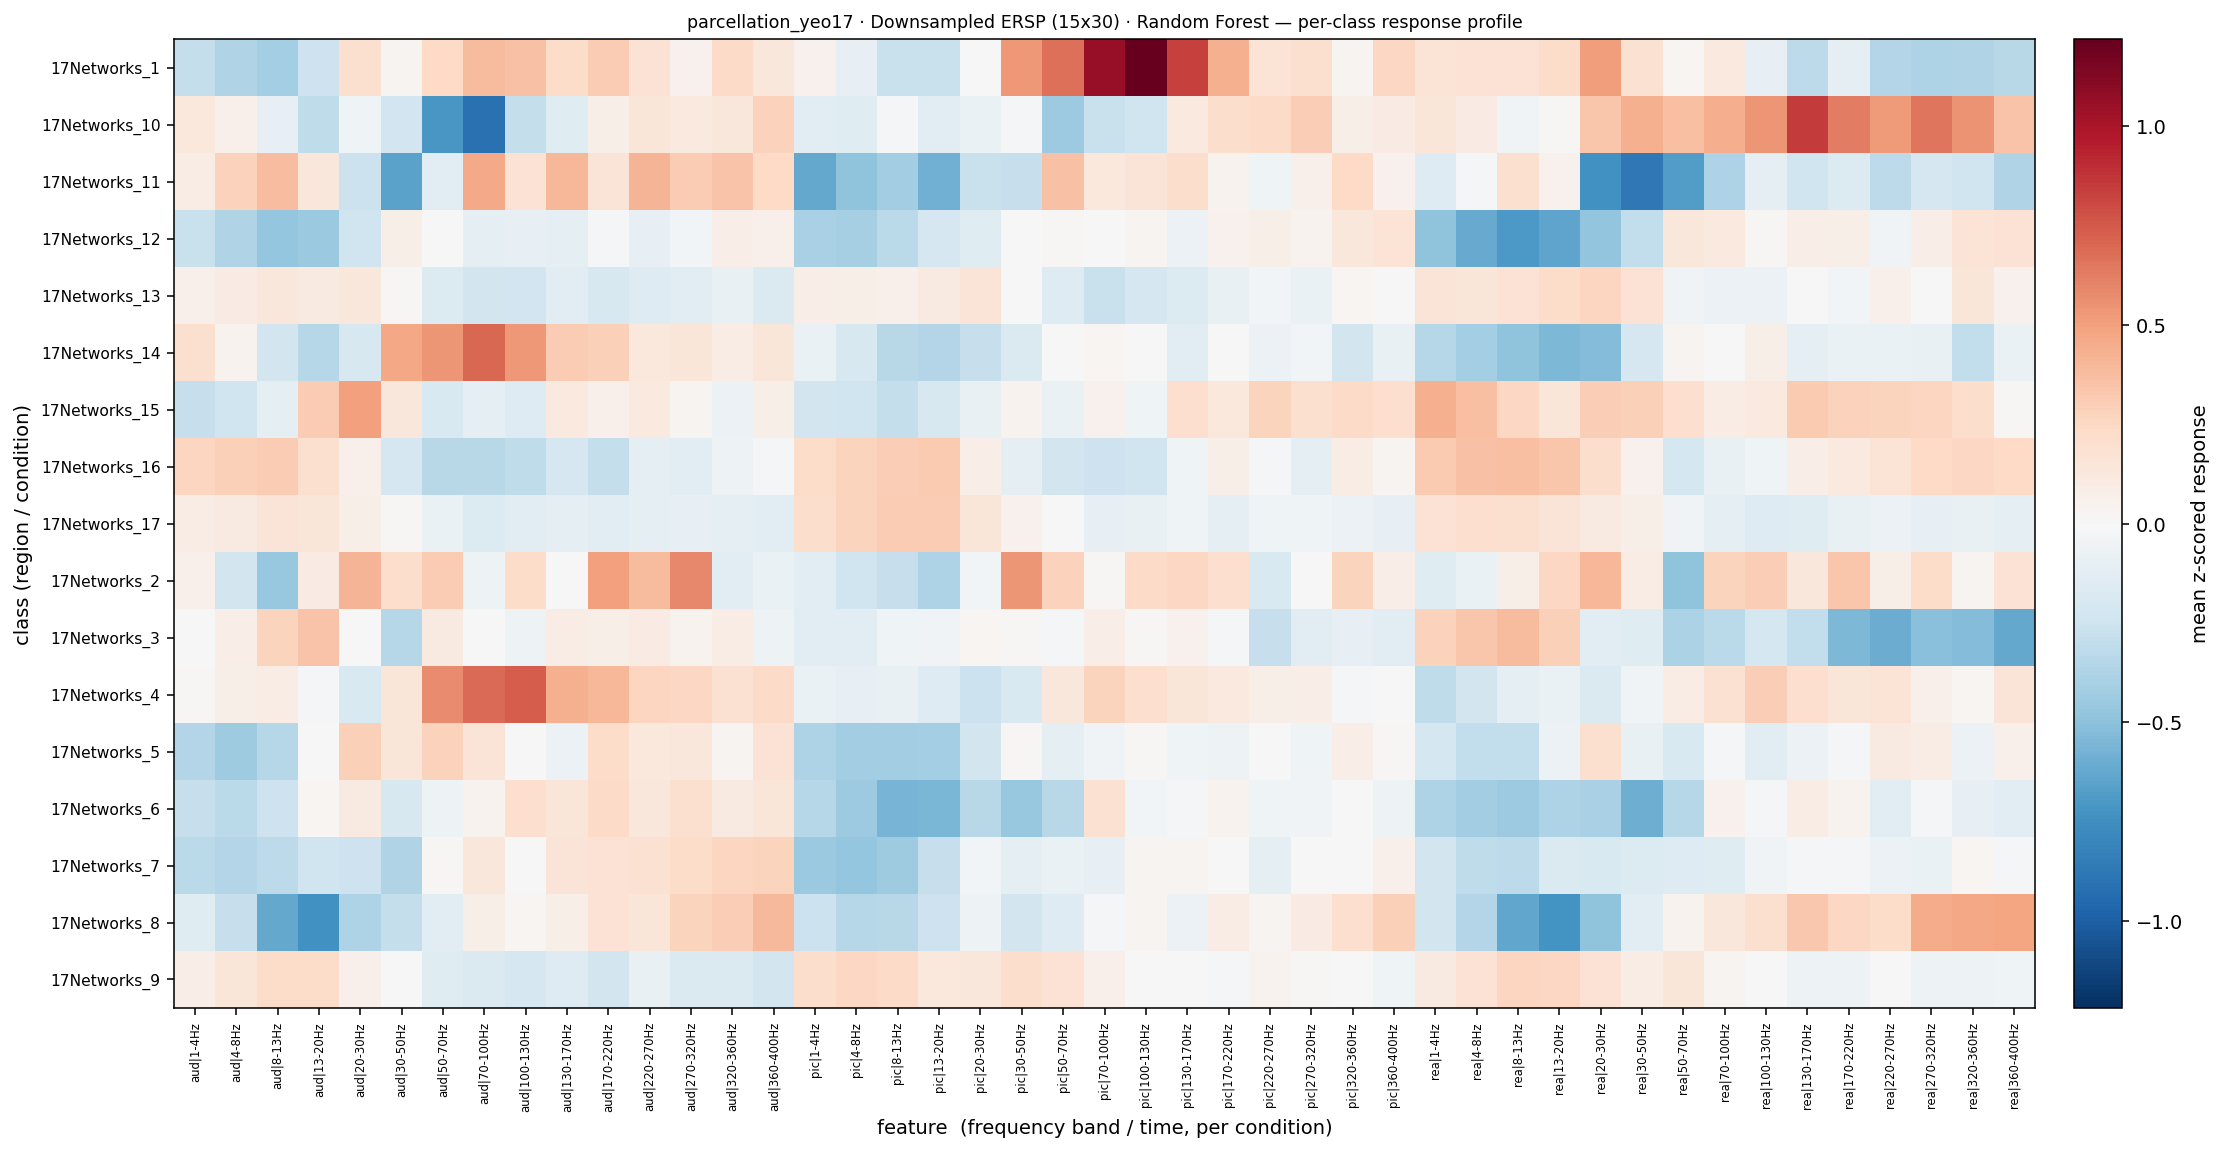

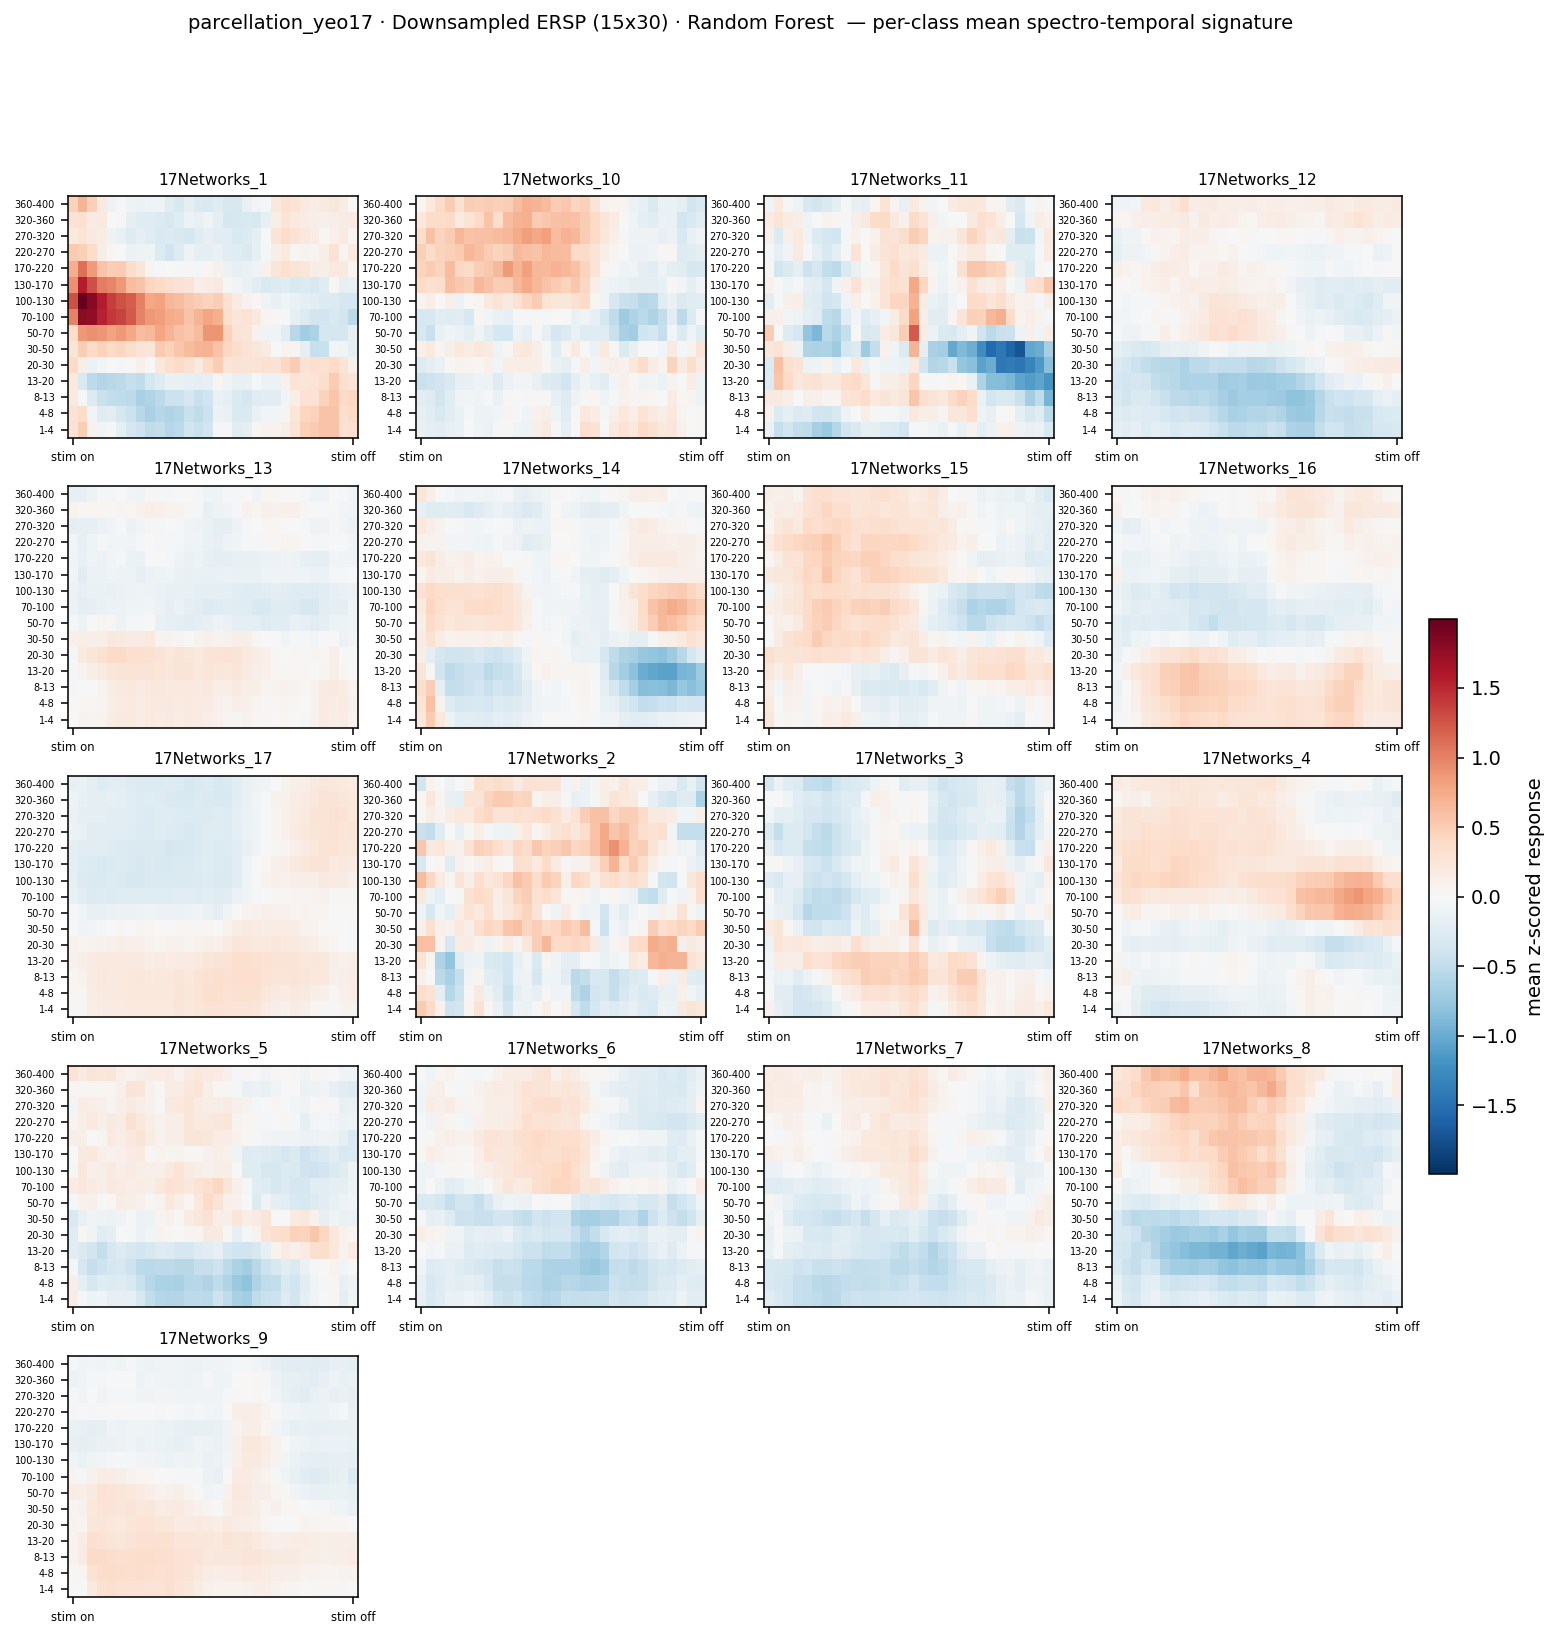

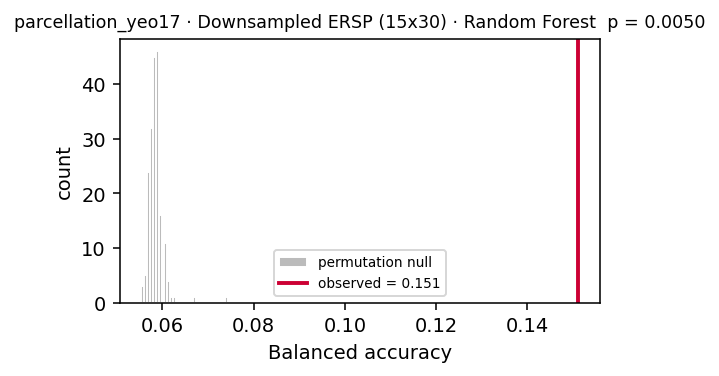

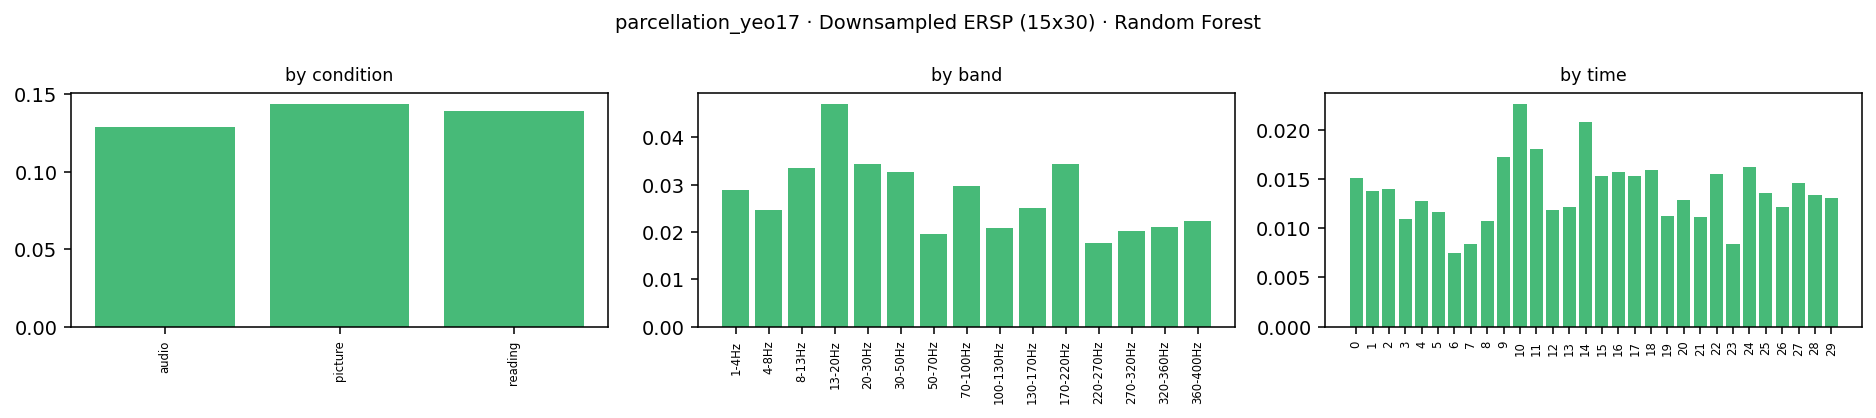

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,17Networks_1,26,0.346,0.000,0.667,0.429,0.383,0.910,0.017
1,17Networks_10,23,0.000,0.000,0.000,0.000,0.000,0.549,1.000
2,17Networks_11,4,0.000,0.000,0.000,0.000,0.000,0.184,1.000
3,17Networks_12,58,0.017,0.000,0.064,0.026,0.021,0.699,0.024
4,17Networks_13,95,0.021,0.000,0.058,0.080,0.033,0.545,0.028
5,17Networks_14,59,0.305,0.114,0.536,0.375,0.336,0.847,0.017
6,17Networks_15,25,0.040,0.000,0.160,0.018,0.025,0.616,0.042
7,17Networks_16,43,0.023,0.000,0.087,0.067,0.034,0.571,0.024
8,17Networks_17,228,0.623,0.445,0.788,0.396,0.484,0.694,1.000
9,17Networks_2,3,0.000,0.000,0.000,0.000,0.000,0.056,1.000


### parcellation_yeo17 · High-Gamma series (300) · Logistic Regression (multinomial)
- balanced accuracy **0.162** (chance 0.059; 95% CI 0.114–0.196)
- macro-F1 0.156 · accuracy 0.220 · **permutation p = 0.0050** · n=958 over 24 patients

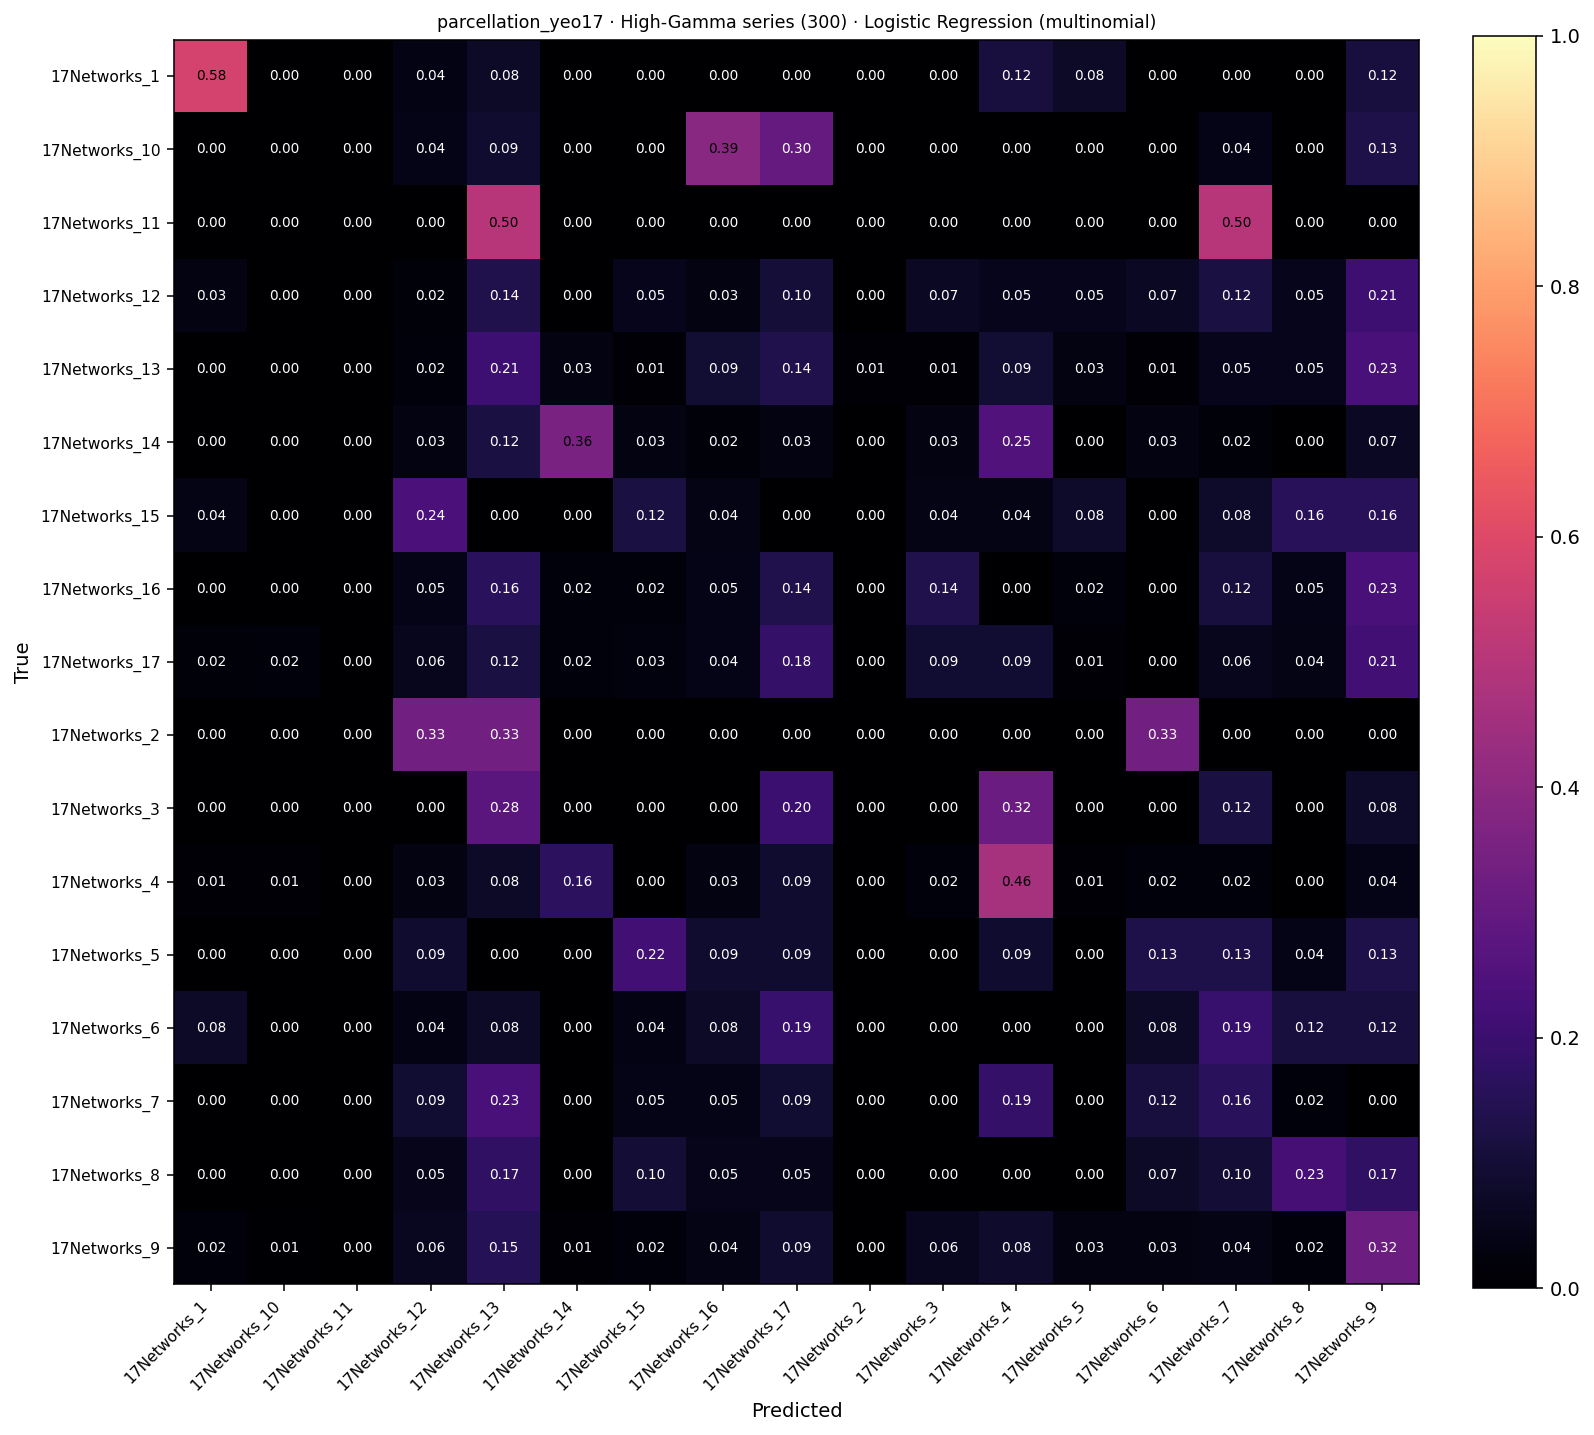

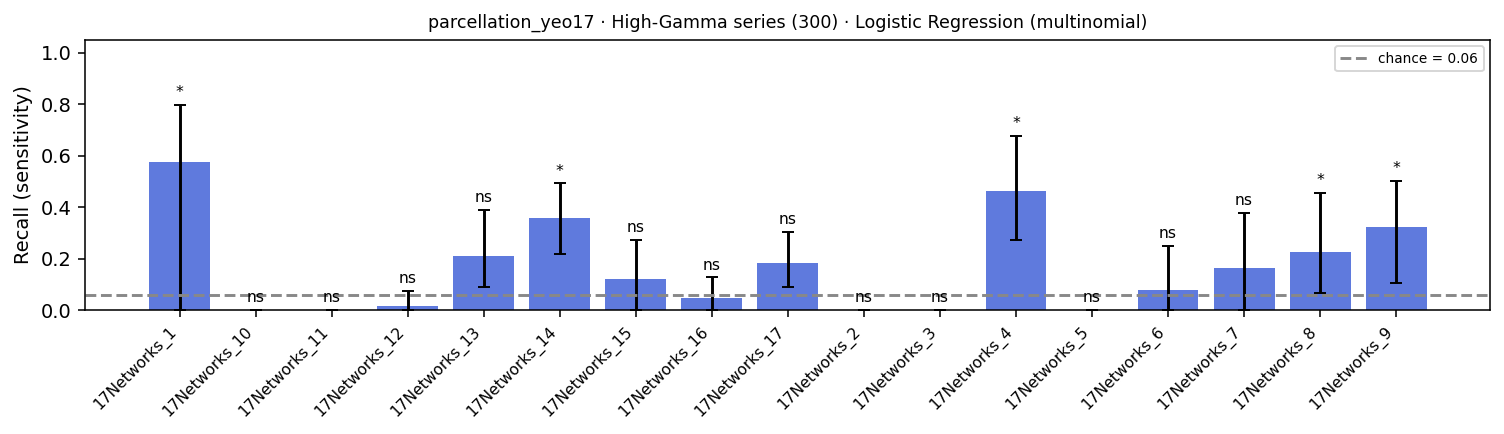

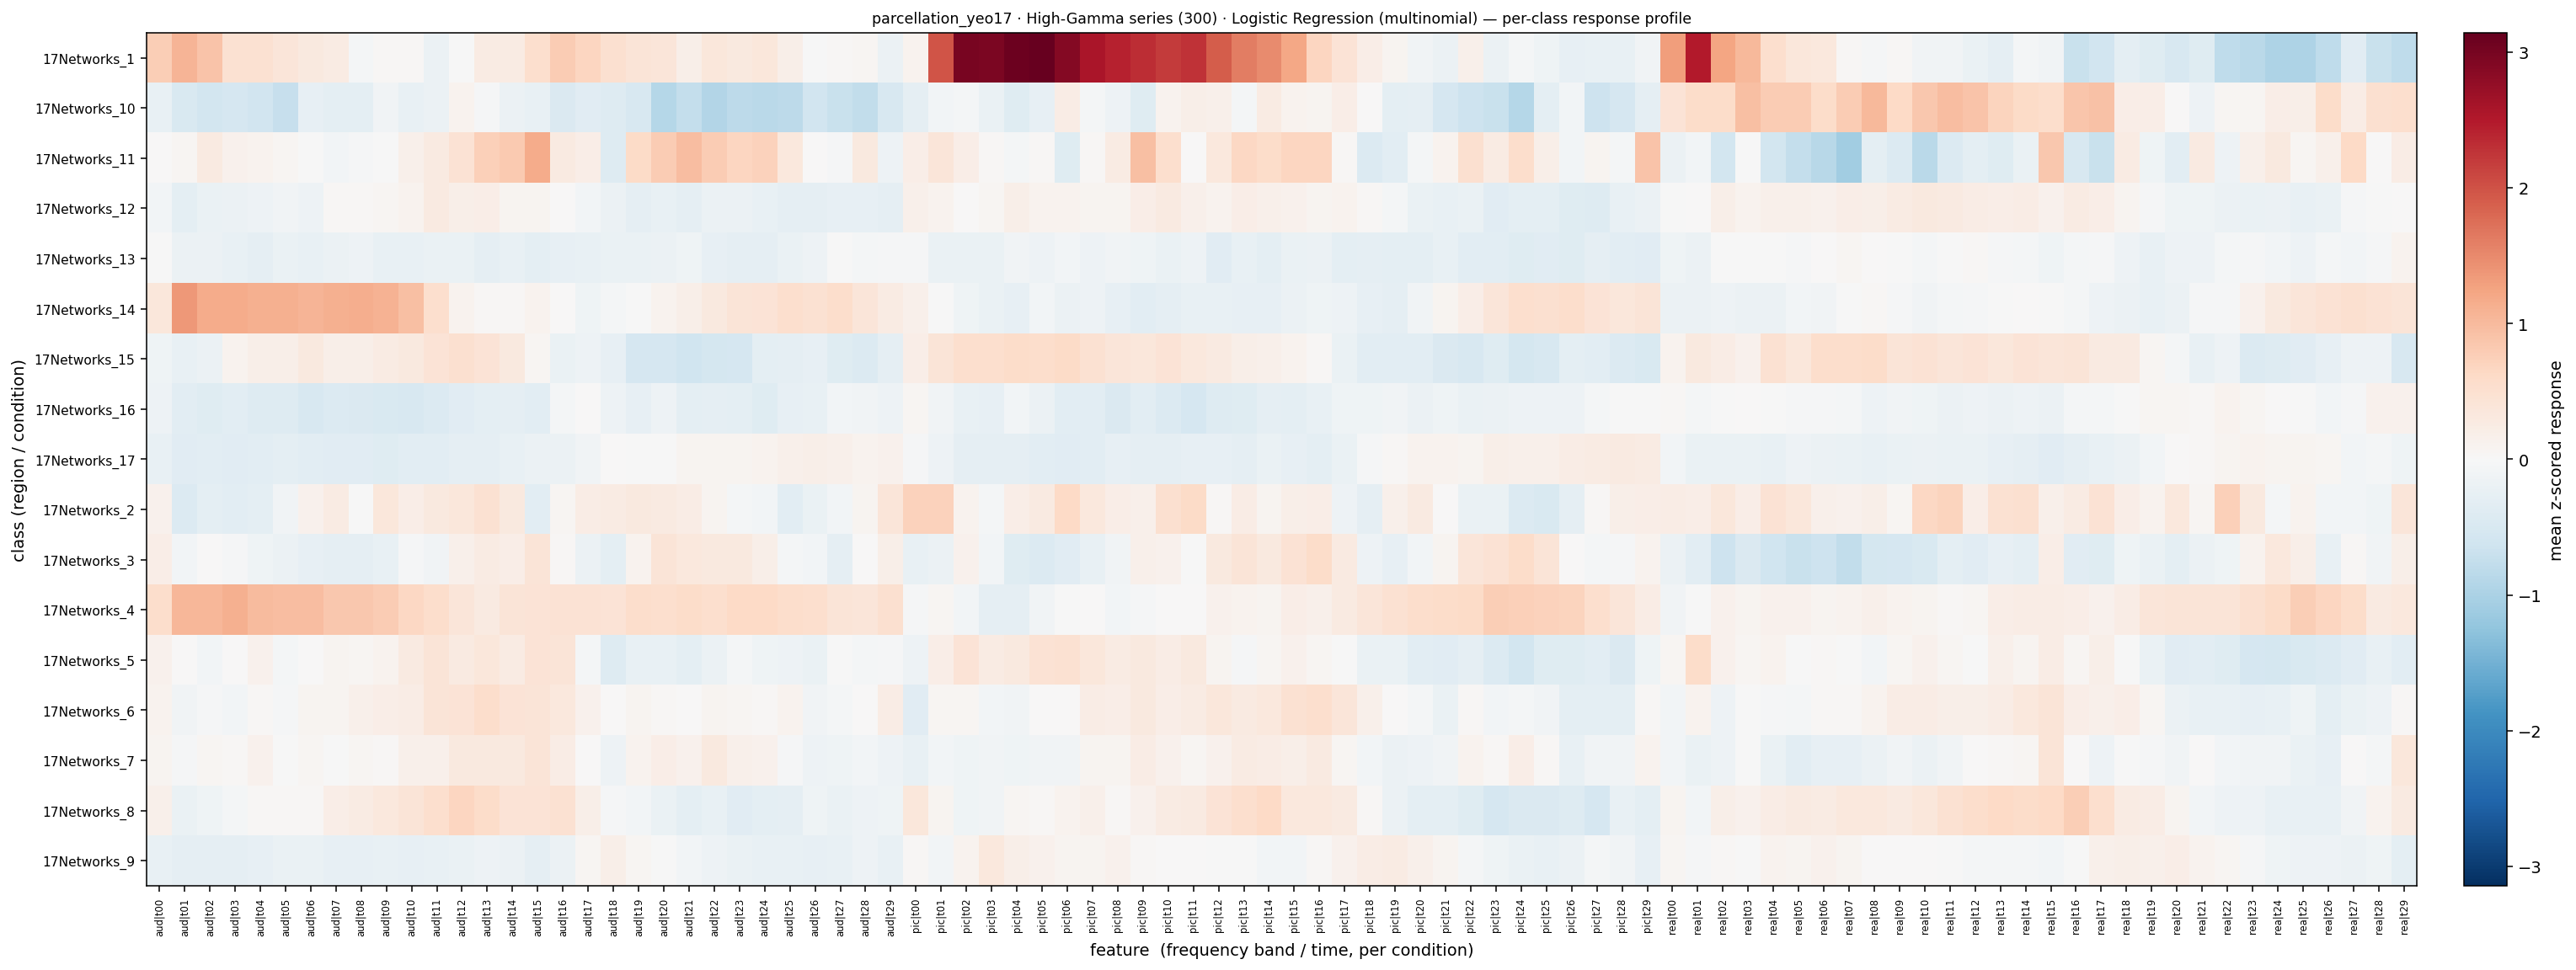

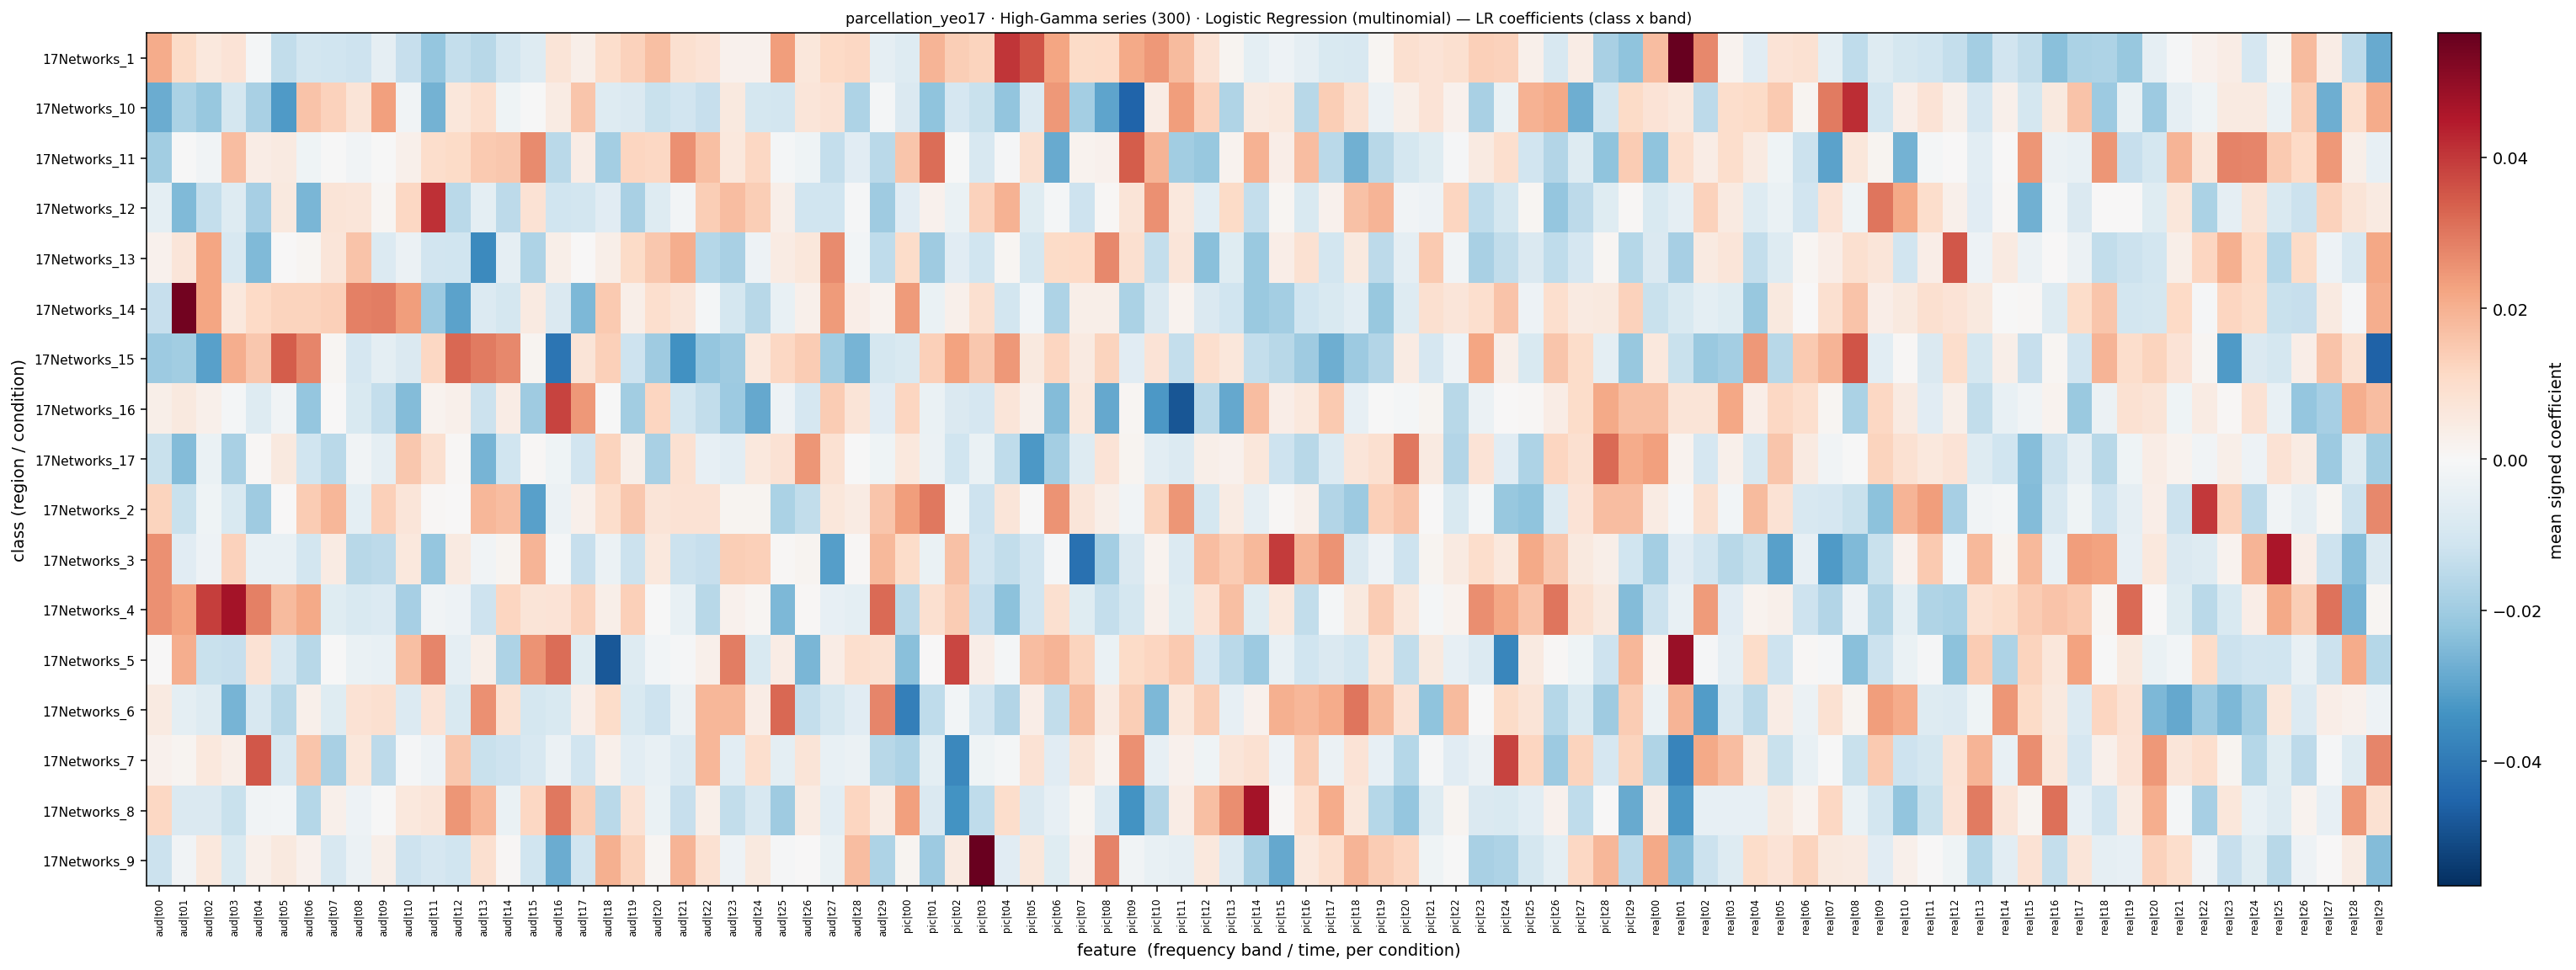

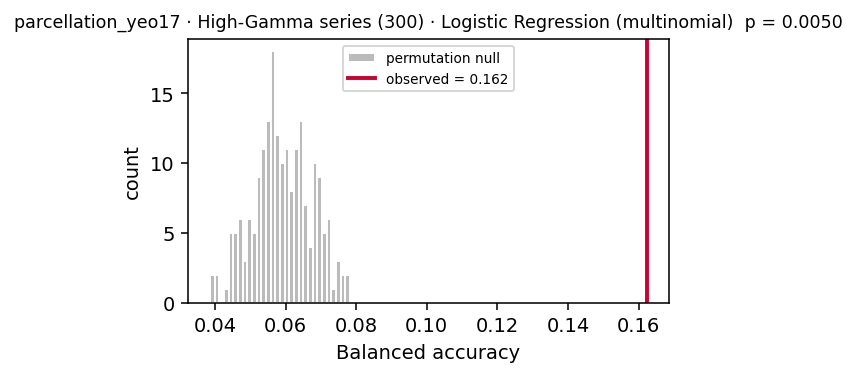

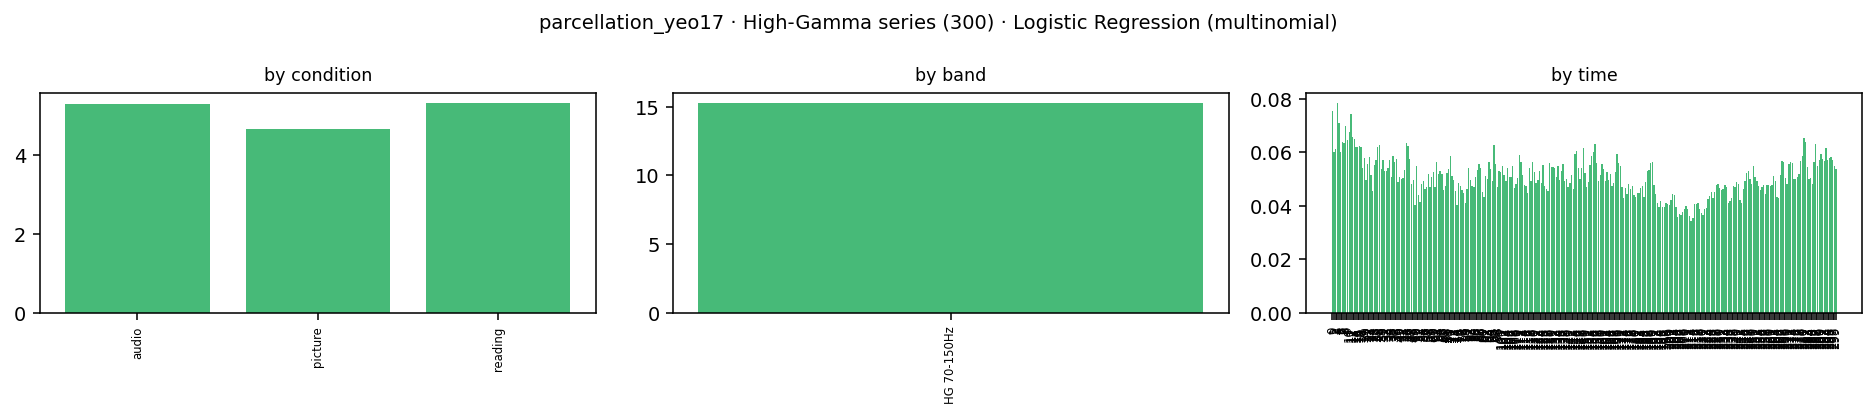

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,17Networks_1,26,0.577,0.000,0.796,0.536,0.556,0.931,0.021
1,17Networks_10,23,0.000,0.000,0.000,0.000,0.000,0.396,1.000
2,17Networks_11,4,0.000,0.000,0.000,0.000,0.000,0.294,1.000
3,17Networks_12,58,0.017,0.000,0.074,0.020,0.019,0.500,1.000
4,17Networks_13,95,0.211,0.091,0.388,0.153,0.177,0.543,0.074
5,17Networks_14,59,0.356,0.217,0.492,0.447,0.396,0.746,0.021
6,17Networks_15,25,0.120,0.000,0.273,0.094,0.105,0.583,0.060
7,17Networks_16,43,0.047,0.000,0.128,0.039,0.043,0.618,0.892
8,17Networks_17,228,0.184,0.091,0.305,0.365,0.245,0.634,0.892
9,17Networks_2,3,0.000,0.000,0.000,0.000,0.000,0.310,1.000


### parcellation_yeo17 · High-Gamma series (300) · Random Forest
- balanced accuracy **0.131** (chance 0.059; 95% CI 0.108–0.167)
- macro-F1 0.120 · accuracy 0.249 · **permutation p = 0.0050** · n=958 over 24 patients

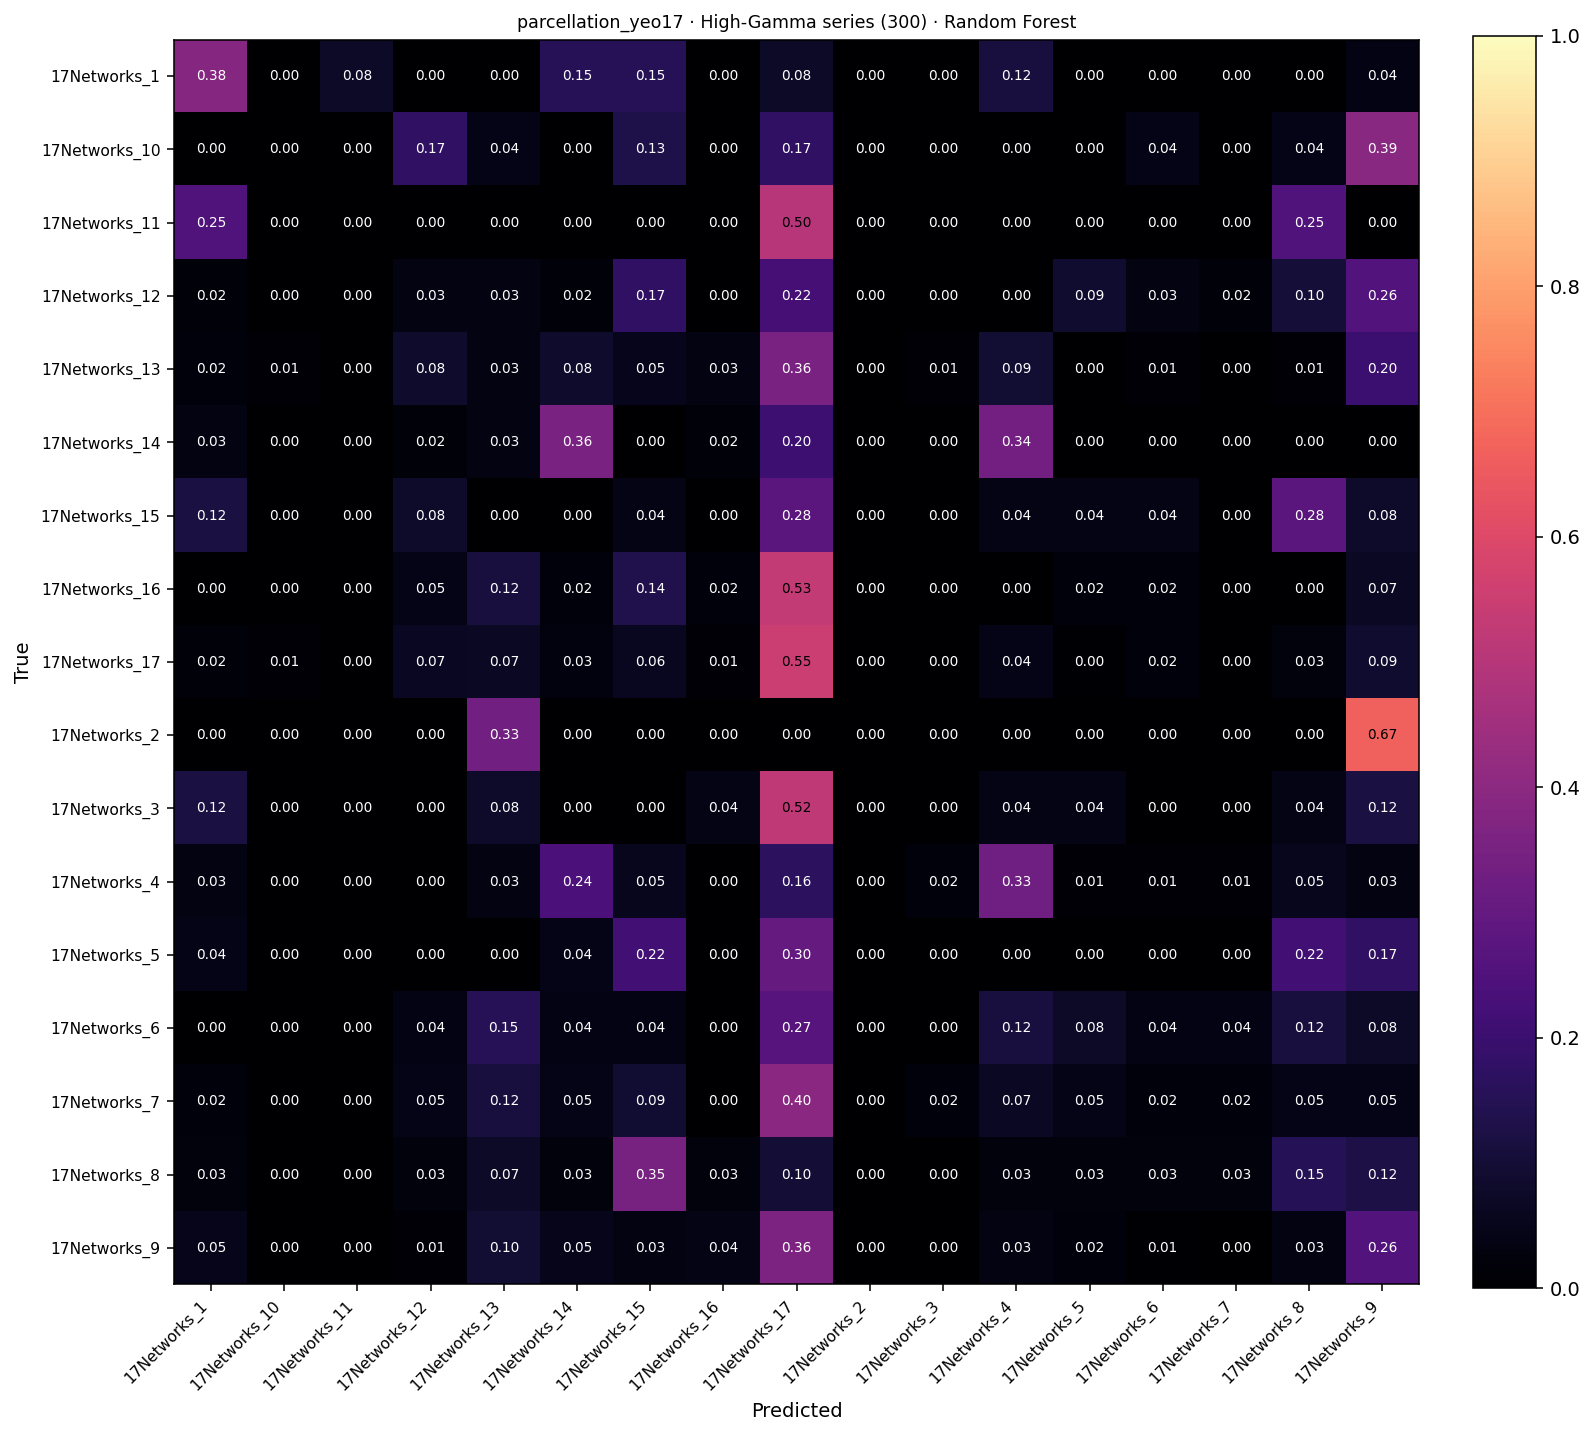

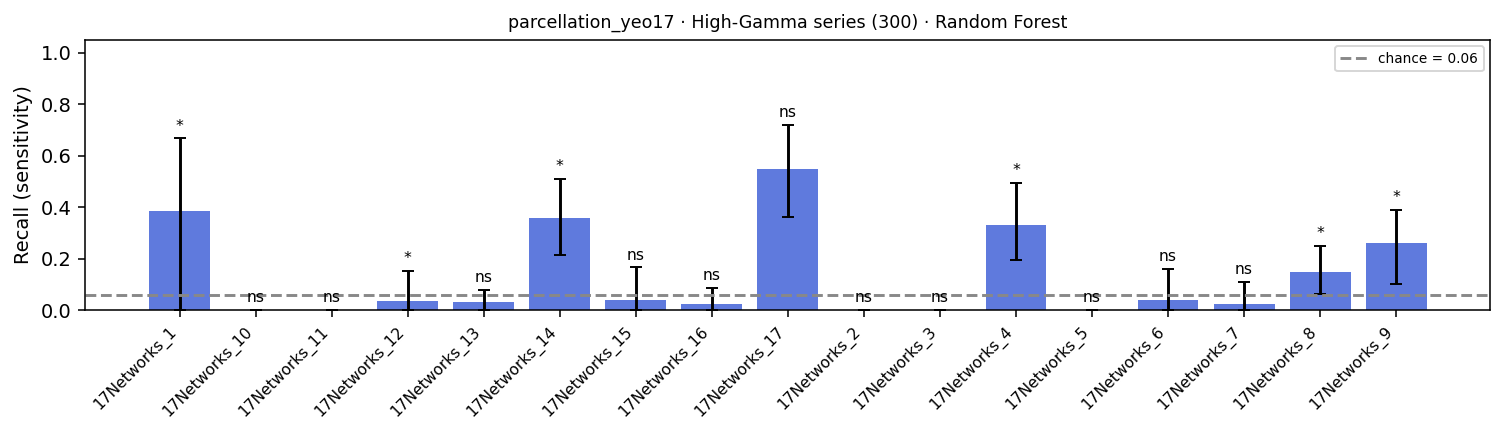

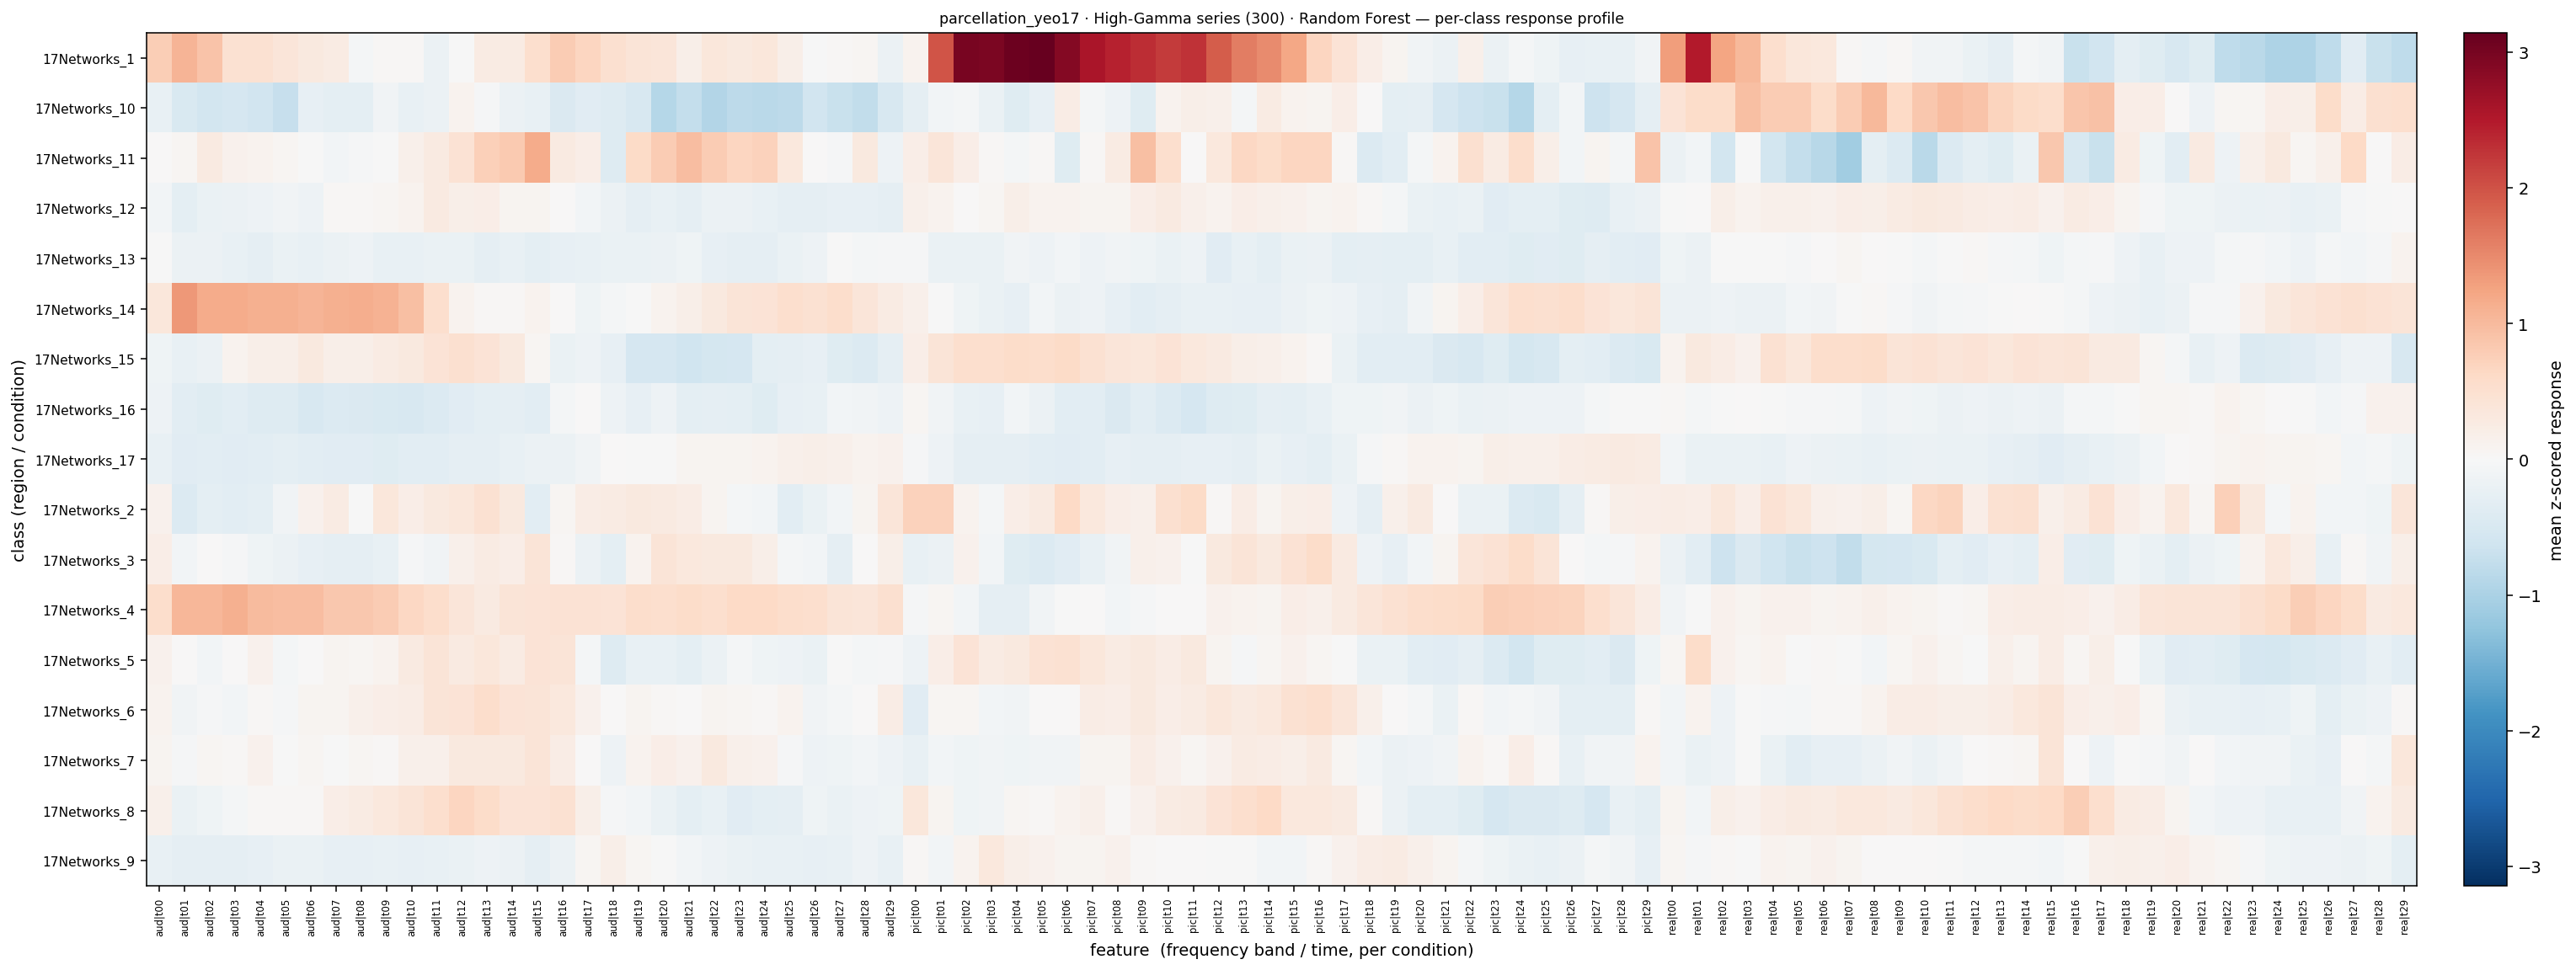

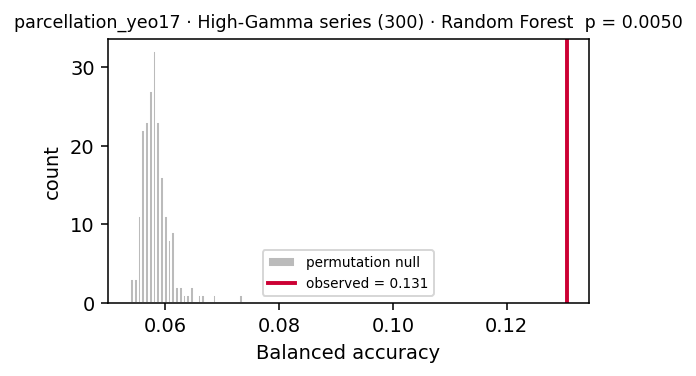

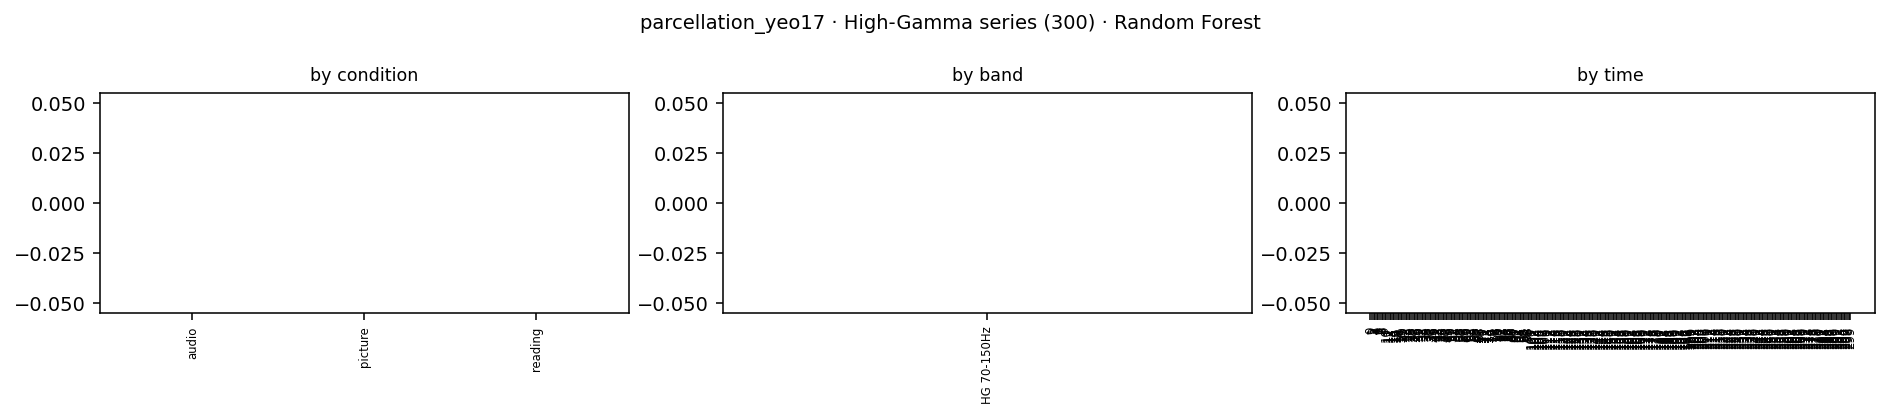

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,17Networks_1,26,0.385,0.000,0.667,0.256,0.308,0.909,0.017
1,17Networks_10,23,0.000,0.000,0.000,0.000,0.000,0.690,1.000
2,17Networks_11,4,0.000,0.000,0.000,0.000,0.000,0.362,1.000
3,17Networks_12,58,0.034,0.000,0.154,0.050,0.041,0.525,0.042
4,17Networks_13,95,0.032,0.000,0.078,0.049,0.038,0.535,0.076
5,17Networks_14,59,0.356,0.214,0.509,0.276,0.311,0.824,0.017
6,17Networks_15,25,0.040,0.000,0.167,0.013,0.020,0.601,0.075
7,17Networks_16,43,0.023,0.000,0.086,0.062,0.034,0.607,0.072
8,17Networks_17,228,0.548,0.362,0.719,0.370,0.442,0.674,1.000
9,17Networks_2,3,0.000,0.000,0.000,0.000,0.000,0.072,1.000


### parcellation_yeo17 · High-Gamma downsampled (30) · Logistic Regression (multinomial)
- balanced accuracy **0.122** (chance 0.059; 95% CI 0.095–0.145)
- macro-F1 0.118 · accuracy 0.184 · **permutation p = 0.0050** · n=958 over 24 patients

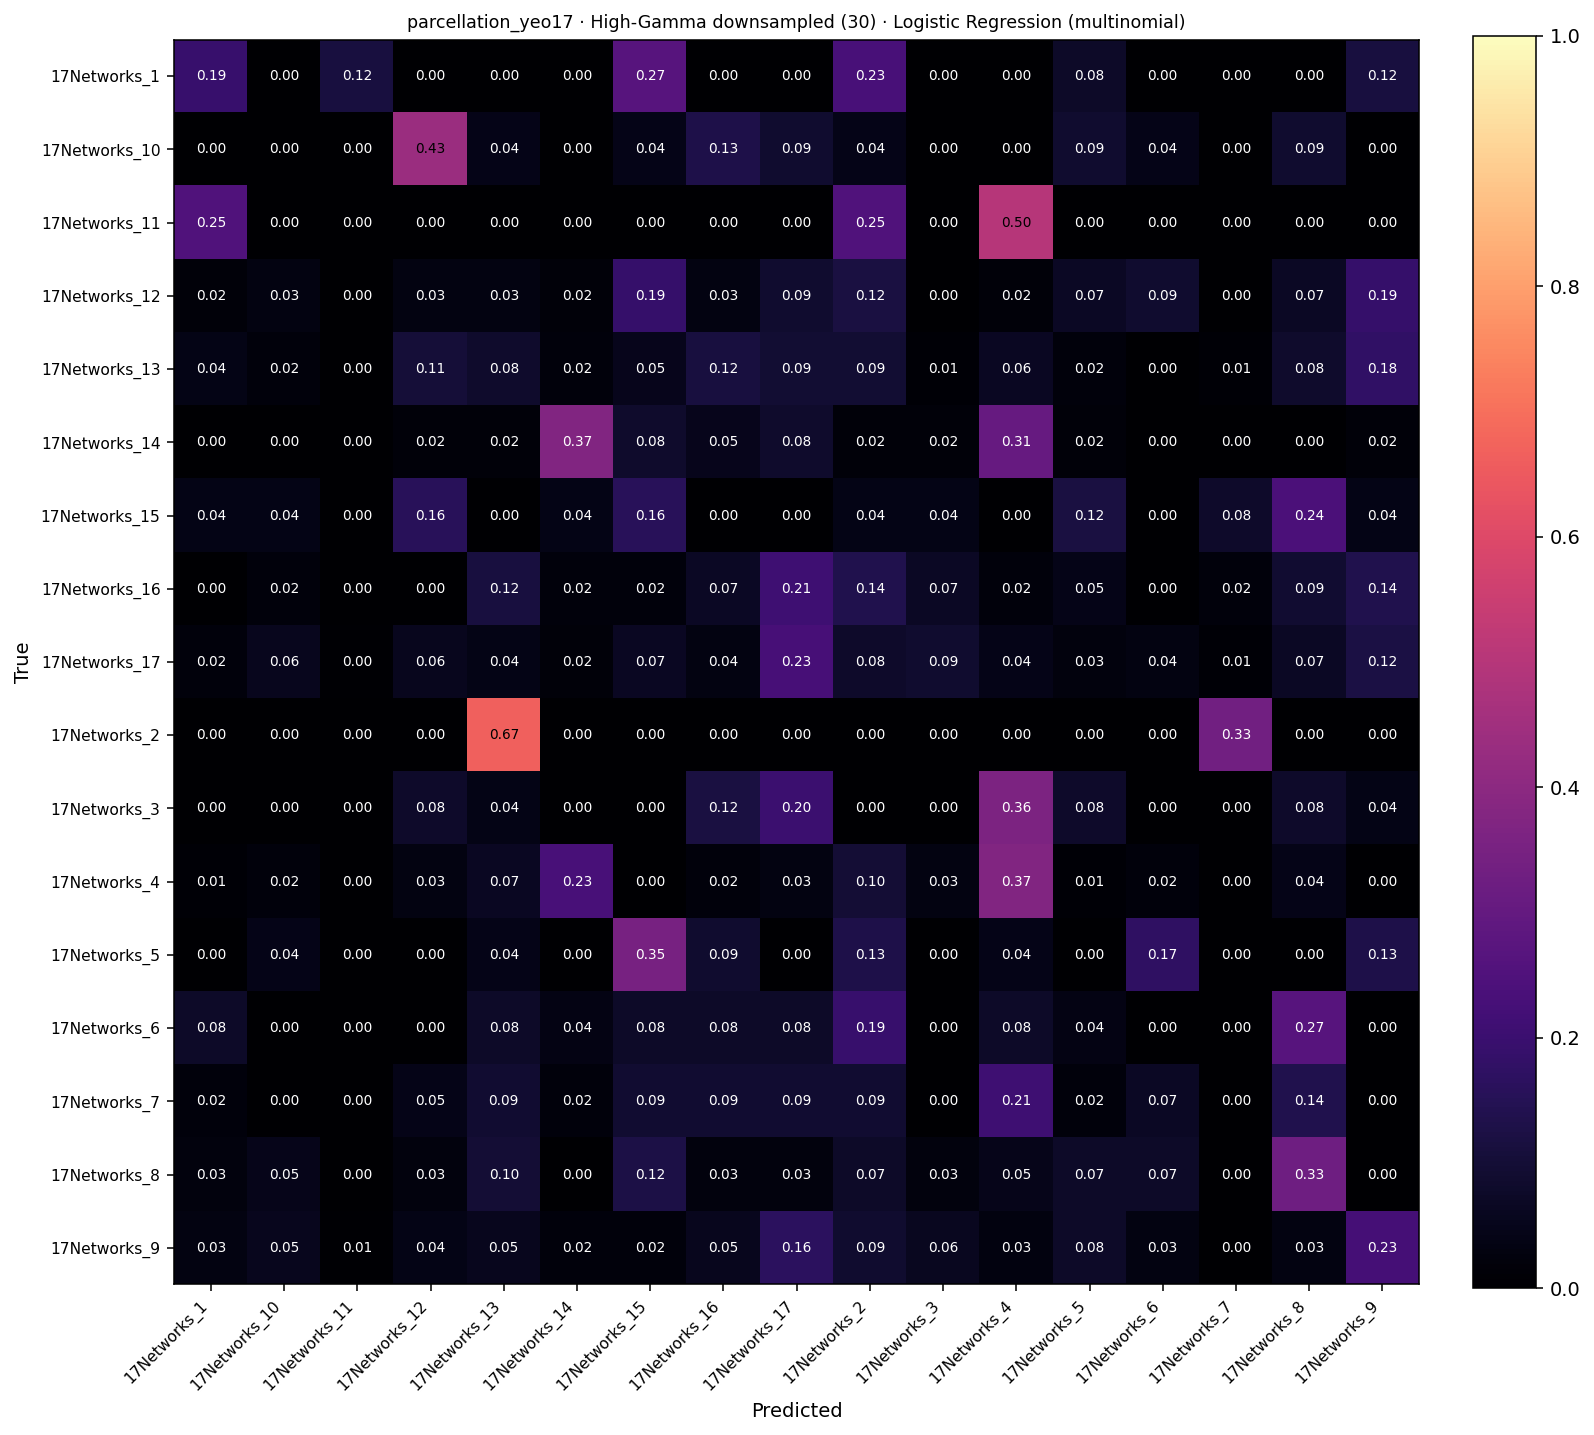

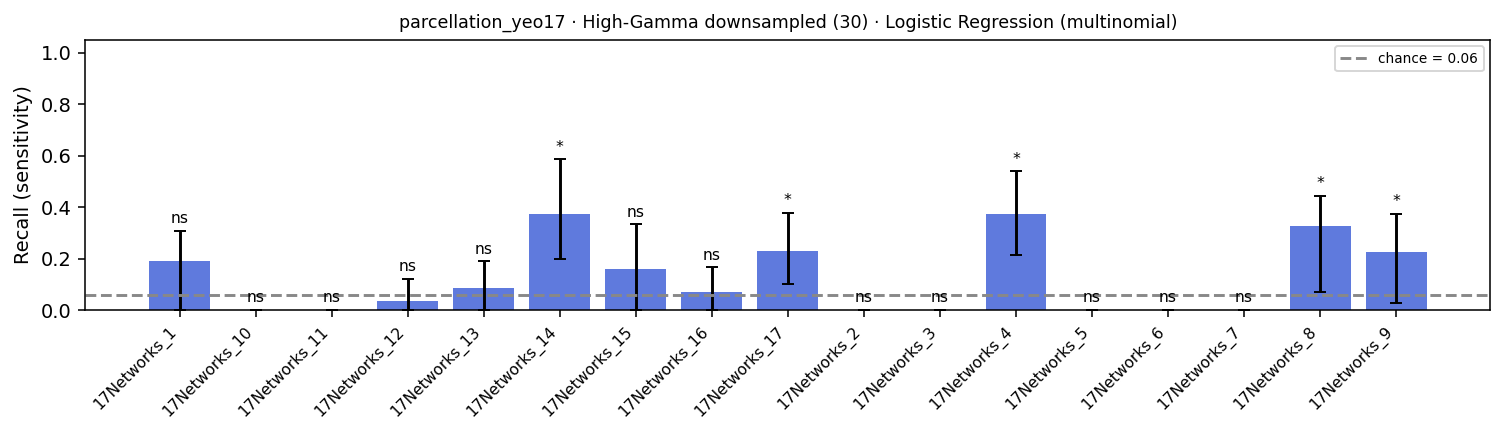

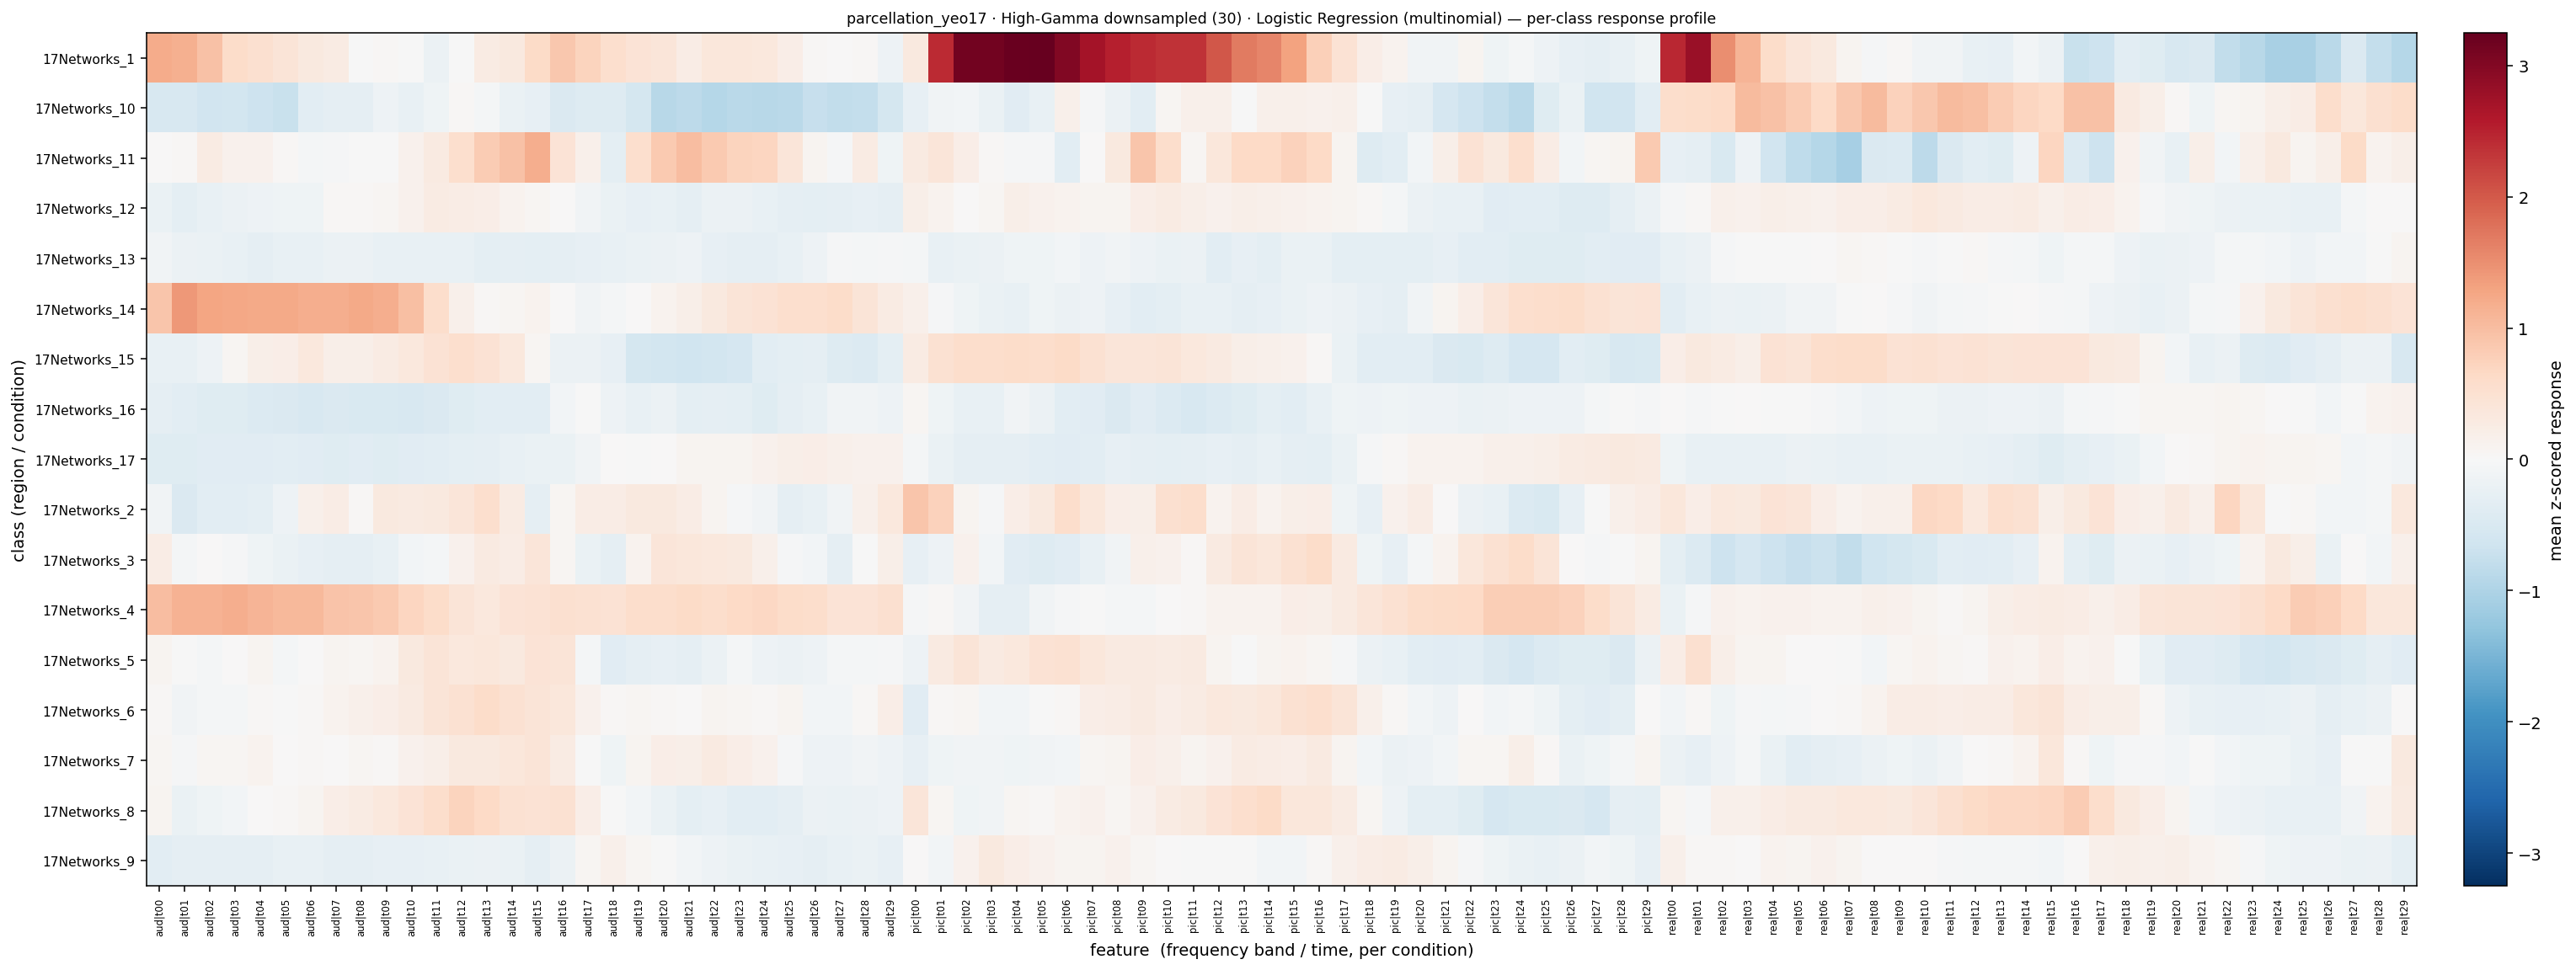

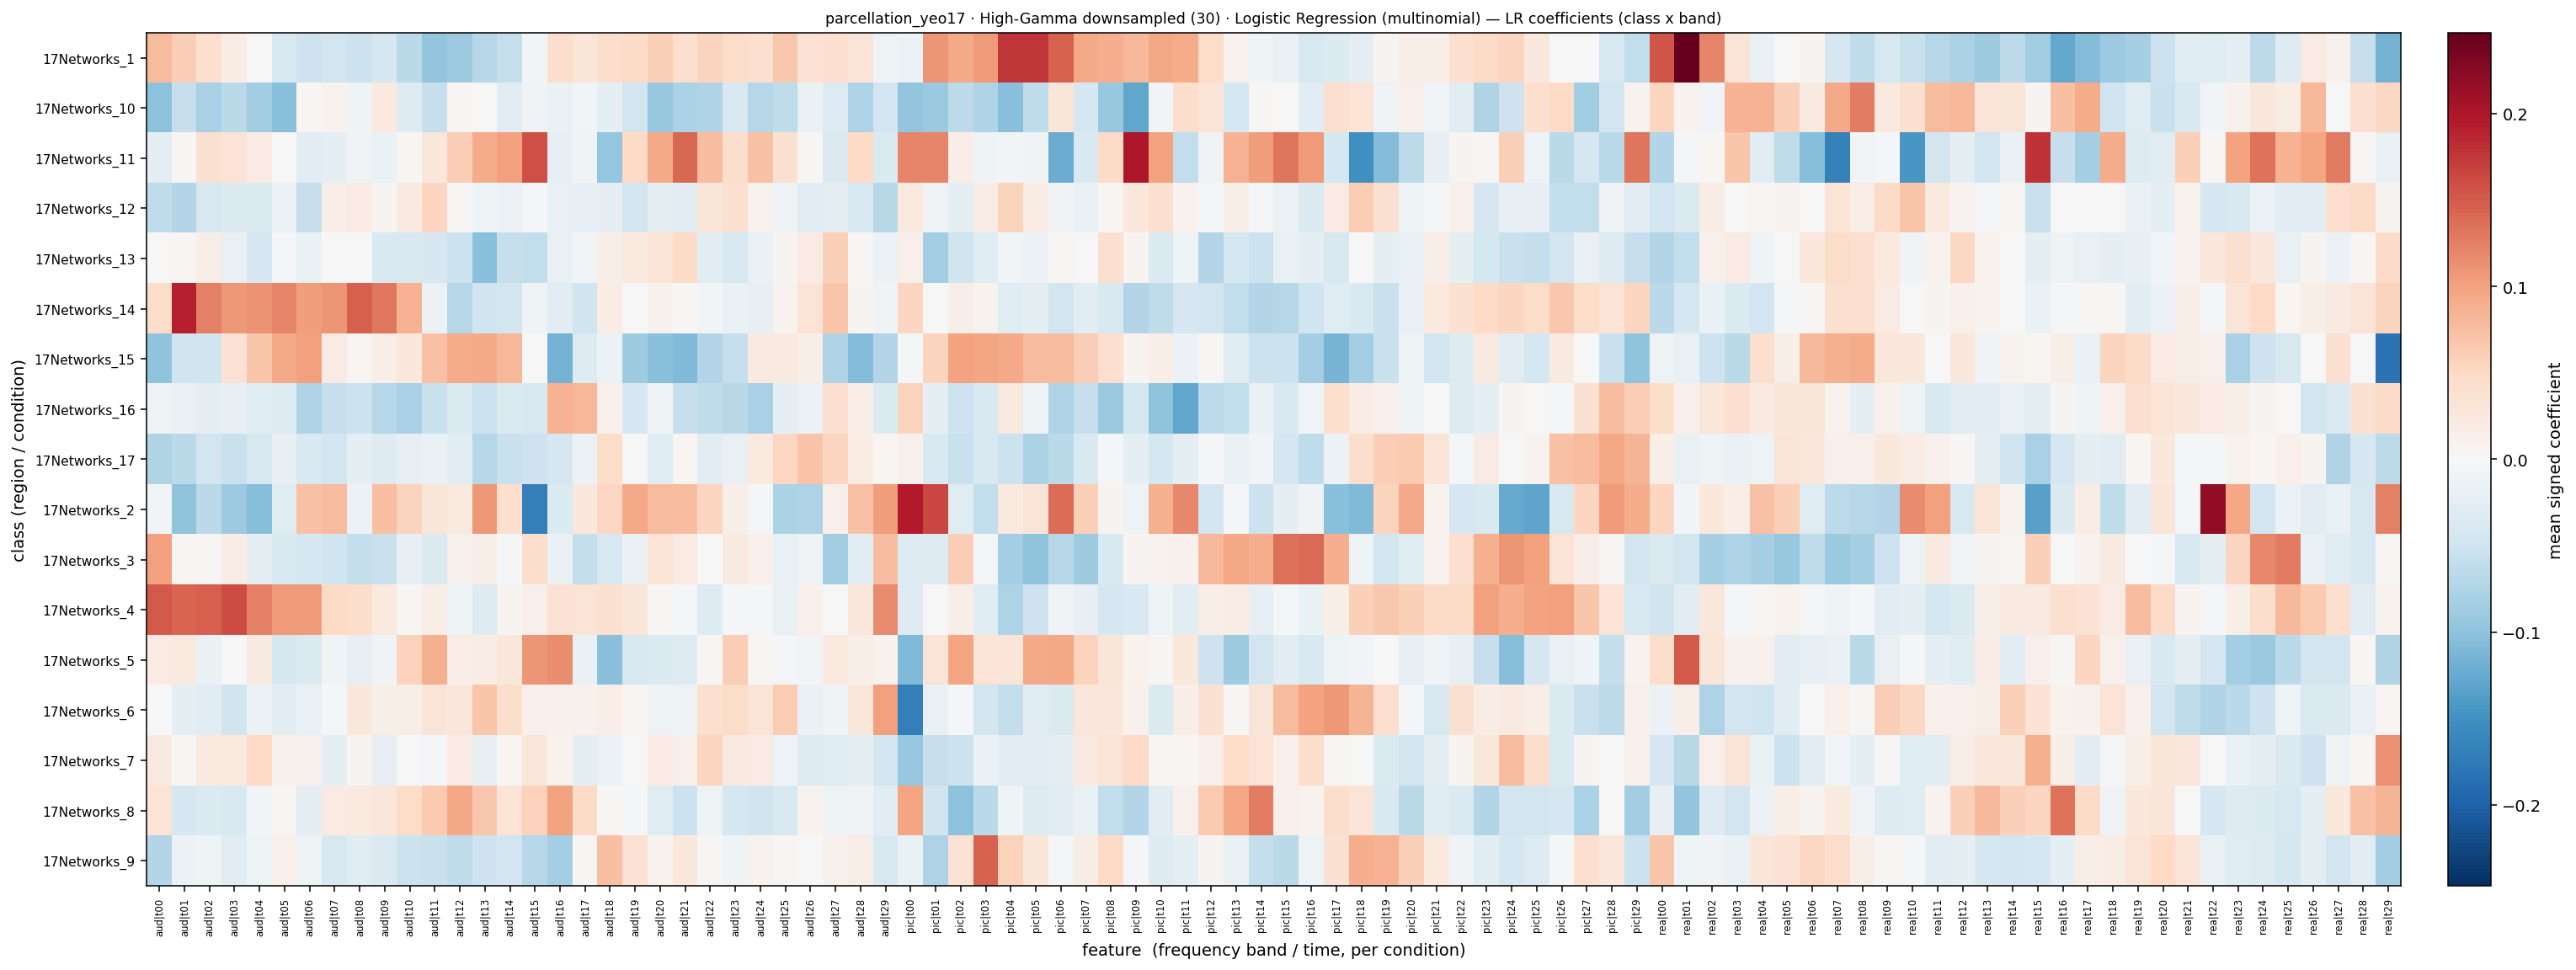

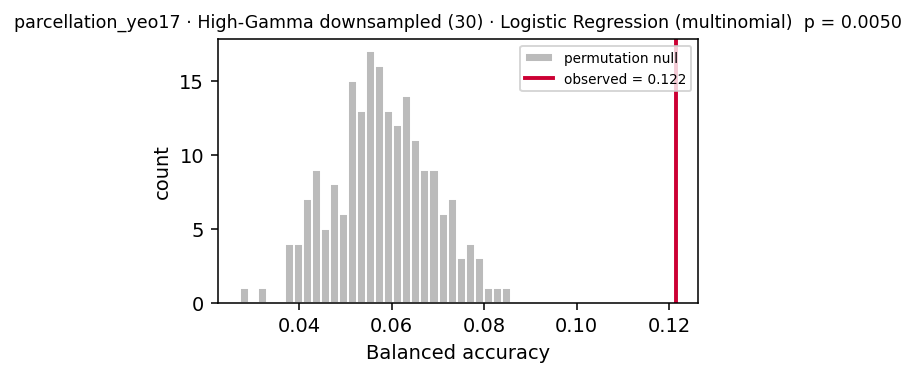

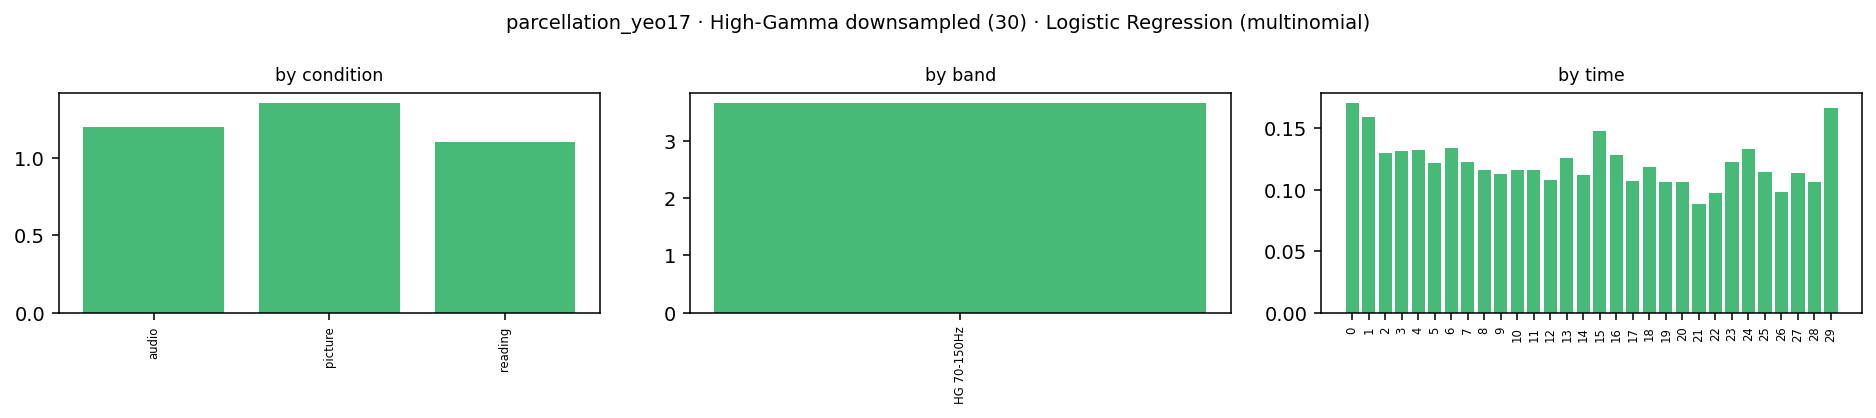

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,17Networks_1,26,0.192,0.000,0.308,0.185,0.189,0.910,0.099
1,17Networks_10,23,0.000,0.000,0.000,0.000,0.000,0.511,1.000
2,17Networks_11,4,0.000,0.000,0.000,0.000,0.000,0.495,1.000
3,17Networks_12,58,0.034,0.000,0.121,0.037,0.036,0.440,1.000
4,17Networks_13,95,0.084,0.000,0.189,0.148,0.107,0.541,0.476
5,17Networks_14,59,0.373,0.200,0.586,0.386,0.379,0.853,0.017
6,17Networks_15,25,0.160,0.000,0.333,0.056,0.083,0.678,0.338
7,17Networks_16,43,0.070,0.000,0.167,0.058,0.063,0.636,1.000
8,17Networks_17,228,0.228,0.103,0.378,0.430,0.298,0.655,0.017
9,17Networks_2,3,0.000,0.000,0.000,0.000,0.000,0.185,1.000


### parcellation_yeo17 · High-Gamma downsampled (30) · Random Forest
- balanced accuracy **0.140** (chance 0.059; 95% CI 0.115–0.176)
- macro-F1 0.131 · accuracy 0.251 · **permutation p = 0.0050** · n=958 over 24 patients

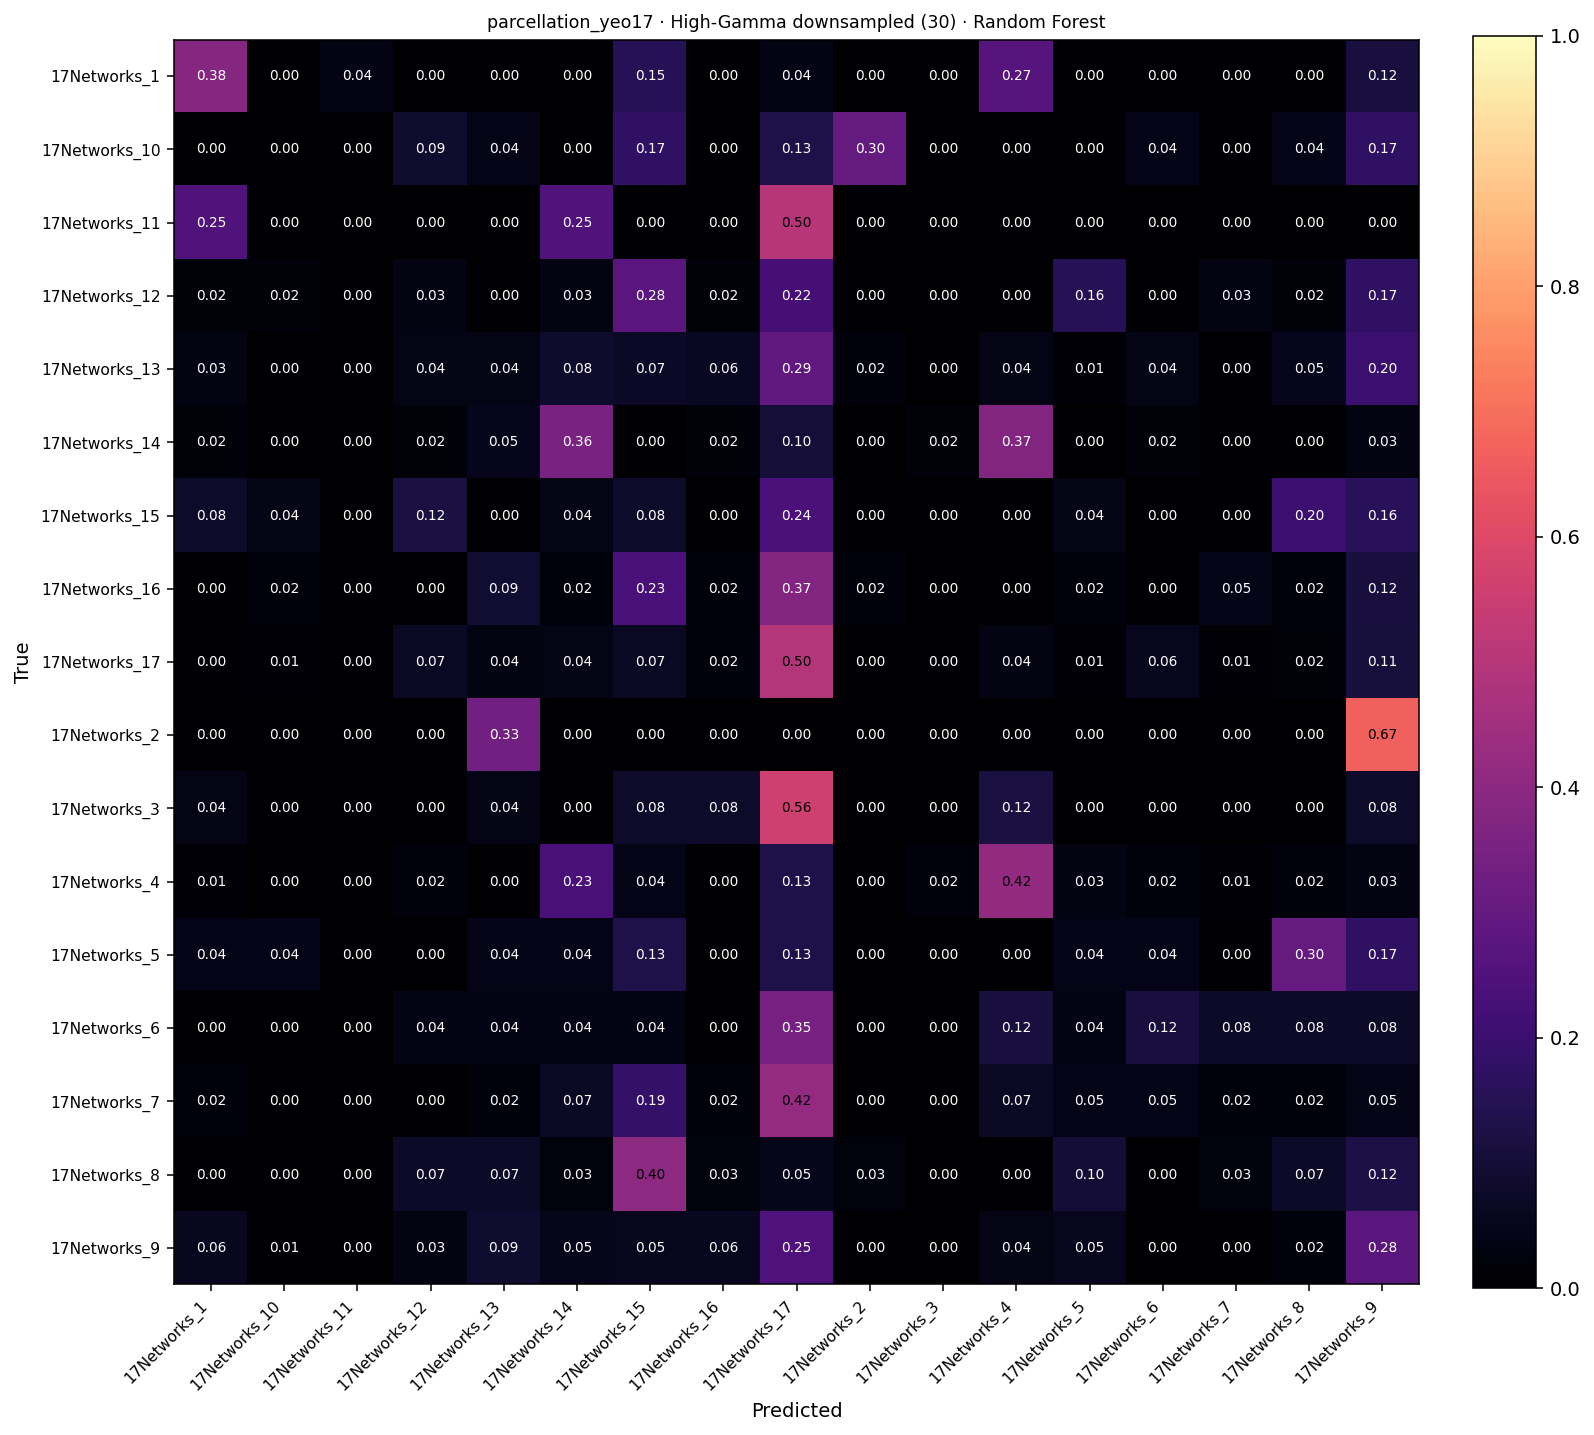

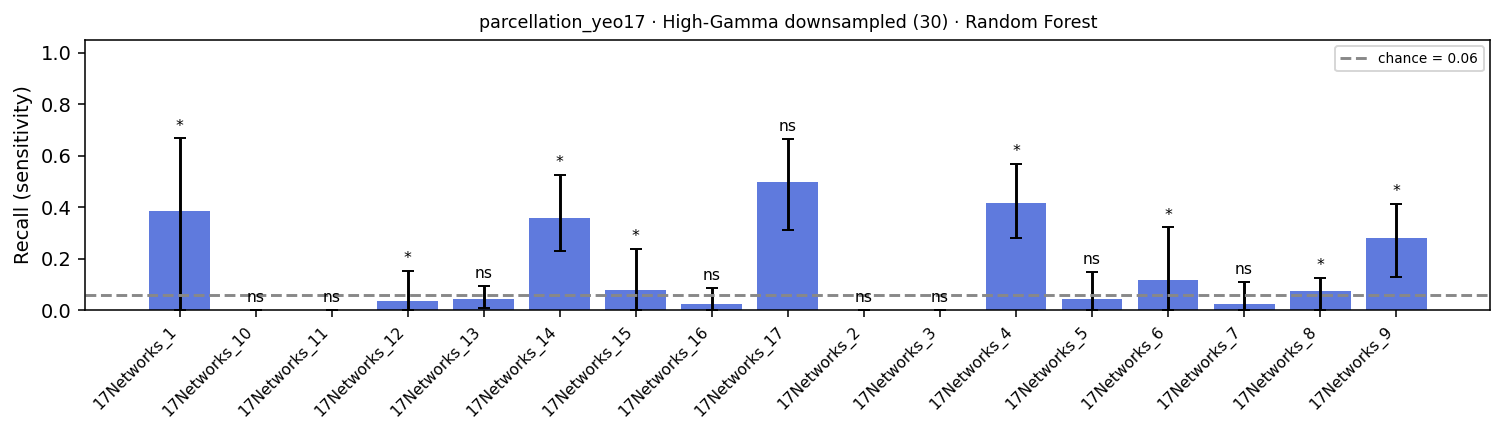

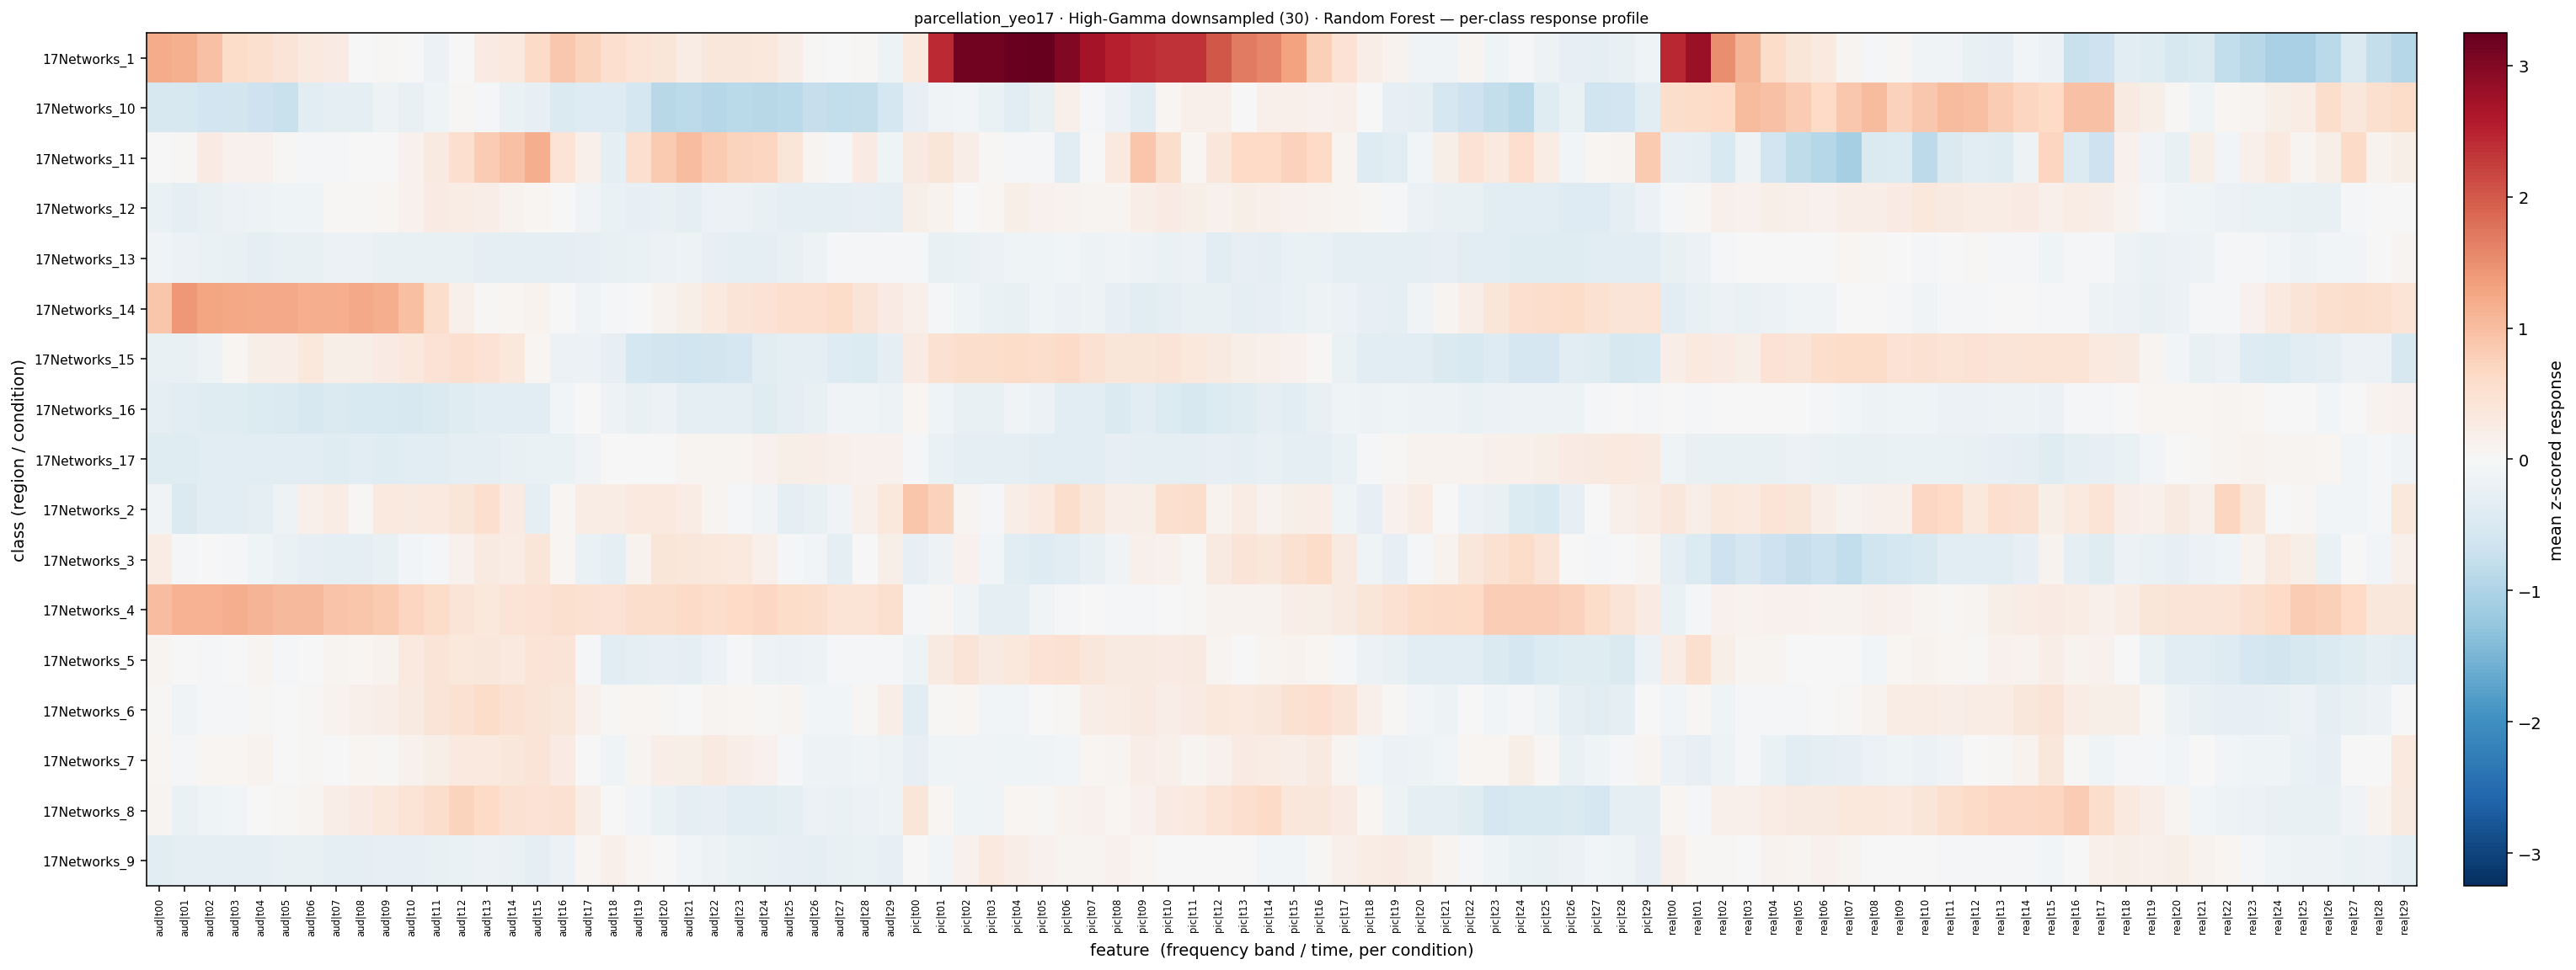

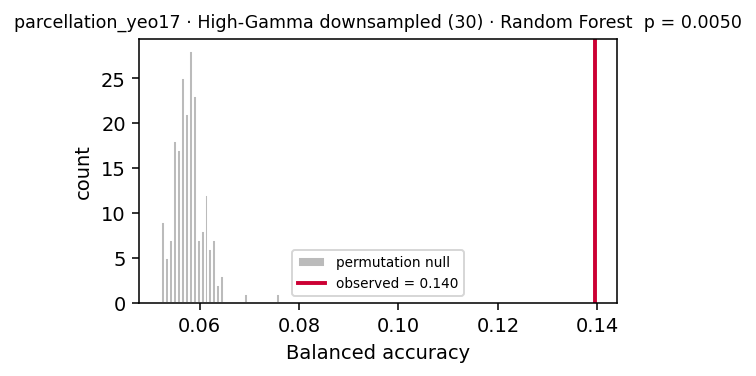

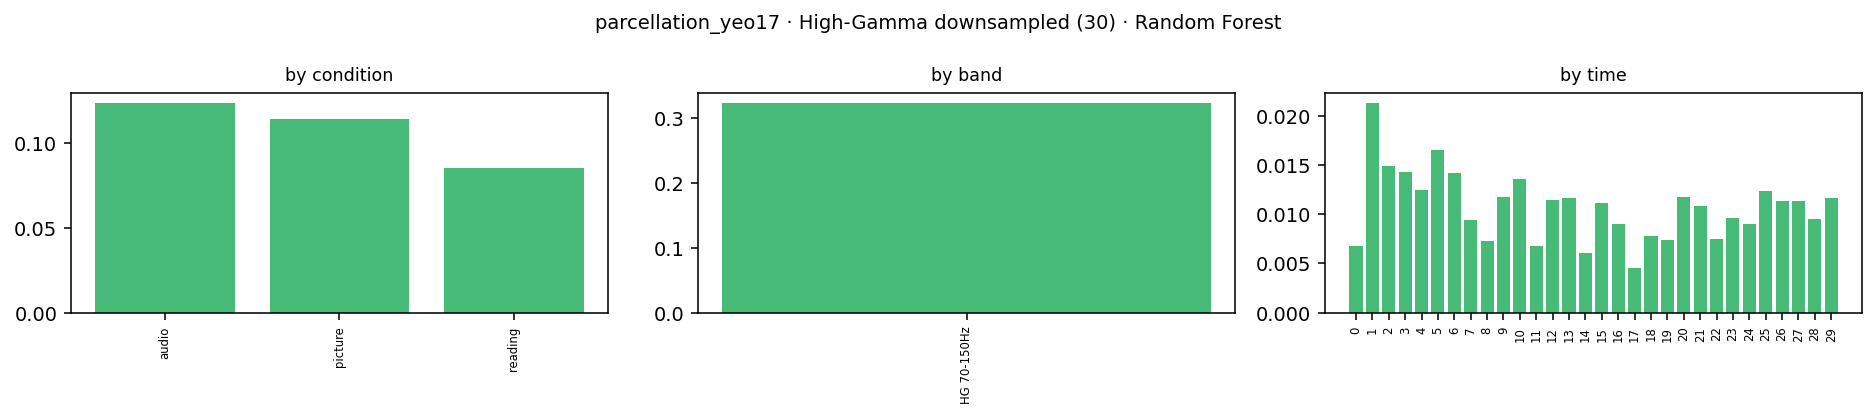

,class,support,recall,recall_ci_lo,recall_ci_hi,precision,f1,roc_auc_ovr,perm_p_fdr
0,17Networks_1,26,0.385,0.000,0.667,0.312,0.345,0.904,0.012
1,17Networks_10,23,0.000,0.000,0.000,0.000,0.000,0.641,1.000
2,17Networks_11,4,0.000,0.000,0.000,0.000,0.000,0.154,1.000
3,17Networks_12,58,0.034,0.000,0.154,0.051,0.041,0.518,0.032
4,17Networks_13,95,0.042,0.008,0.094,0.098,0.059,0.609,0.106
5,17Networks_14,59,0.356,0.228,0.525,0.273,0.309,0.844,0.012
6,17Networks_15,25,0.080,0.000,0.238,0.020,0.032,0.598,0.012
7,17Networks_16,43,0.023,0.000,0.086,0.037,0.029,0.619,0.101
8,17Networks_17,228,0.496,0.311,0.664,0.401,0.443,0.698,1.000
9,17Networks_2,3,0.000,0.000,0.000,0.000,0.000,0.109,1.000


In [9]:
for n_net in (7, 17):
    show(f'## Yeo-{n_net}')
    for v in C.VARIANTS:
        for clf in ('logreg', 'rf'):
            show_run(f'parcellation_yeo{n_net}', v, clf)


# Takeaways & caveats

- **Above-chance ≠ strong.** A run can clear the permutation null yet still confuse most
  classes — always cross-check balanced accuracy, the confusion matrix, and the per-class
  stars together.
- **Per-class is where the story is.** The summary number averages over classes; the
  per-class strength panel shows *which* conditions/networks are actually recoverable and
  which collapse into their neighbours.
- **Patient-grouped CV is conservative.** Numbers are lower than a naive random split would
  give, but they are the honest estimate of decoding in an unseen patient.
- **Feature importance is associational**, not causal — it tells you which bands/time/condition
  the model leaned on, given everything else it had.

_To refresh this page: re-run 320 / 330 (writes new runs), then re-run this notebook — it
always loads the latest run per (task · variant · classifier)._
